# Combined DL and TROPoe Eclipse Analysis

## Introduction

Based on previous scripts, this notebook explores eclipse behavior at a variety of sites, using both Doppler lidar and TROPoe output from AERI and ASSIST instruments. A key component of this analysis is the use of calculated PBL heights from Julia Simonson's code, based on the TROPoe PBLH code. This way, we can normalize behavior based on PBLH. 

This code is going to go through several steps:
1. Read in the TROPoe and DLID data for a particular case into a data class.  
2. Apply Julia's code to calculte PBLH from TROPoe
3. Evalute the characteristic performance of PBL vertical velocity and temperature as a function of height.
4. Do the same, but for normailzed heights relative to PBLH.
5. Write a paper, win Nobel prize.

## Preliminary Matters

Load the appropriate modules.

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import glob
import netCDF4
from scipy import interpolate as interp
from matplotlib import colors

import warnings
warnings.filterwarnings("ignore")

Identify appropriate paths and initilize constants.

In [2]:
tropOEpath = '/Users/timw/data/eclipse/tropoe'
lidarPath = '/Users/timw/data/eclipse/dlfpt'

timeNew = np.linspace(-4,4,3600*8+1)
heightNew = np.arange(15,2025,30)


Record the characteristics of the eclipses: dates, times, obscurities, that kind of thing. Sincve we now know how many sites and datews we have, we can also initiliaze our blank matrices.

In [3]:
sgpEclipseDates = np.array([20120521, 20170821, 20231014, 20240408])
sgpEclipseTimes = np.array([1+31/60,18+4/60, 16+48/60, 18+47/60])
sgpEclipseMags = np.array([0.859, 0.903, 0.796, 0.914])
sgpTimeZone= np.array([-5,-5,-5,-5])
sgpEclipseSites = np.array(['C1','E32','E37','E39','E41'])
sgpEclipseFacilities= np.array(['sgp','sgp','sgp','sgp','sgp'])

nsaEclipseDates = np.array([20120520, 20141023, 20170821, 20210610])
nsaEclipseTimes = np.array([11+13/60, 19+55/60, 17+29/60, 10+57/60])
nsaEclipseMags = np.array([0.482, 0.695, 0.335,0.849])
nsaTimeZone = np.array([-9,-9,-9,-9])
nsaEclipseSites= np.array(['C1'])
nsaEclipseFacilities = np.array(['nsa'])

enaEclipseDates = np.array([20150320,20170821,20210610,20231014,20250329])
enaEclipseTimes = np.array([8+51/60,19+26/60, 9+20/60, 18+42/60, 10+16/60]) 
enaEclipseMags = np.array([0.801, 0.386, 0.384, 0.026, 0.618])
enaTimeZone = np.array([-1,0,0,0,-1])
enaEclipseSites= np.array(['C1'])
enaEclipseFacilities = np.array(['ena'])


wPrime = np.zeros((len(timeNew), len(heightNew)))
wVar = np.zeros((len(timeNew), len(heightNew), len(sgpEclipseSites)*len(sgpEclipseDates)))
saveDate = np.zeros(len(timeNew) * len(heightNew))



Define functions

In [4]:
def readDL(f):

    ds = netCDF4.Dataset(f)
    
    class out:
        
        unixTime = ds['base_time'][:] + ds['time_offset'][:]
        time = ds['time'][:]/3600 # Hours UTC 
        height = ds['range'][:]
        w = ds['radial_velocity'][:]
        qc_w = ds['qc_radial_velocity'][:]
        intensity = ds['intensity'][:]
        back = ds['attenuated_backscatter'][:]
        
        
    out.w[np.where(out.qc_w != 0)] = np.nan
    
    return out

def readTROPoe(f):

    ds = netCDF4.Dataset(f)
    
    class out:
        
        unixTime = ds['base_time'][:] + ds['time_offset'][:]
        time = ds['hour'][:] # Hours UTC 
        height = ds['height'][:]*1000
        temp = ds['temperature'][:]
        wv = ds['waterVapor'][:]
        theta = ds['theta'][:]
        sigma_t = ds['sigma_temperature'][:]
    
    return out


def findNearest(array,value):
    idx = (np.abs(array-value)).argmin()
    
    return idx

def collectDL(eFacility, eSite, eDate):

    iter = 0    
    
    for file in sorted(glob.iglob(lidarPath + '/' + eFacility+ '*' + eSite + '*' + str(eDate) + '*.cdf')):

        dli = readDL(file)
        if iter ==0:

            class dl:

                unixTime = np.array(dli.unixTime)
                time =  np.array(dli.time)
                height =  np.array(dli.height)
                w =  np.array(dli.w)
                intensity = np.array(dli.intensity)
                back = np.array(dli.back)


        else:

            dl.unixTime = np.concatenate((dl.unixTime, dli.unixTime))
            dl.time = np.concatenate((dl.time, dli.time))
            dl.w = np.concatenate((dl.w, dli.w))
            dl.intensity = np.concatenate((dl.intensity, dli.intensity))
            dl.back = np.concatenate((dl.back, dli.back))

        iter = iter+1
        
  
    return dl


def collectTROPoe(eFacility, eSite, eDate):

    for file in sorted(glob.iglob(tropOEpath + '/' + eFacility + '*' + eSite + '*' + str(eDate) + '*.nc')):

        aeri=readTROPoe(file)

    return aeri


def pblh_cbl(time,height,theta_prof,sigma):
  
  nudge = 0.5
  minht = 0.01	# minimum PBLH in km
  maxht = 6.0	# maximum PLBH in km
  
  theta = theta_prof + sigma   
  pblh = np.empty(len(time),dtype=float) 

  for t in range(0,len(time)):
    
    th0 = theta[t,0] + nudge
    val = np.where((th0 < theta[t,:]) & (height >= minht))[0][0]
    
    if val < 0:				# no times match criteria, set to min height
      pblh[t] = minht
    elif val == 0:
      pblh[t] = height[0]
    else:
      tmpz = height[(val-1):(val+1)]
      tmpt = theta[t,(val-1):(val+1)]
            
      if np.abs(tmpt[0]-tmpt[1]) < 0.001:pblh[t] = height[val]
      else:pblh[t] = np.interp(th0,tmpt,tmpz)
          
    if height[val] < minht:pblh[t] = minht
    if height[val] > maxht:pblh[t] = maxht
  
  return pblh




## Doppler Lidar Analysis

Here is where we loop over the various eclipses, interpolate them to common grids (both regular height and PBL-centric), and compare one eclipse to the next.

### Original height grid

We'll start with doing the doppler lidar vertical velocity vartiance analysis on the original z grid. 

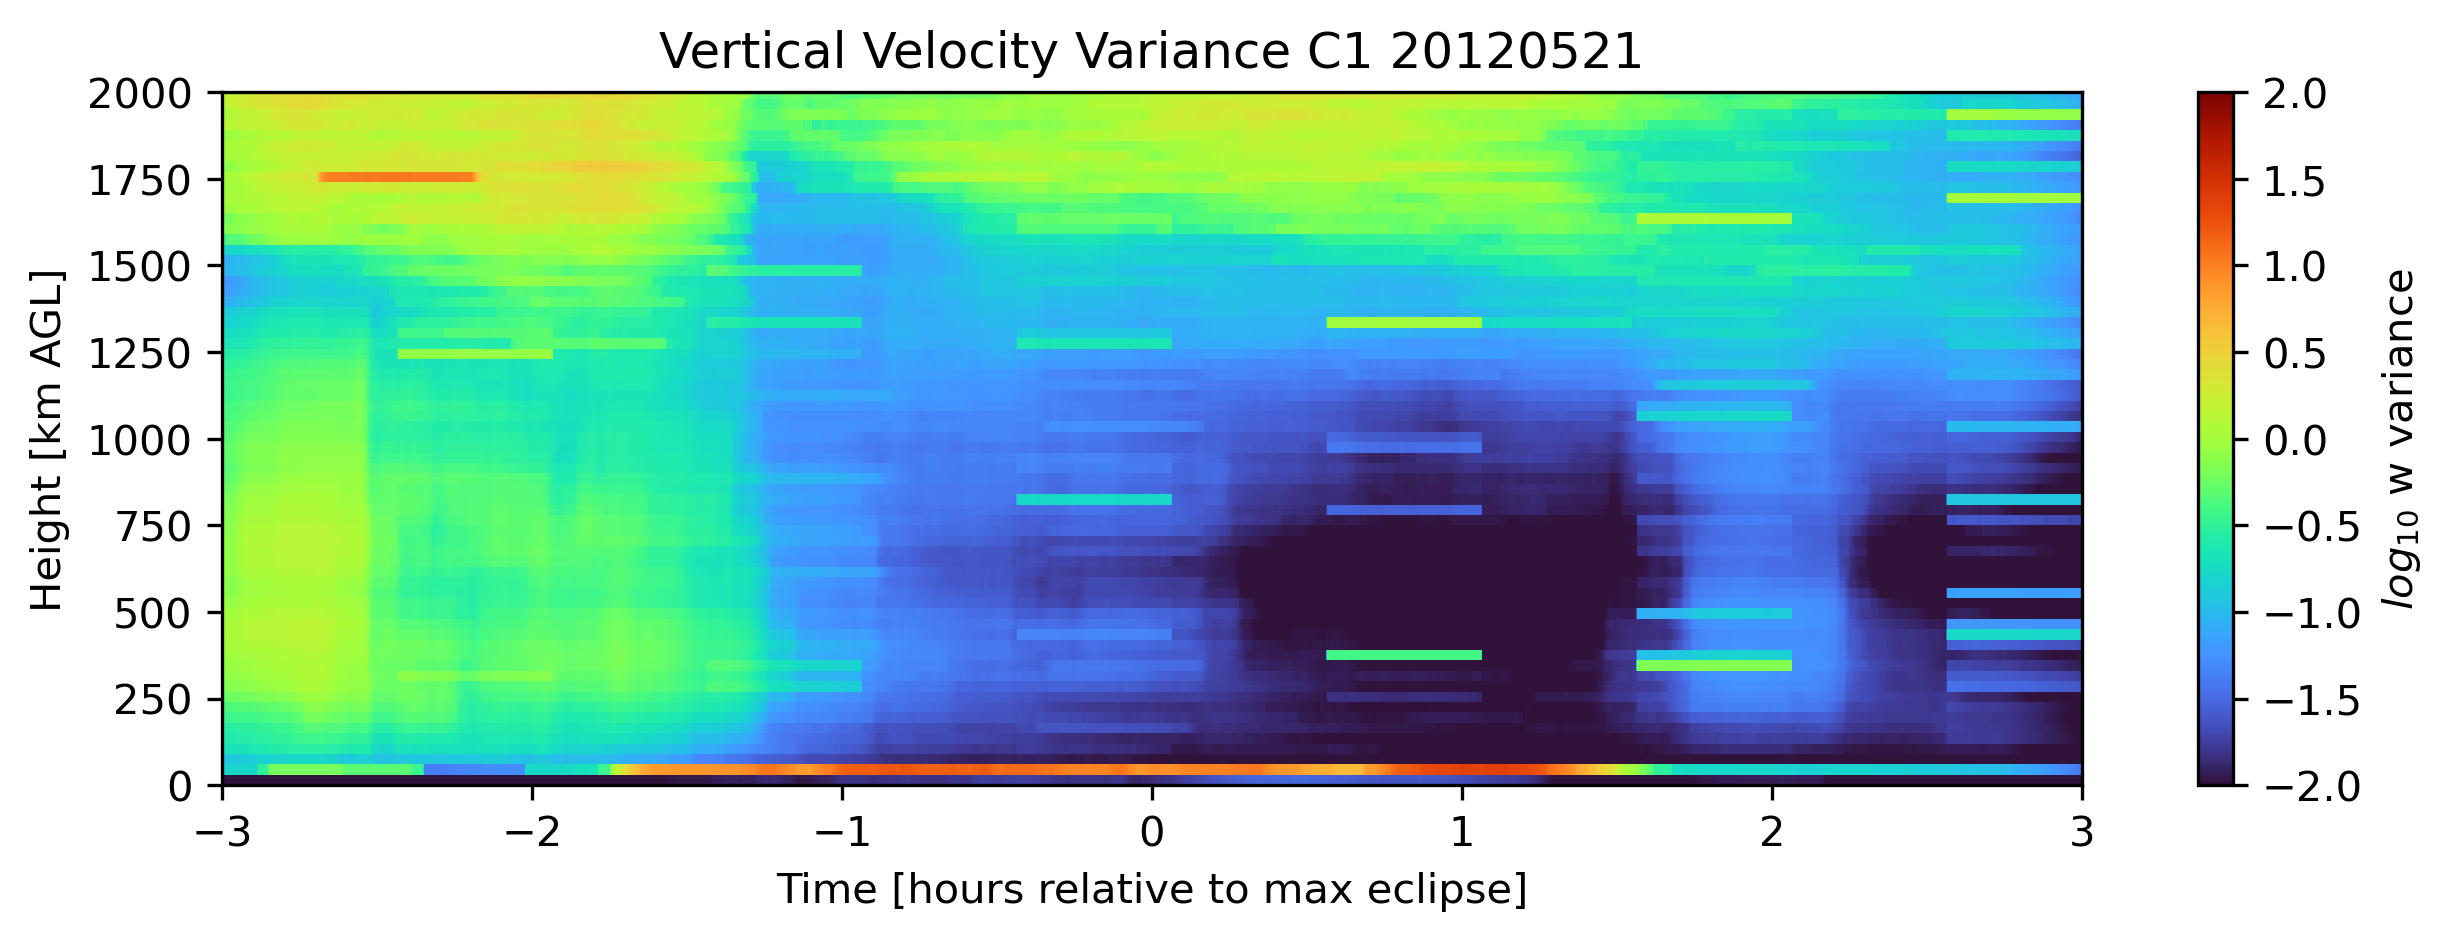

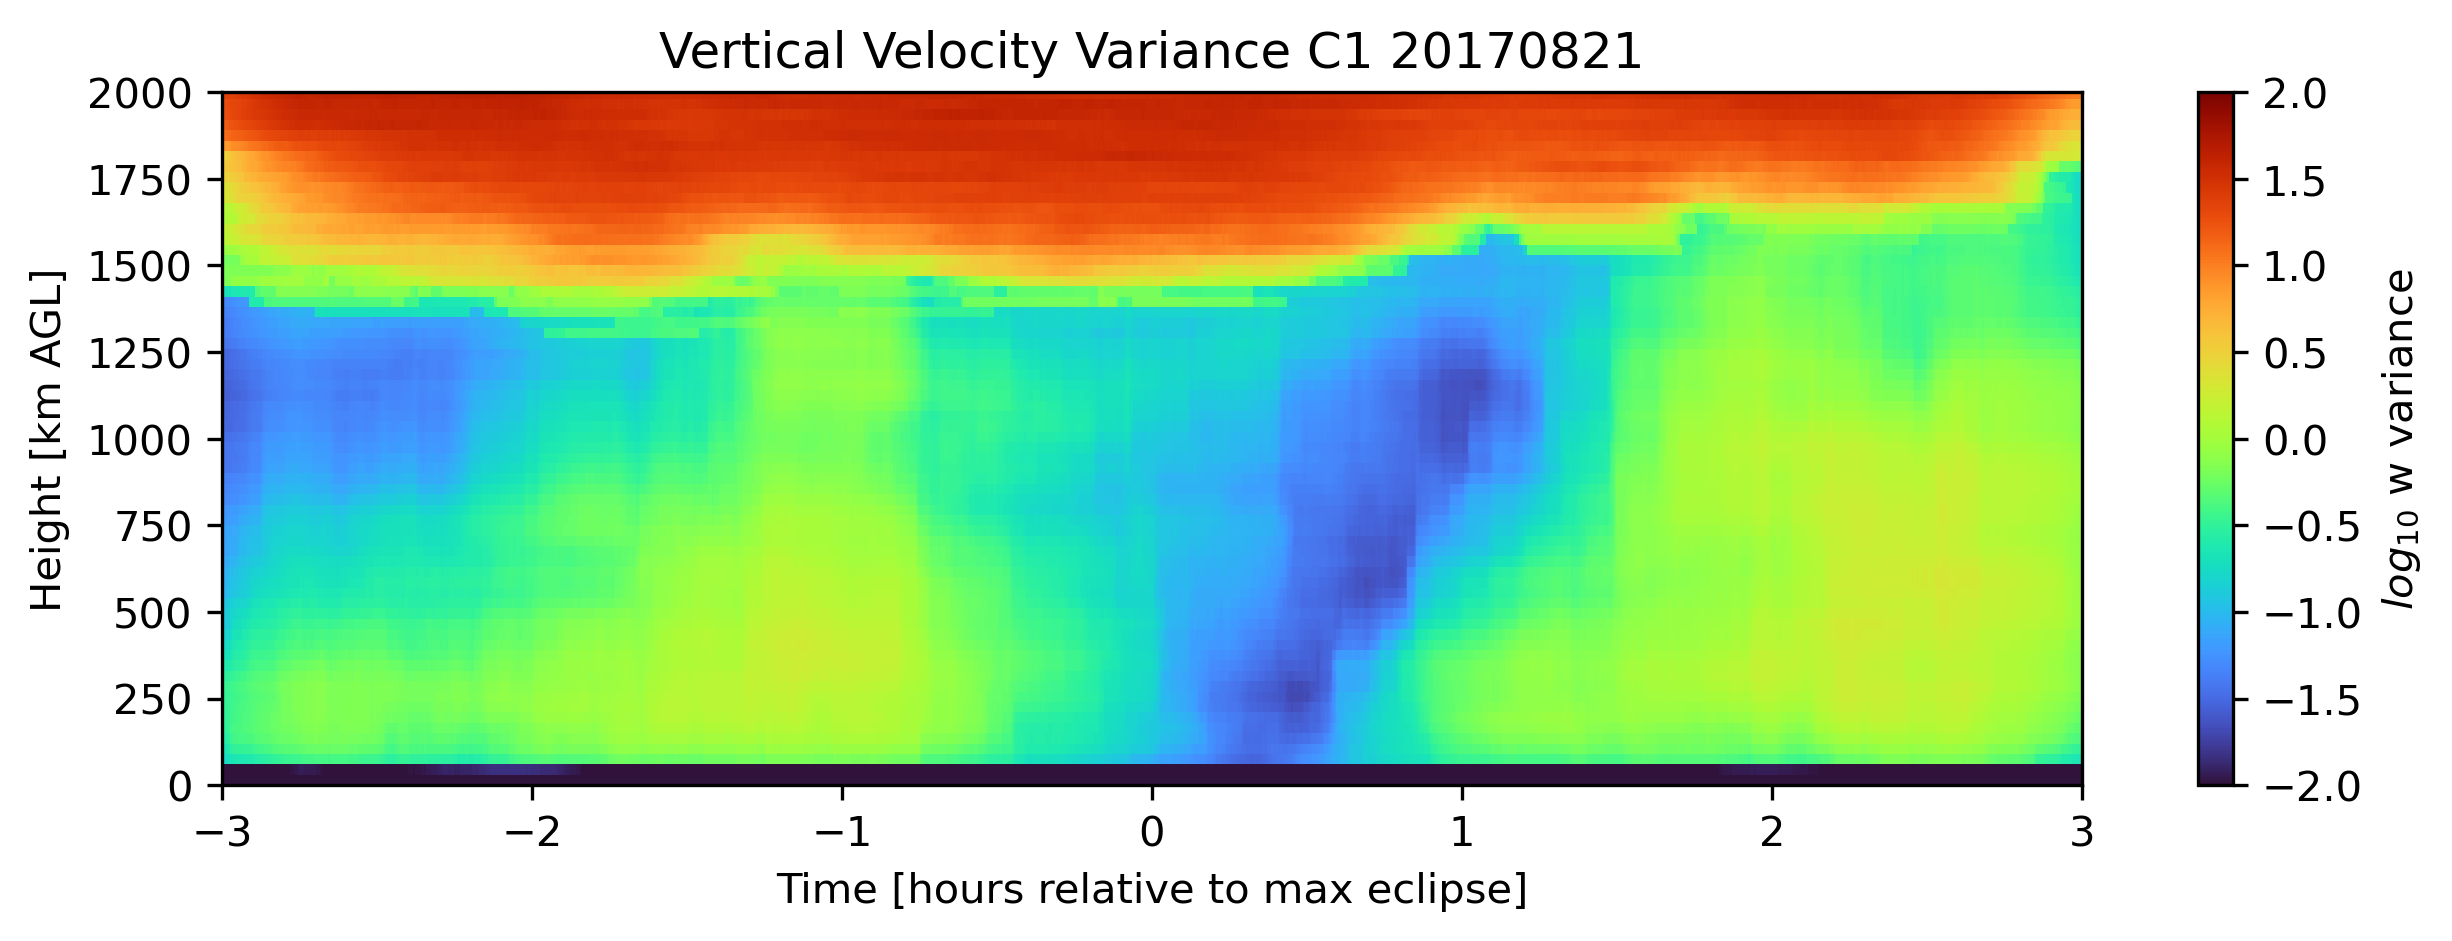

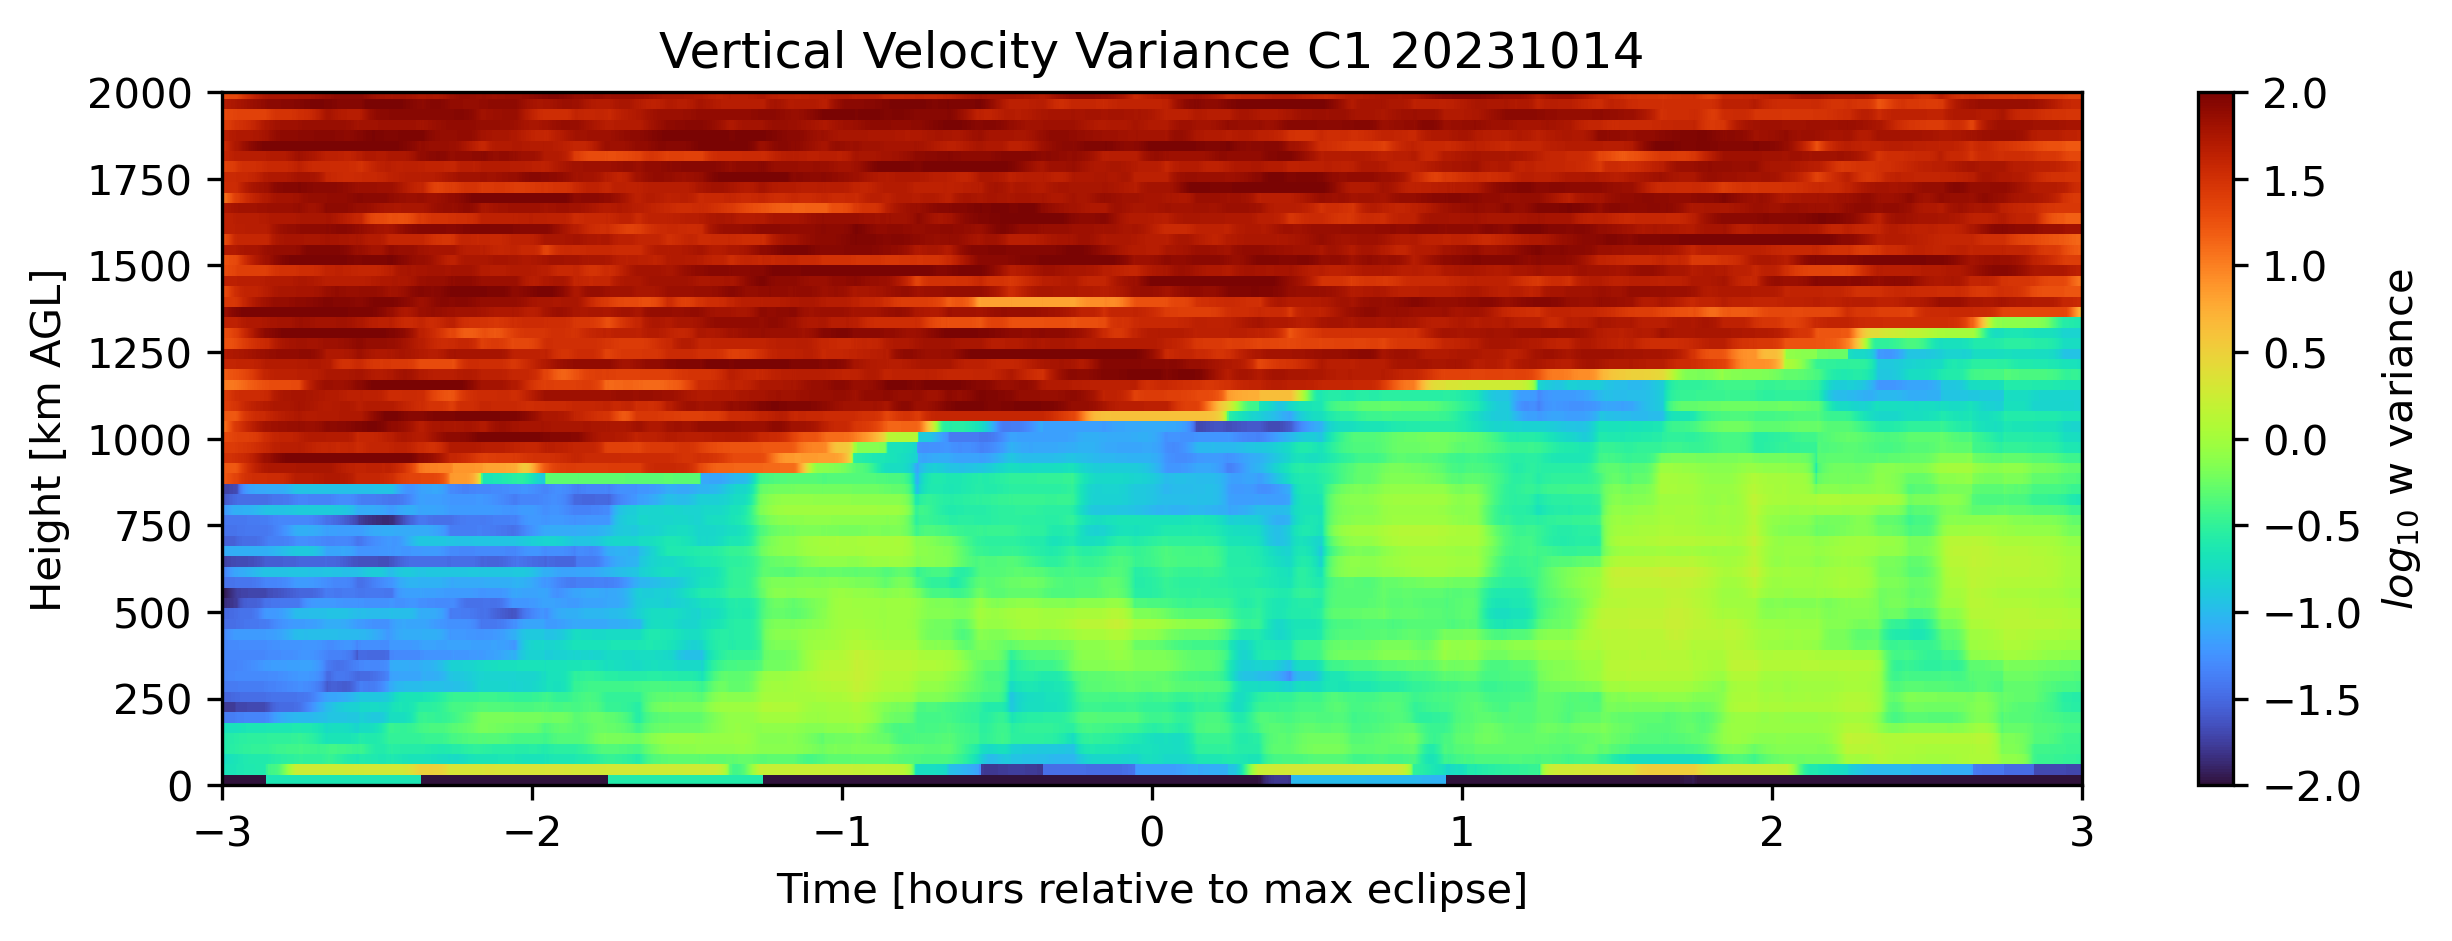

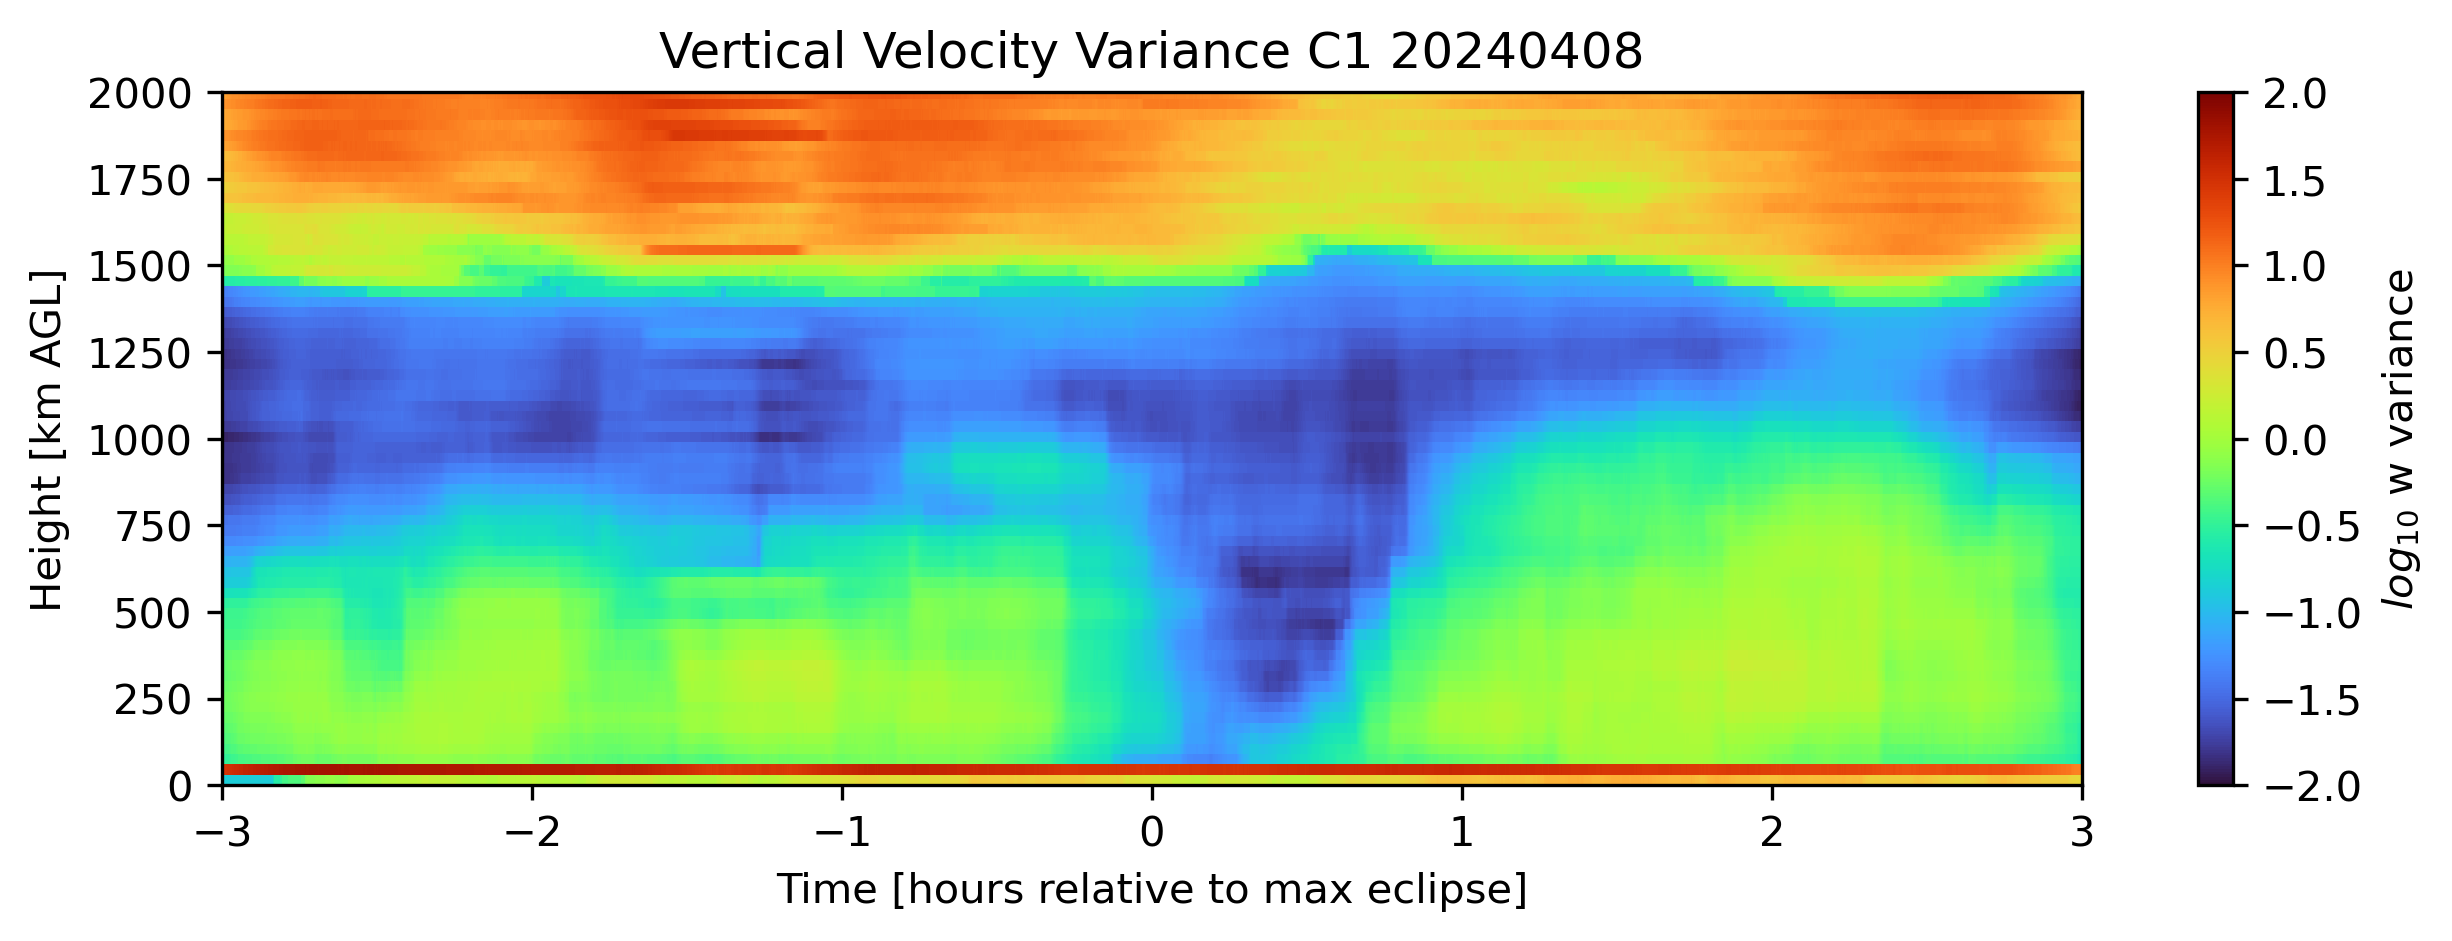

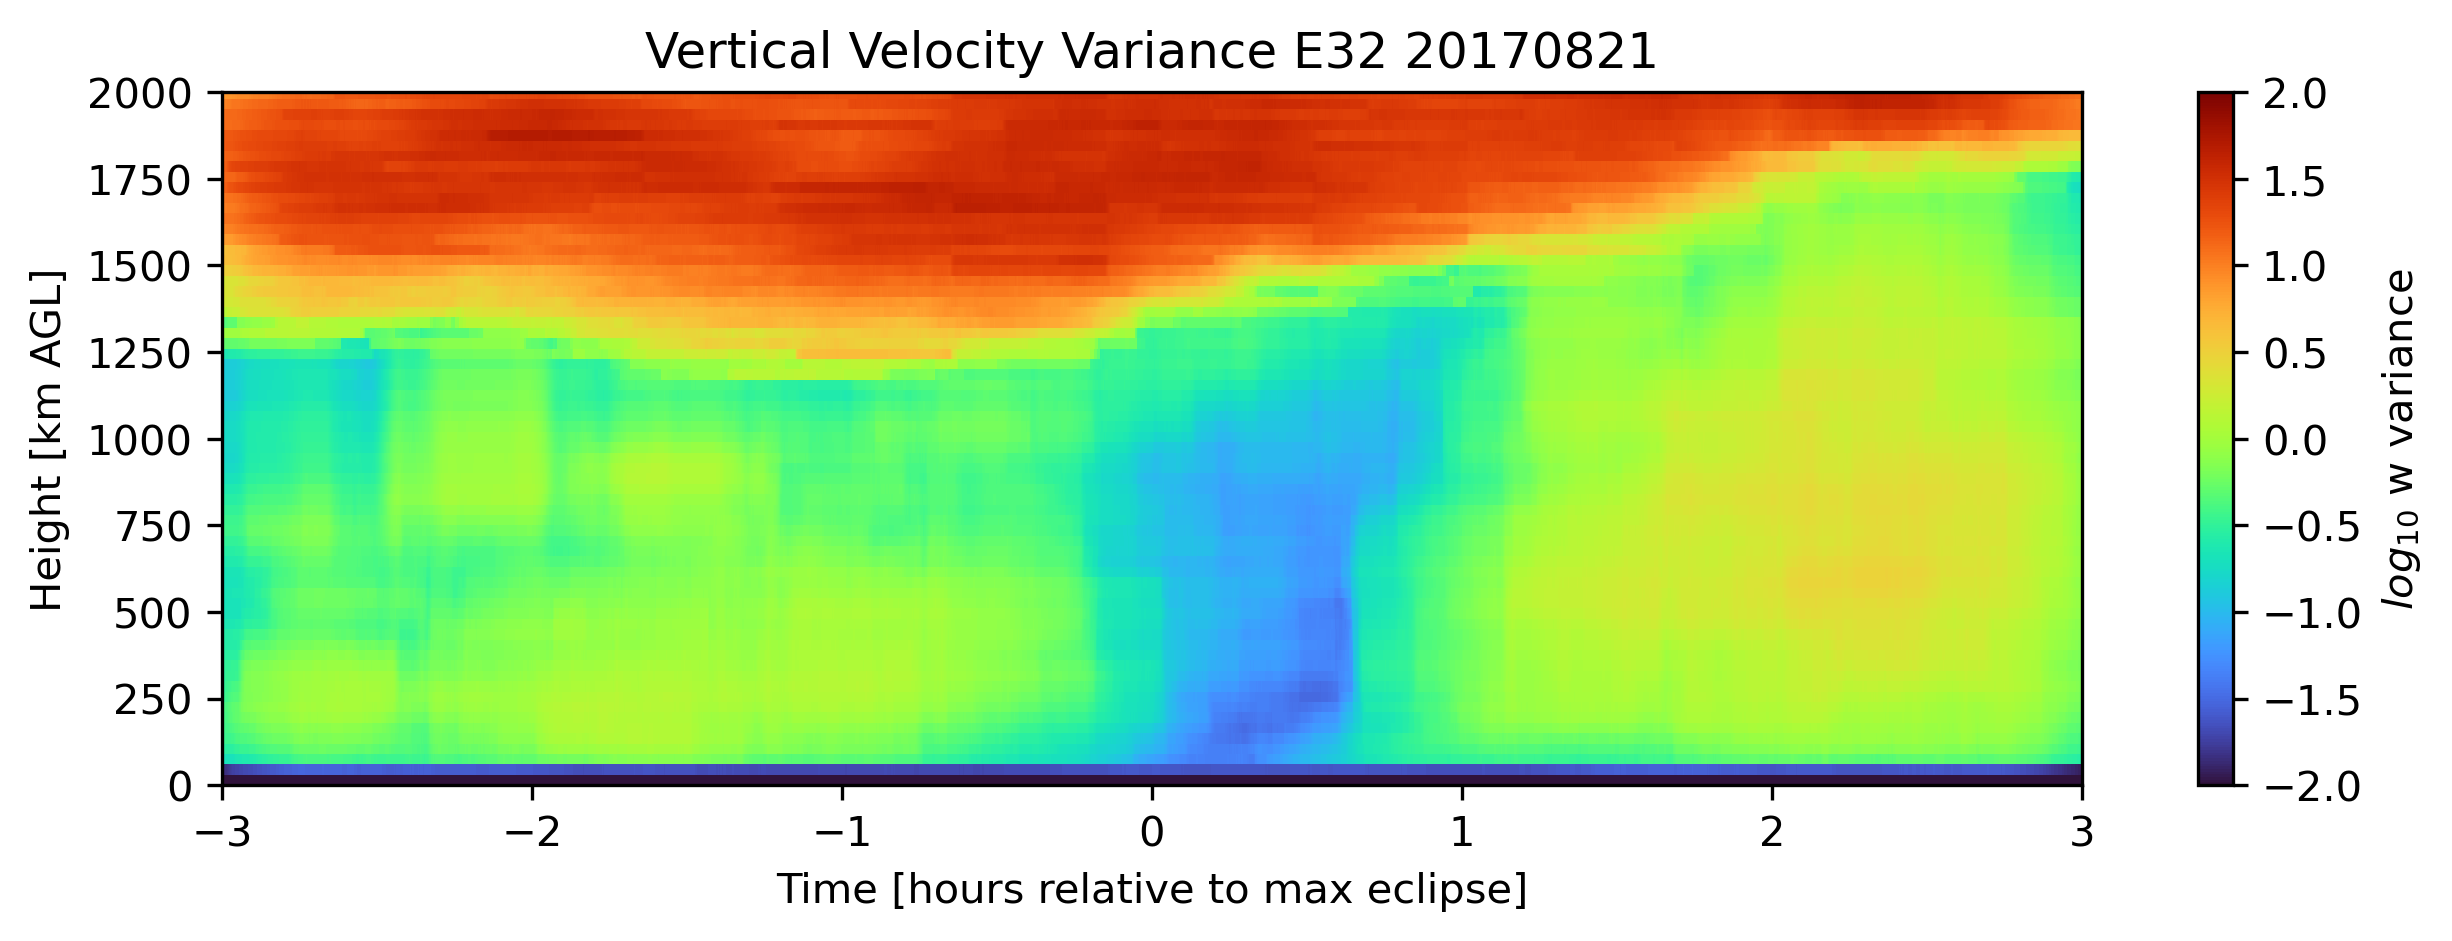

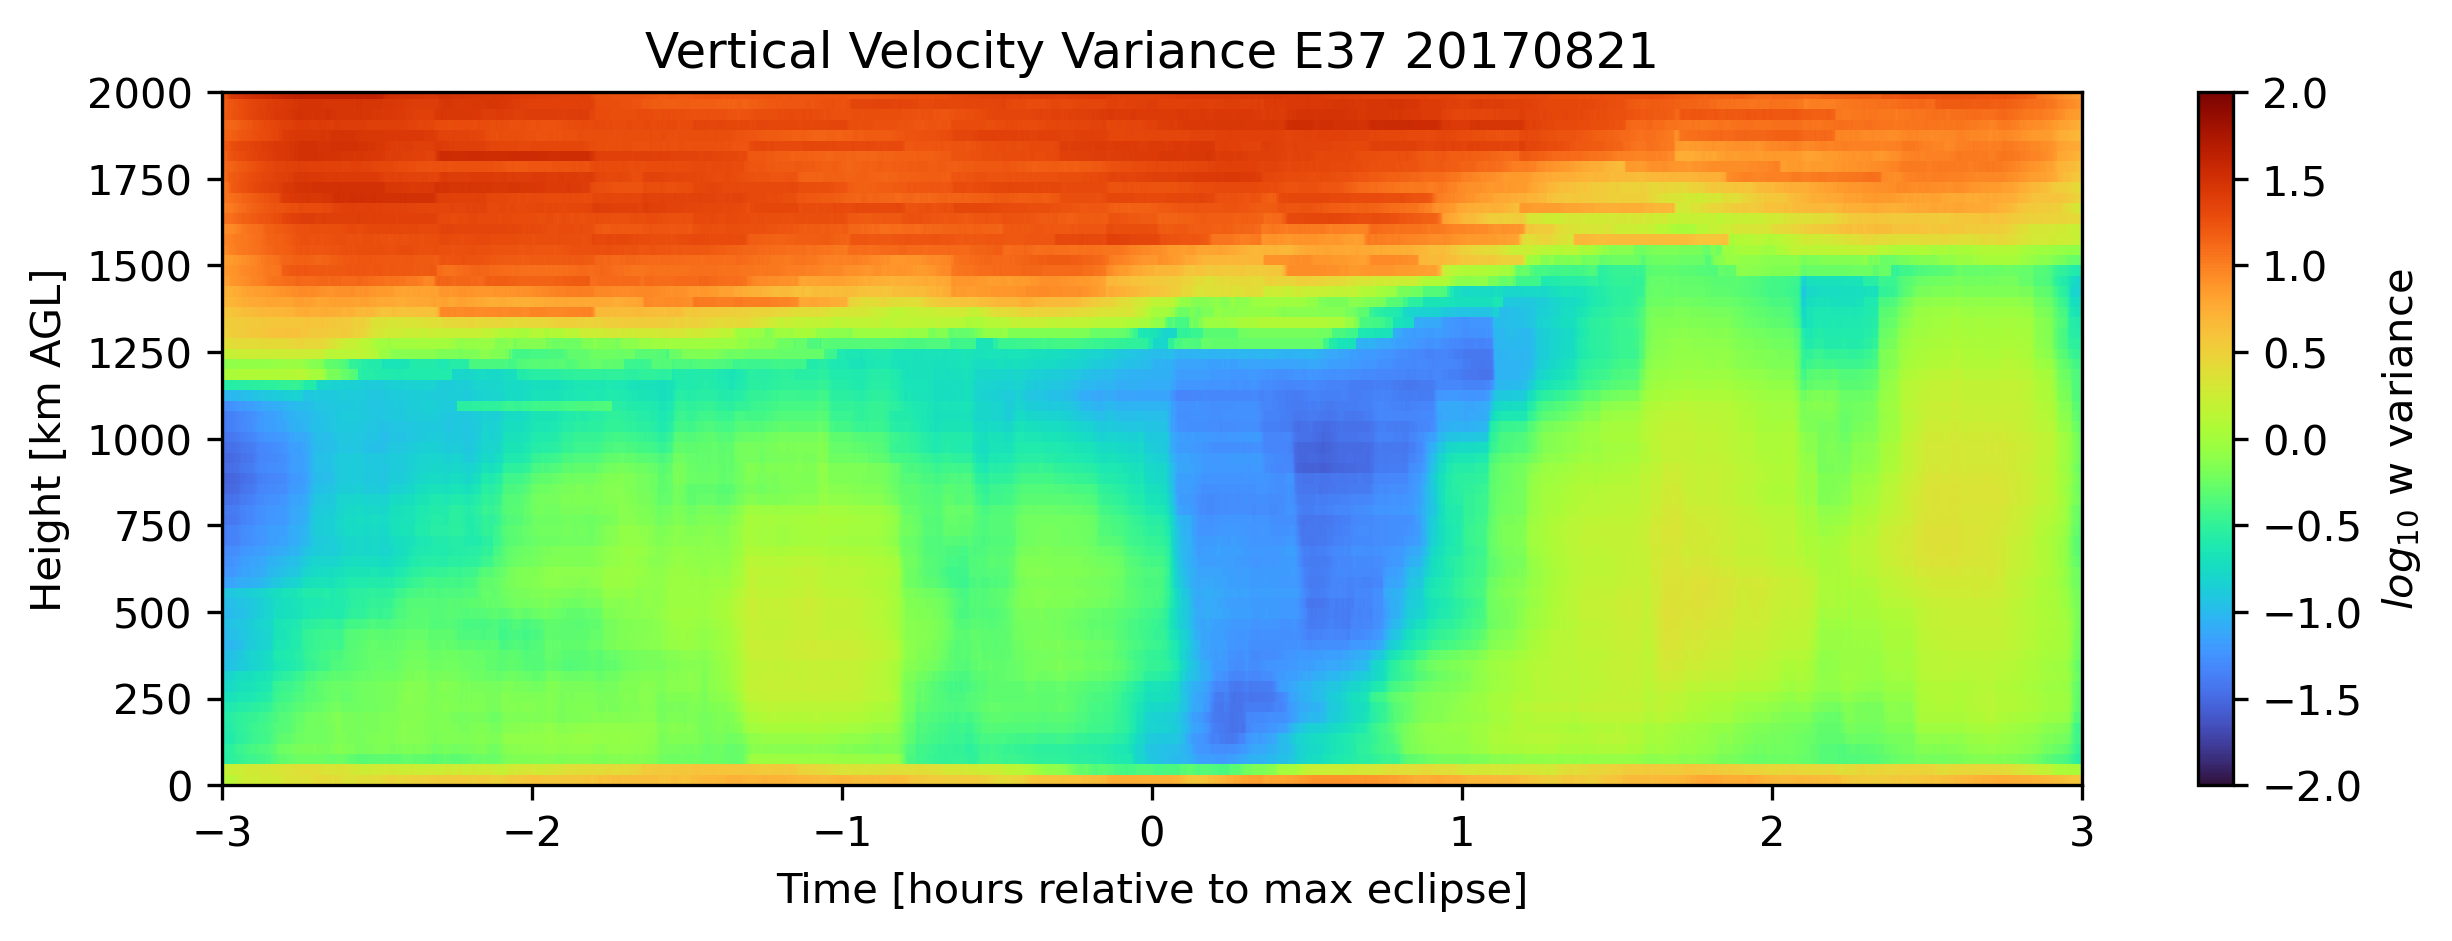

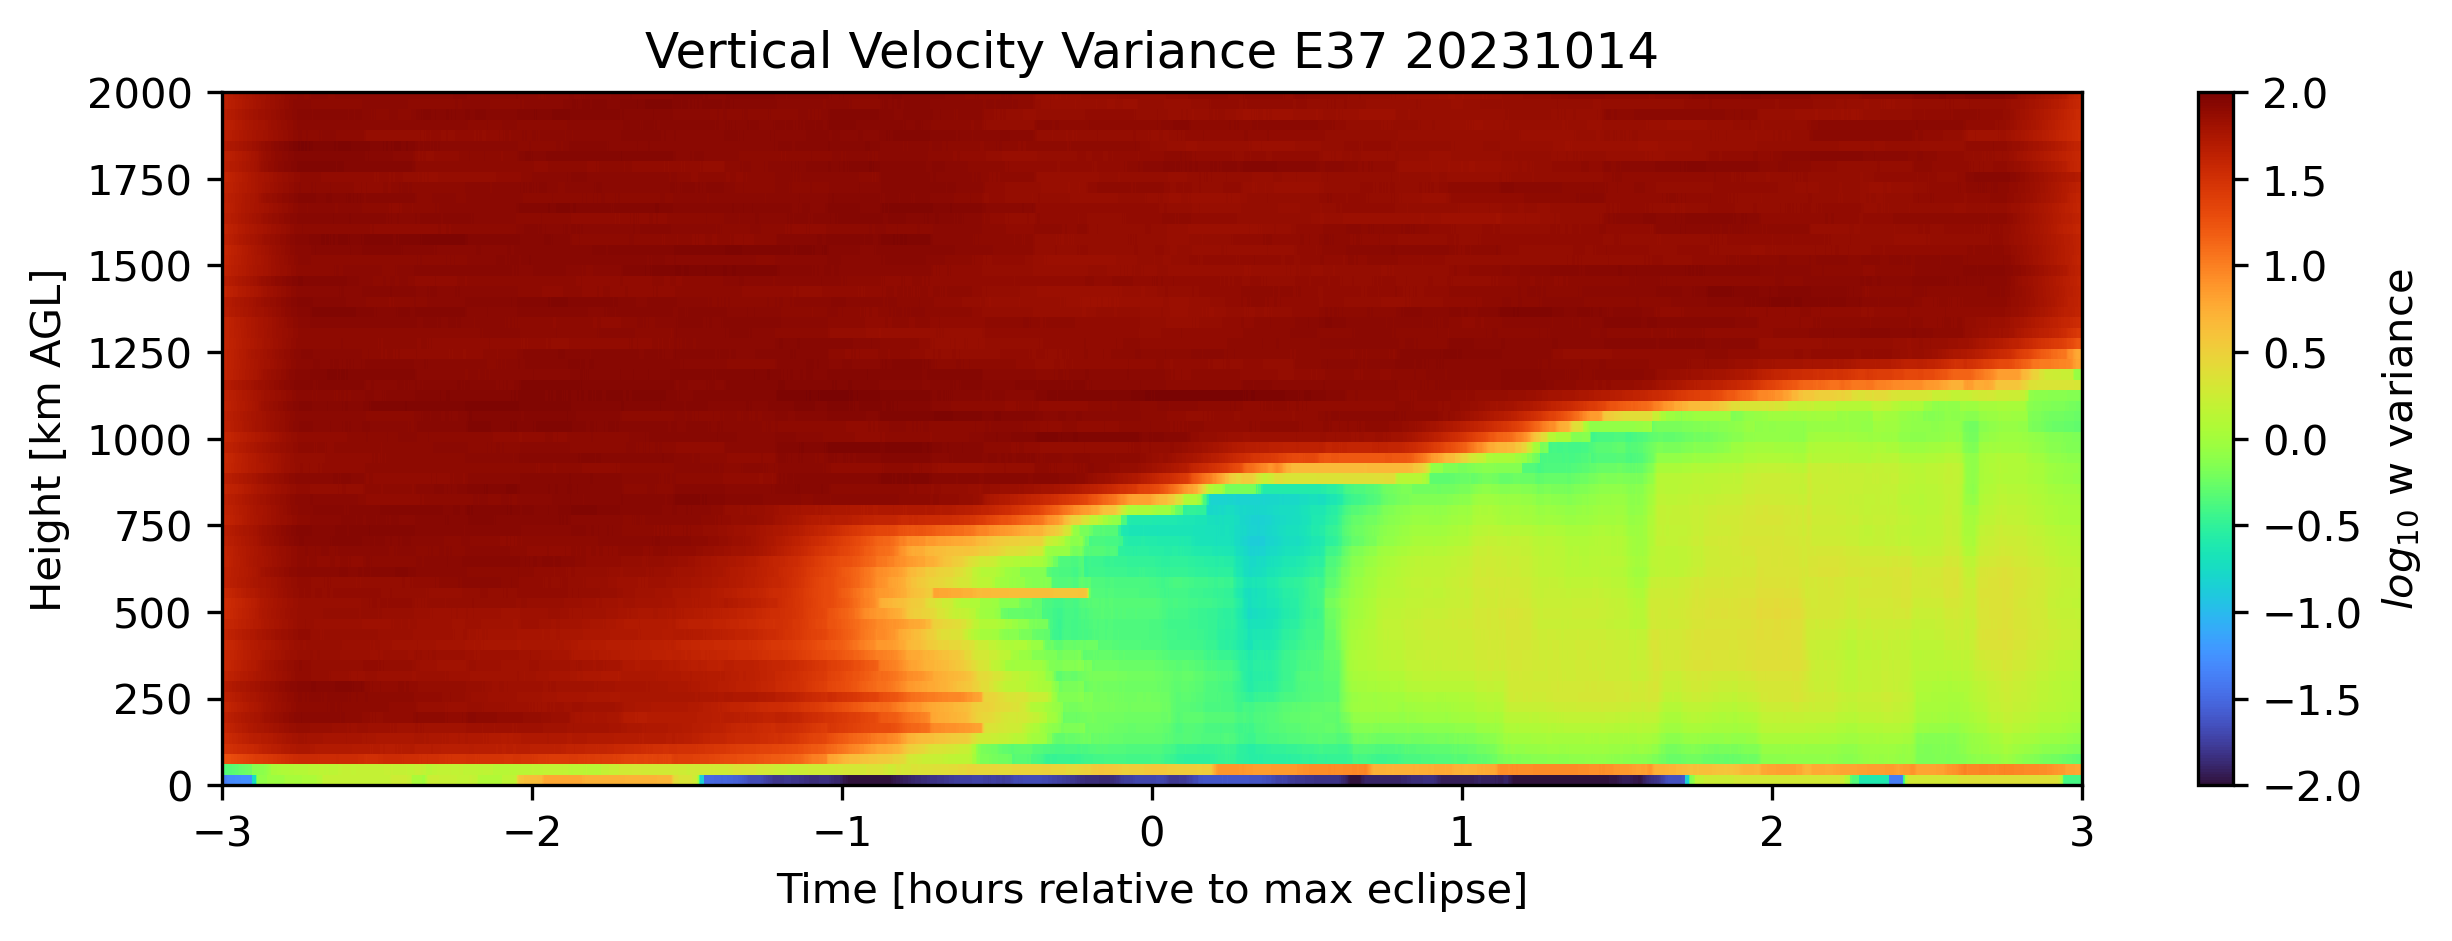

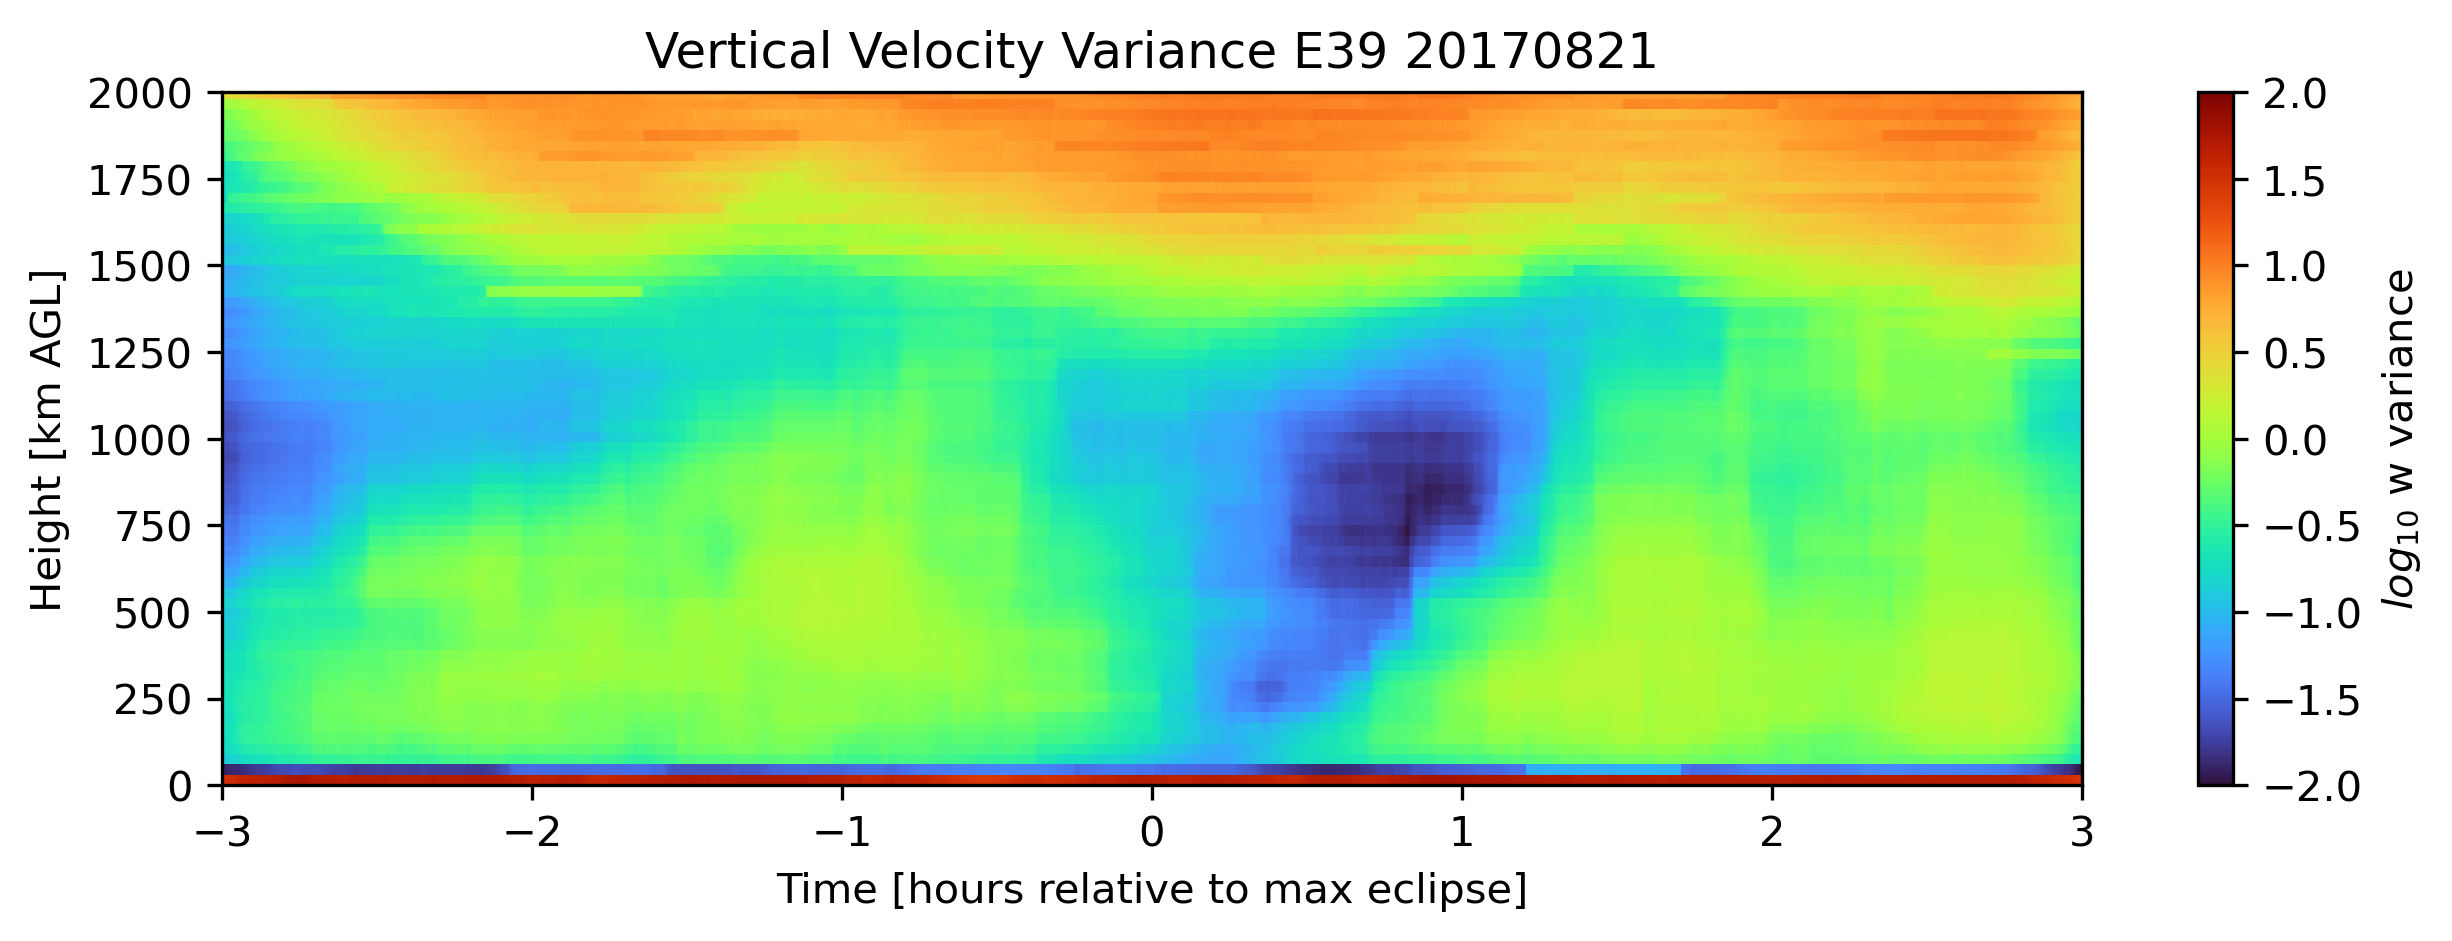

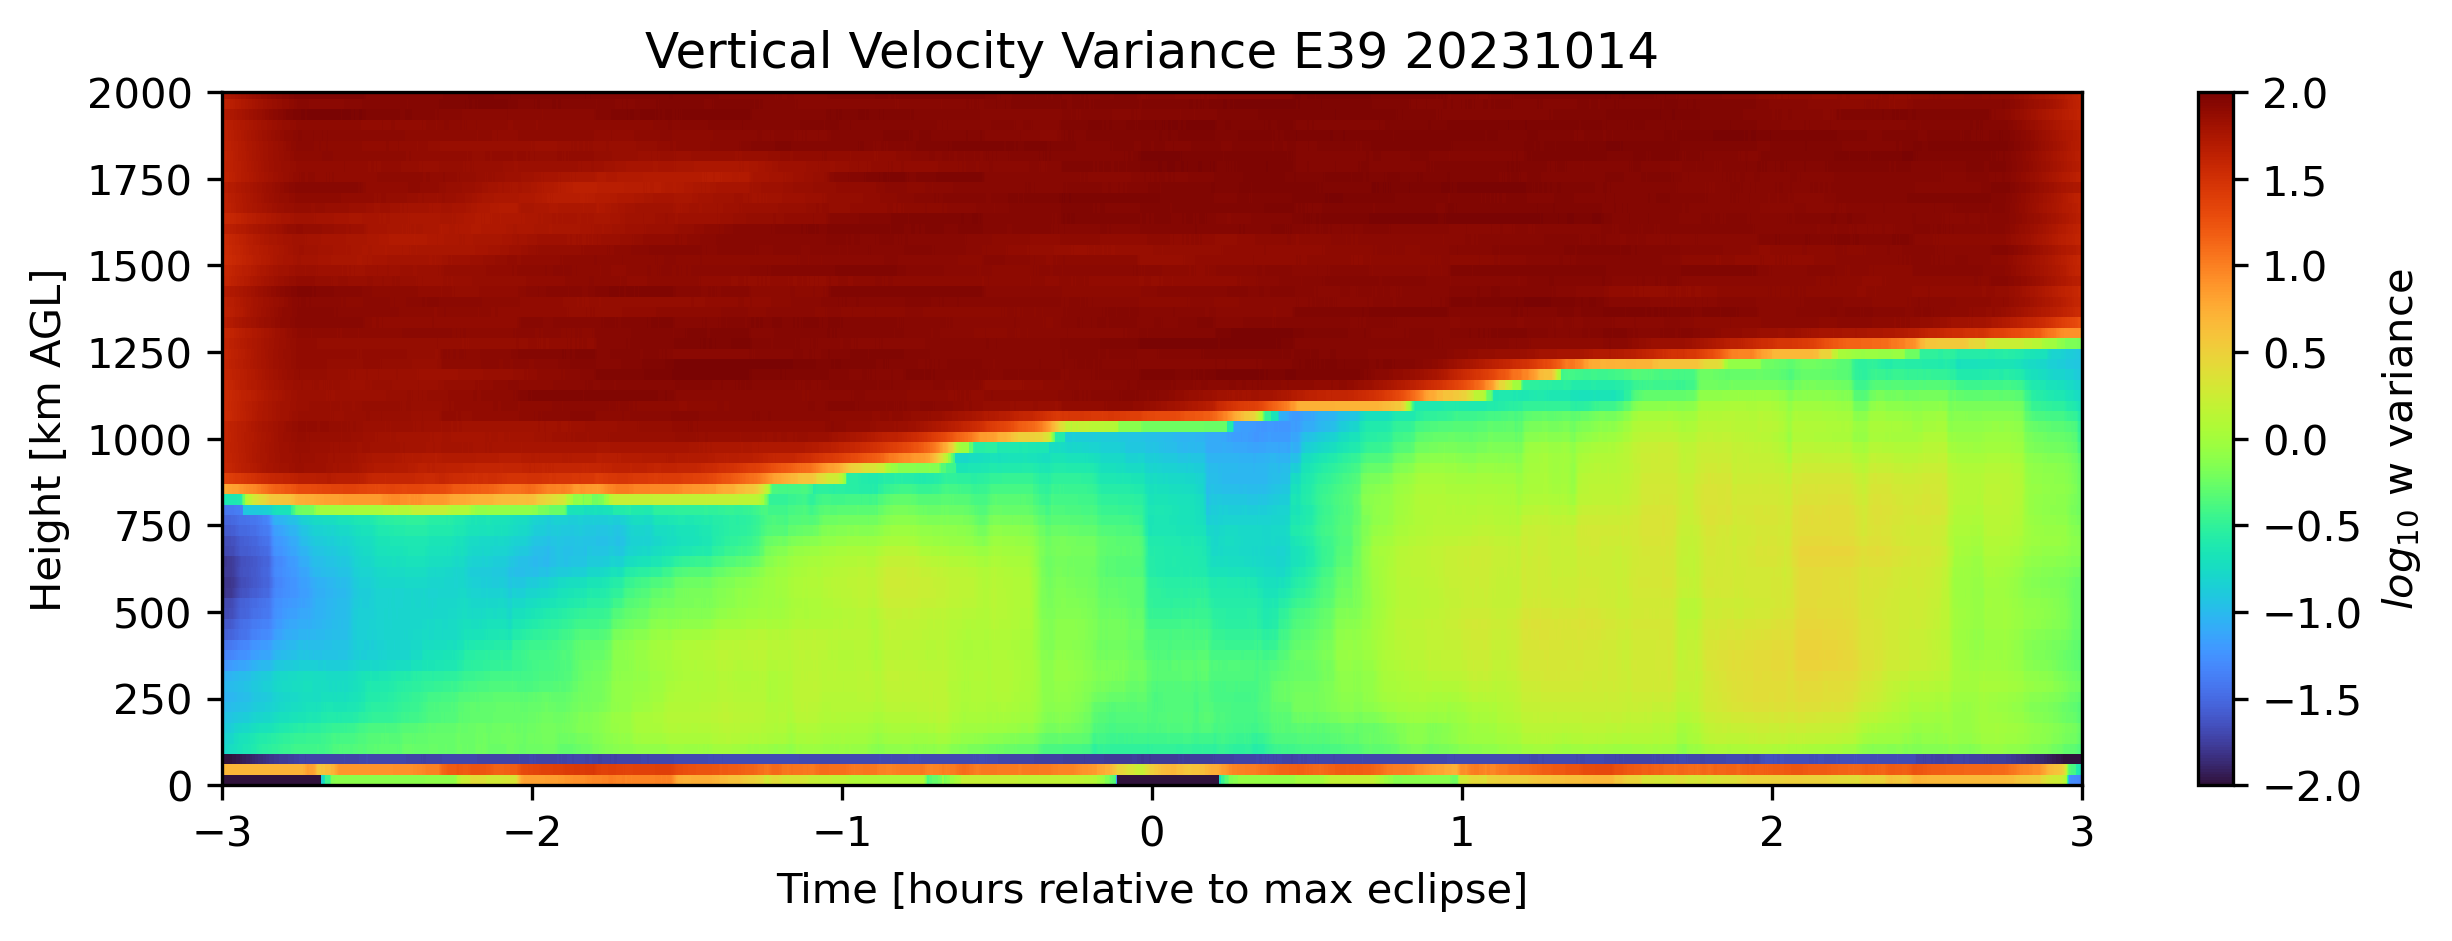

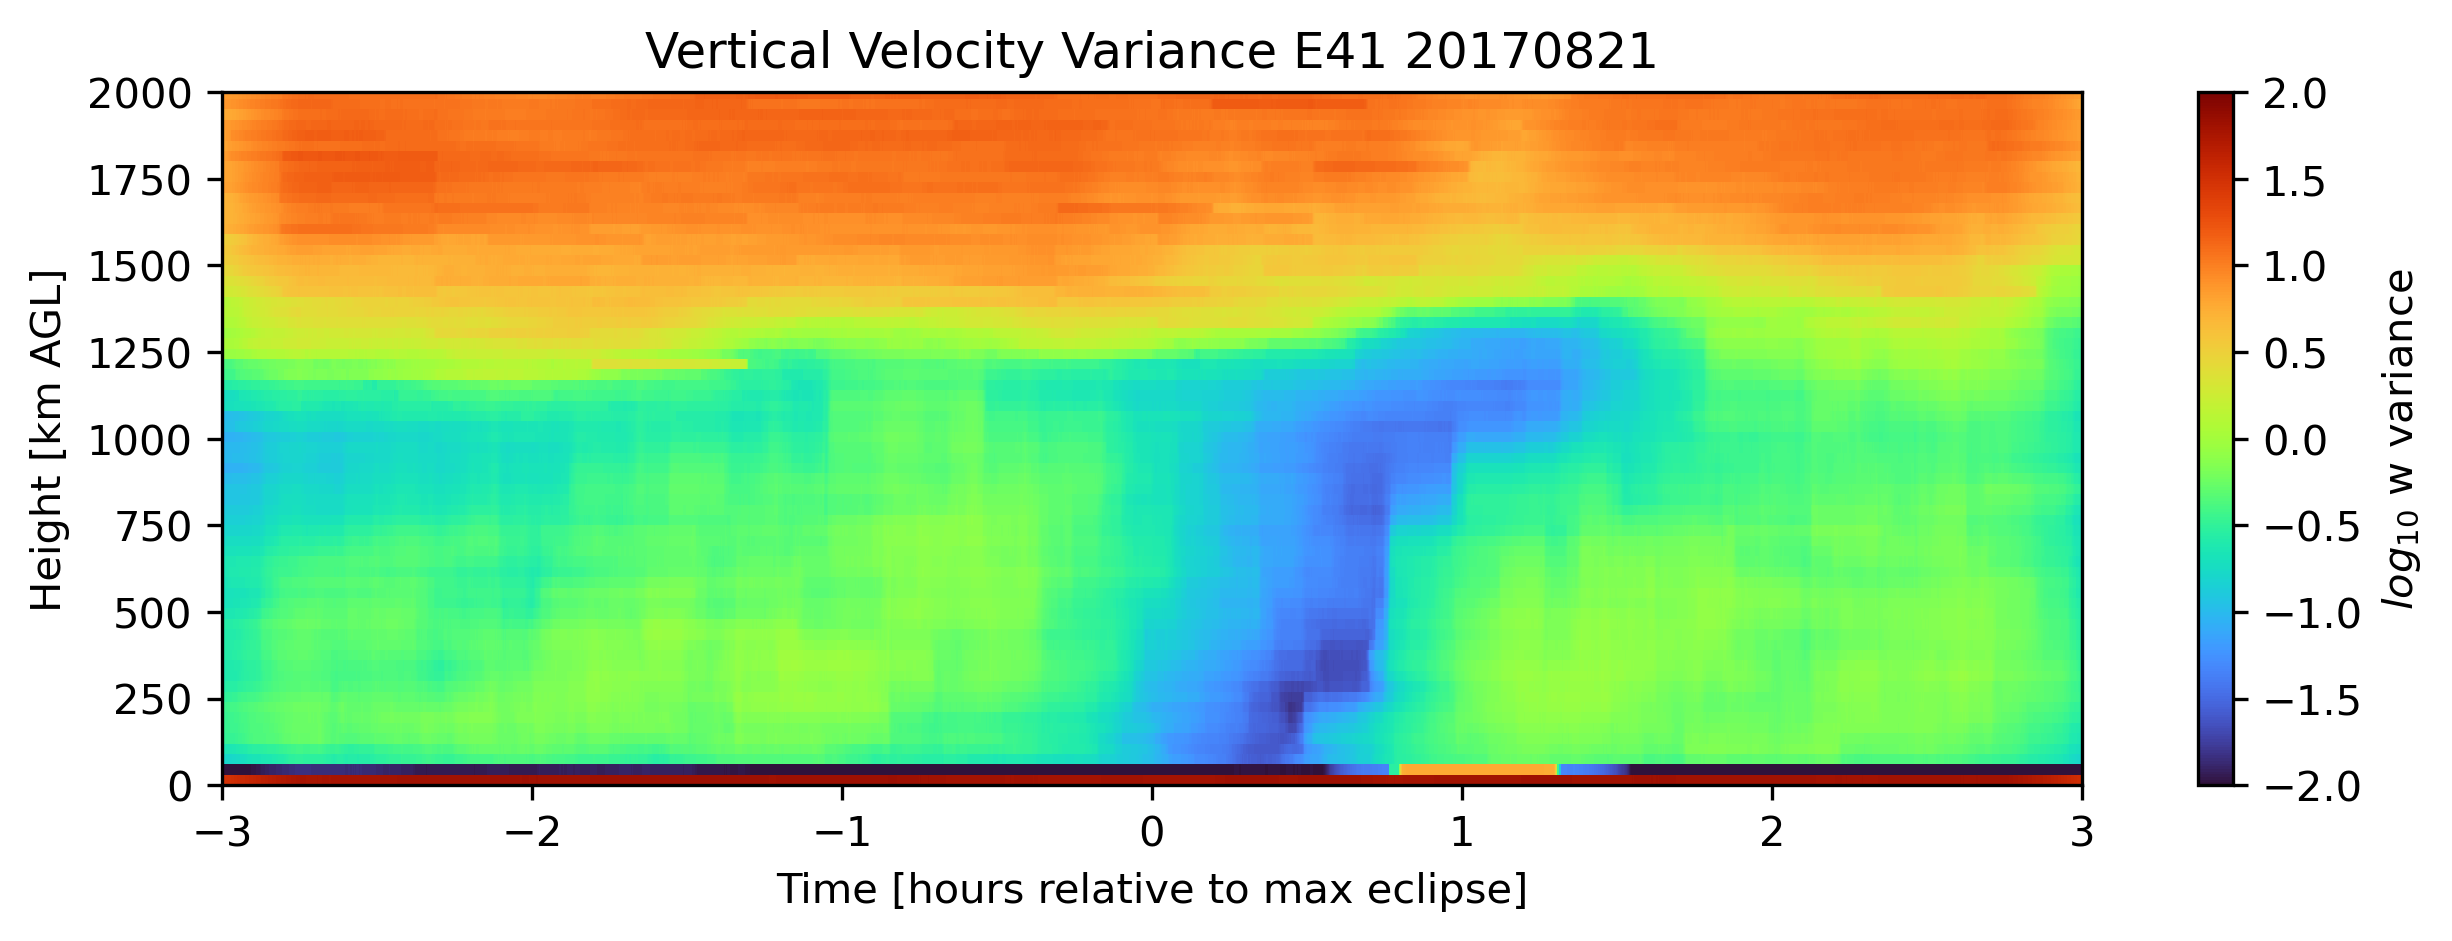

In [5]:
eclipseFacilities = sgpEclipseFacilities
eclipseSites = sgpEclipseSites
eclipseDates = sgpEclipseDates
eclipseTimes = sgpEclipseTimes
eclipseMags = sgpEclipseMags

ctr = 0

for g in np.arange(len(eclipseSites)):


    for h in np.arange(len(eclipseDates)):
        
        

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
    
            if eclipseTimes[h]<3:
    
                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
    
                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
            
            dl.time = dl.time - eclipseTimes[h]

        except:
            
            ctr=ctr+1
            continue
        
        interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

        wNew = interpFunc(timeNew, heightNew)


        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)

        for i in range(totalStartIdx, totalEndIdx):
    
       
            meanW = np.mean(wNew[i-900:i+900,:],axis=0)
            wPrime[i,:] = wNew[i,:]-meanW

        for i in range(totalStartIdx, totalEndIdx):

            wVar[i,:,ctr] = np.var(wPrime[i-900:i+900,:],axis=0)


        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        cbar = plt.colorbar()
        cbar.set_label('$log_{10}$ w variance')
        plt.title('Vertical Velocity Variance ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        plt.xlabel('Time [hours relative to max eclipse]')
        plt.ylabel('Height [km AGL]')
        plt.show()

        saveDate[ctr] = eclipseDates[h]
        ctr = ctr+1


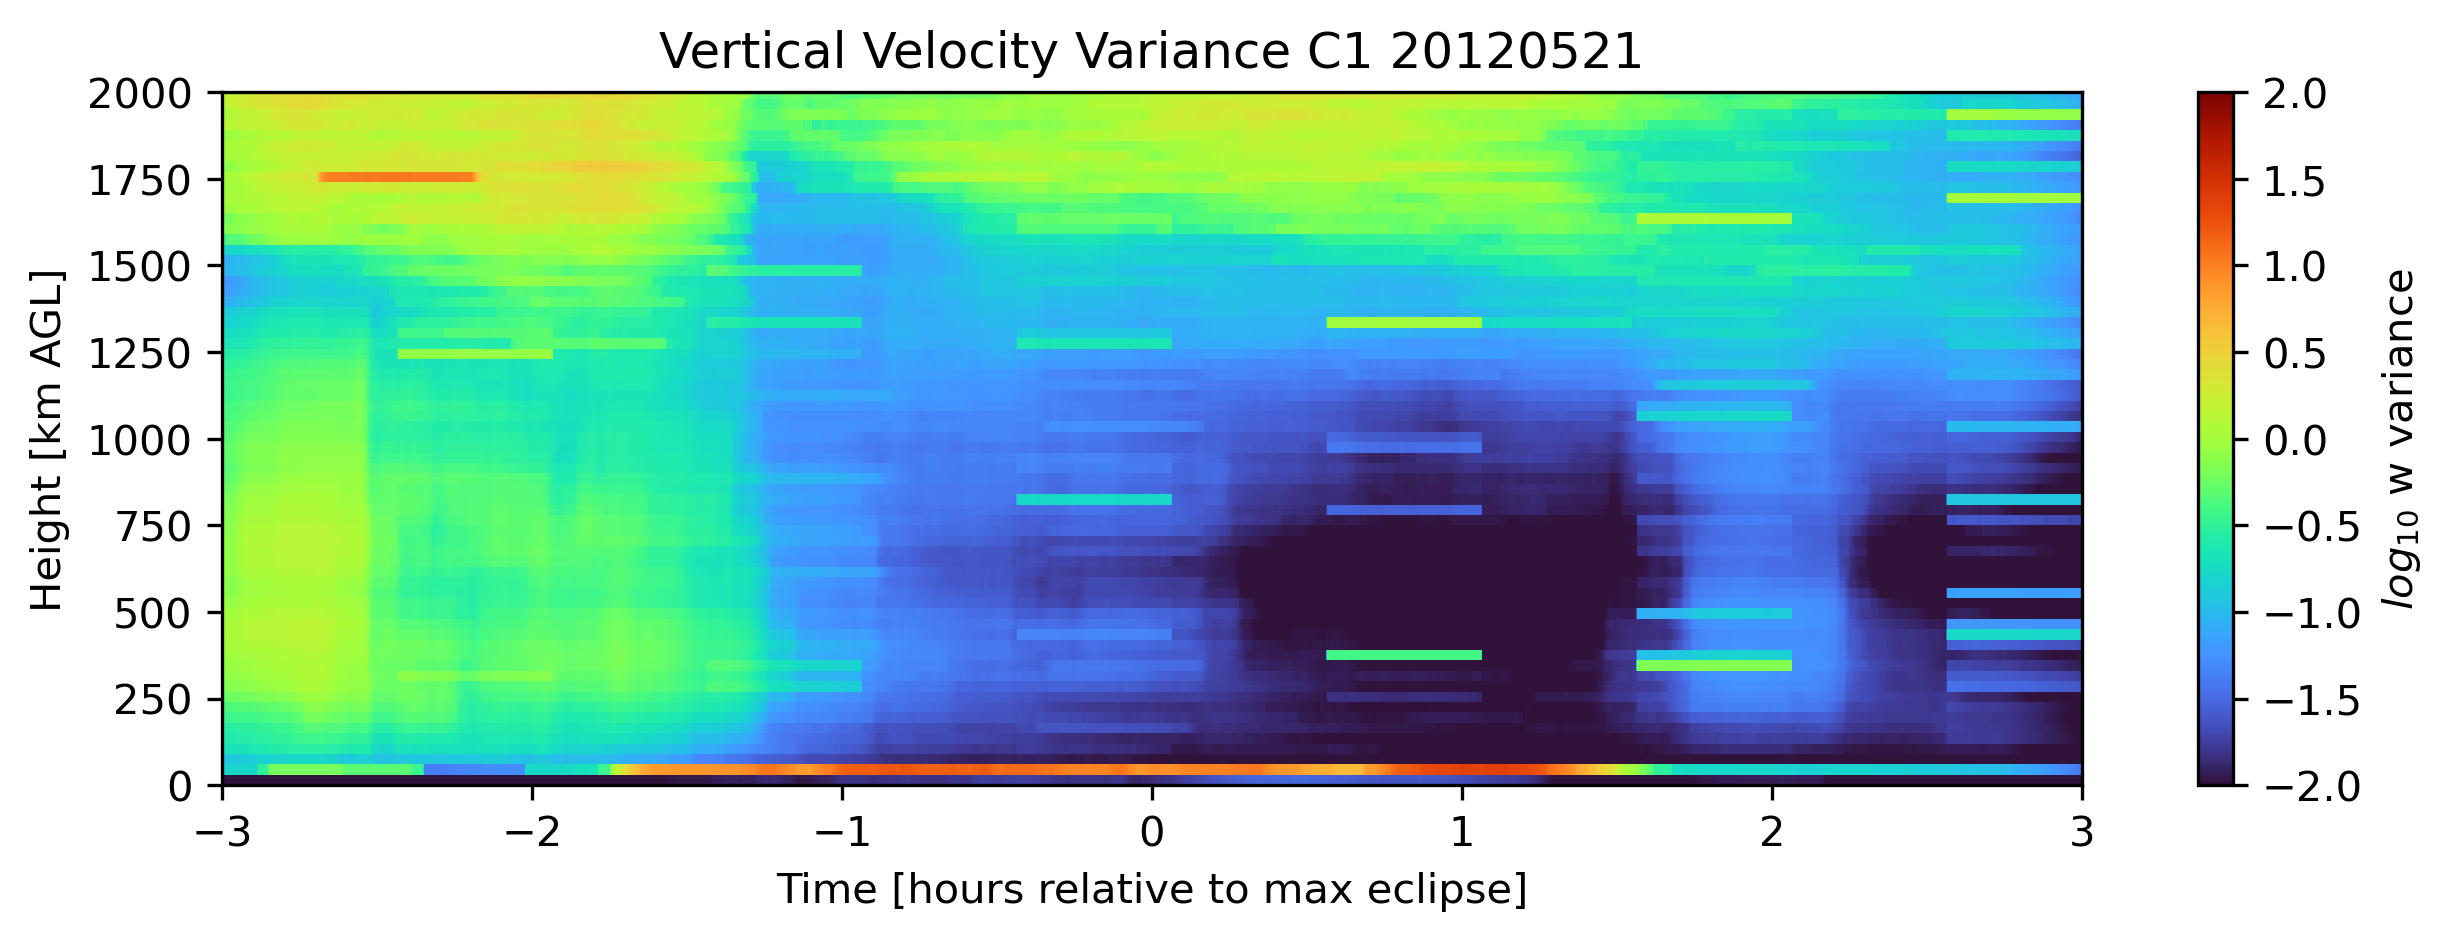

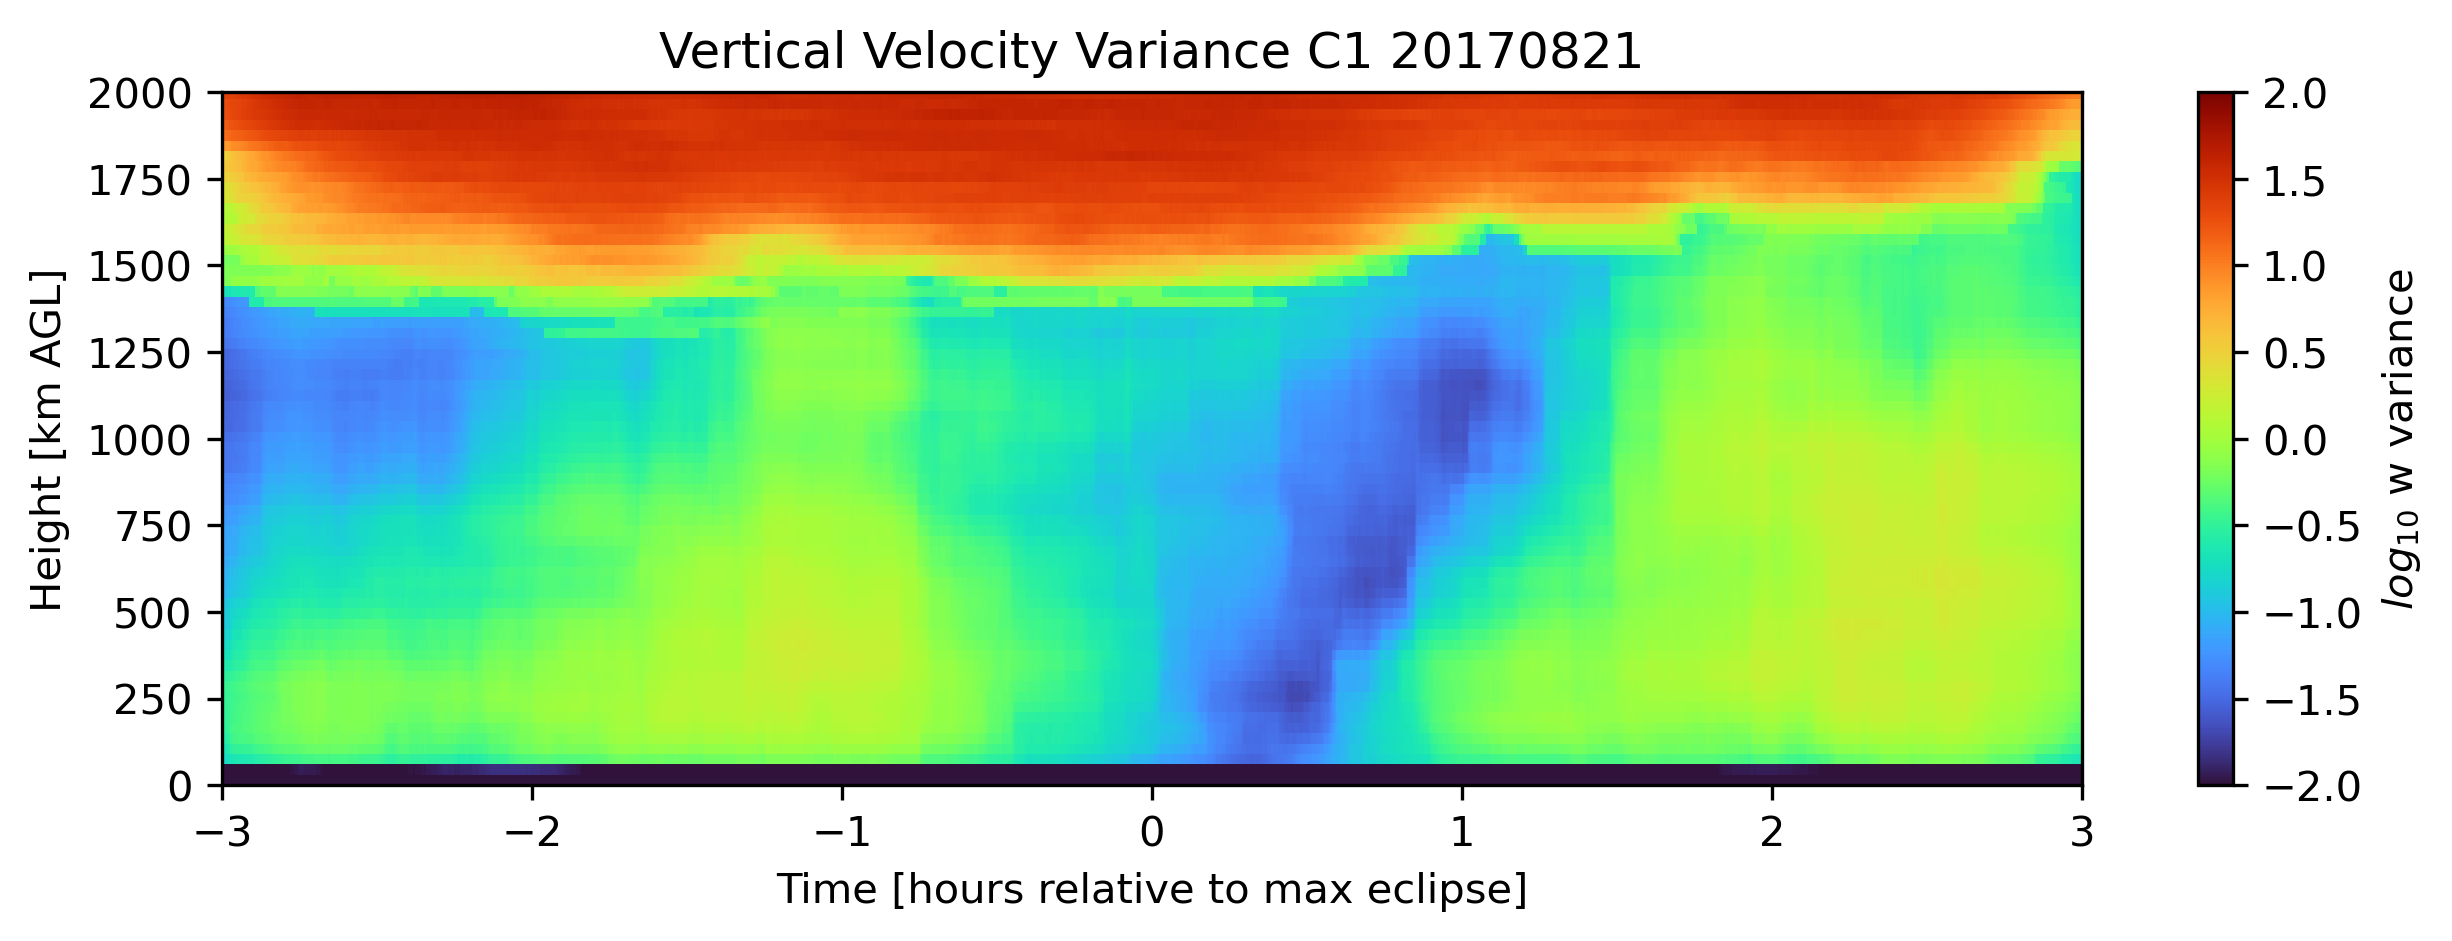

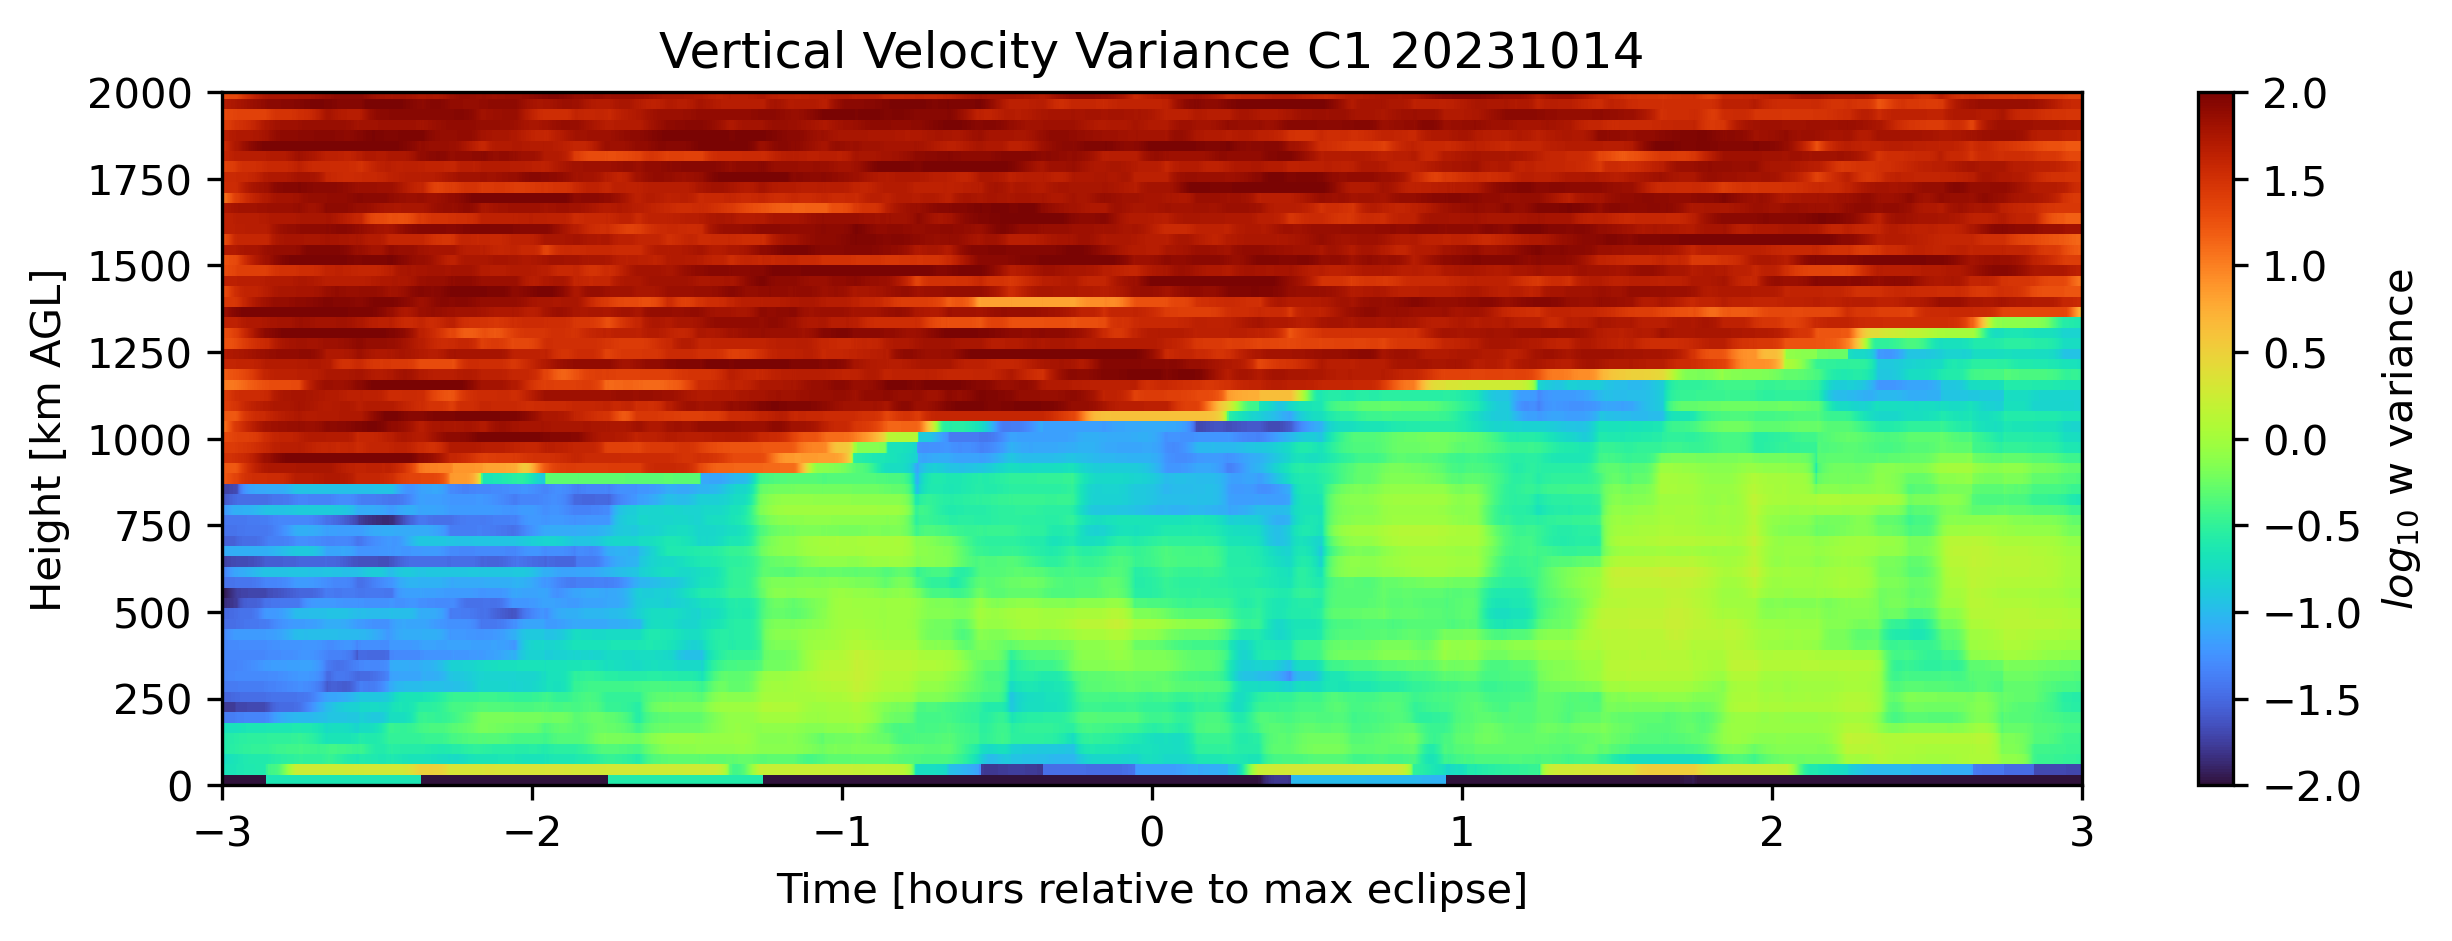

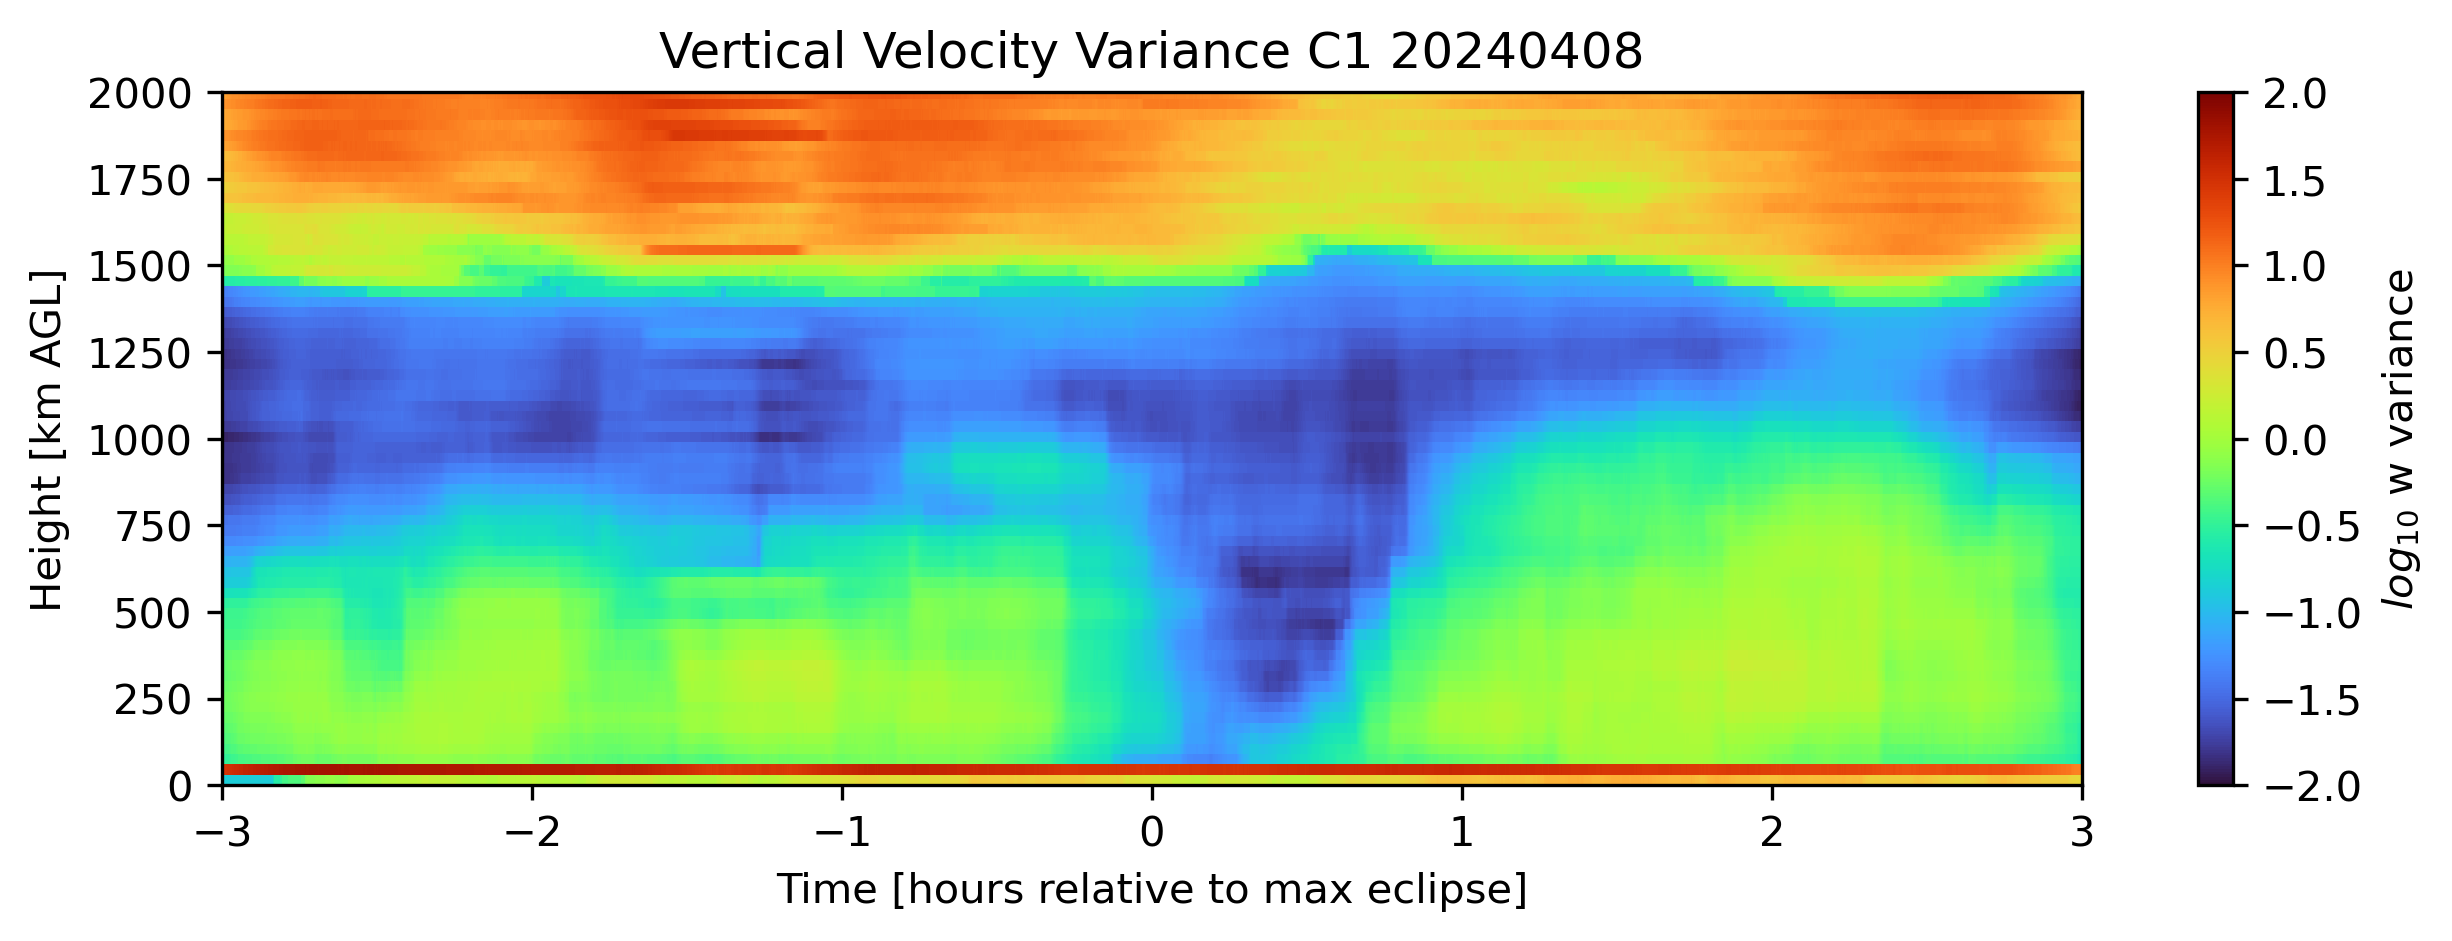

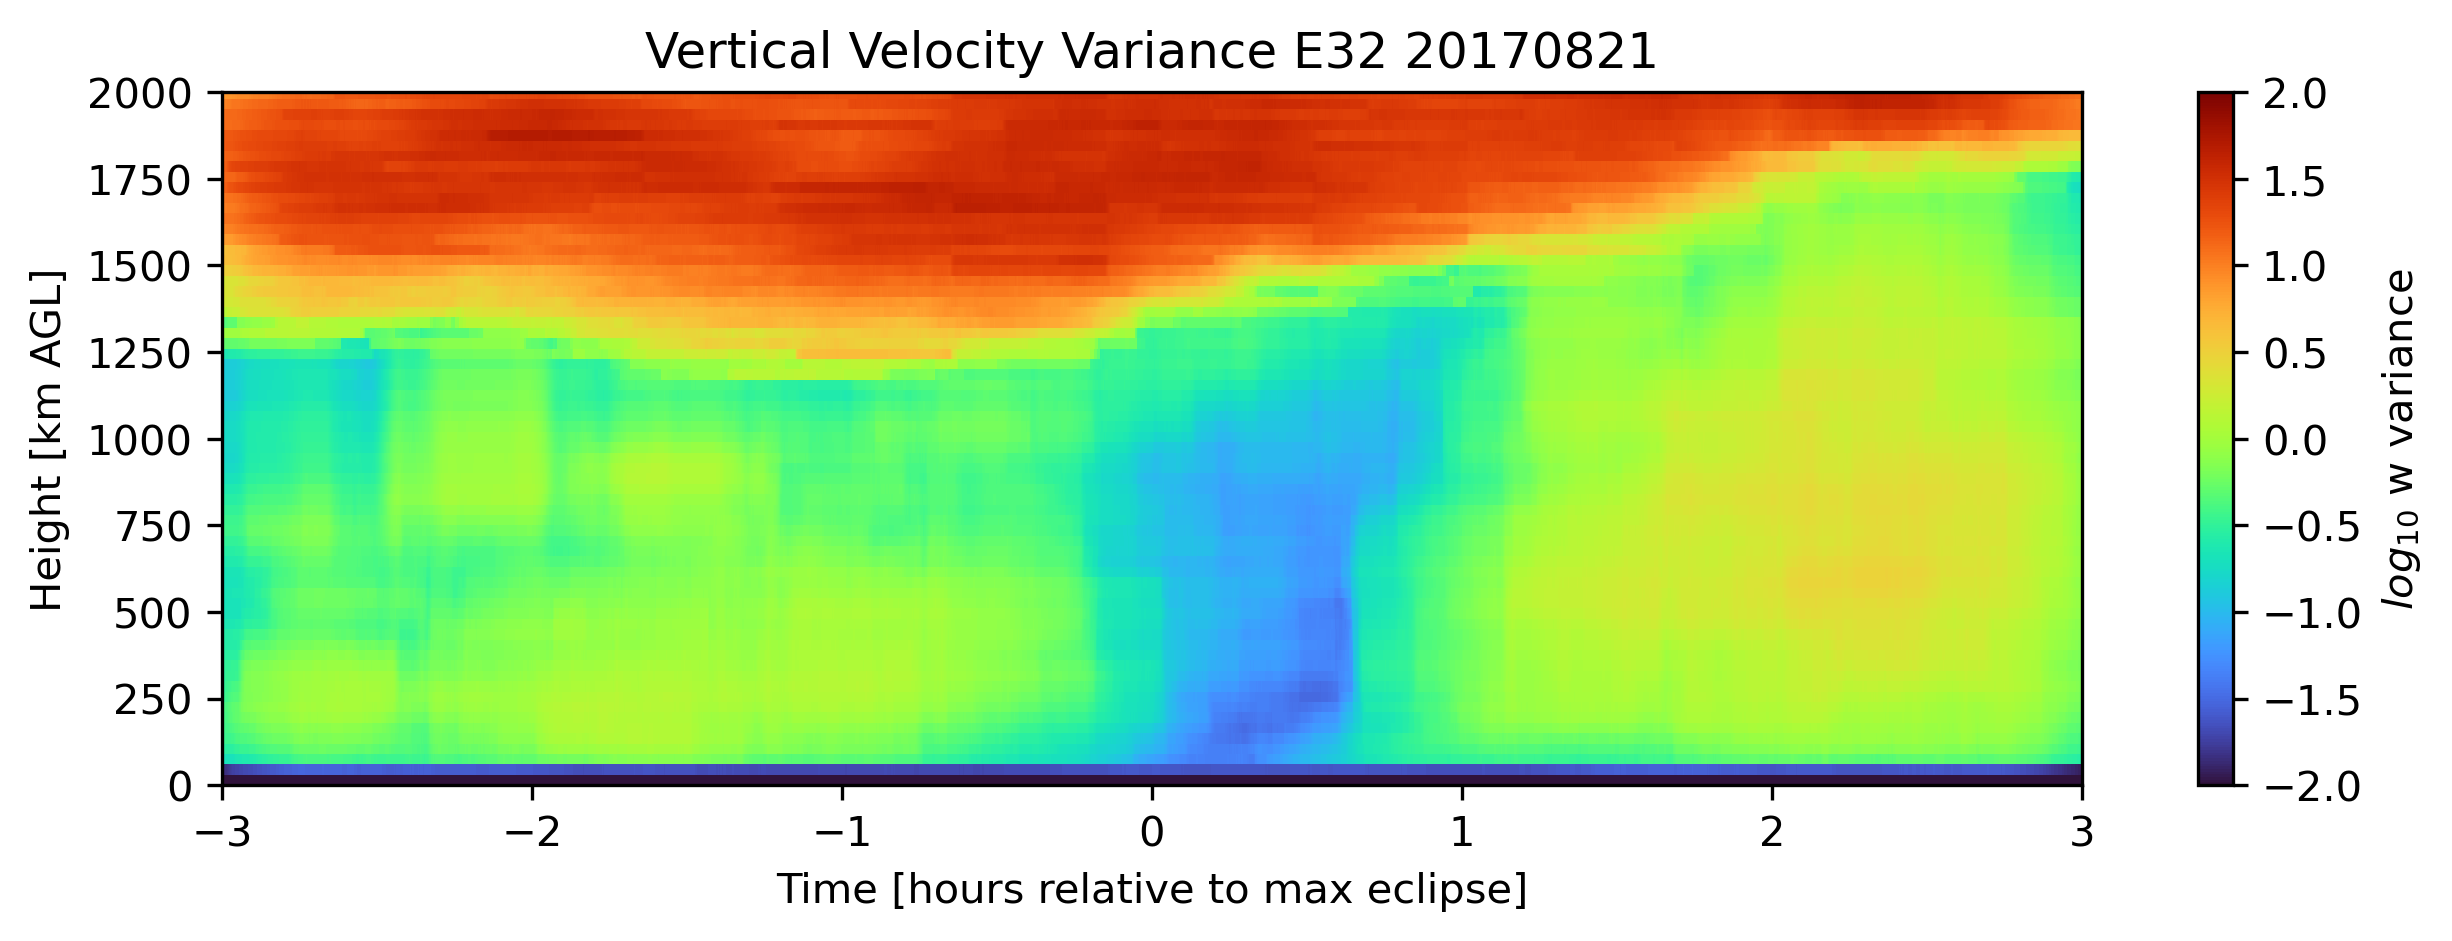

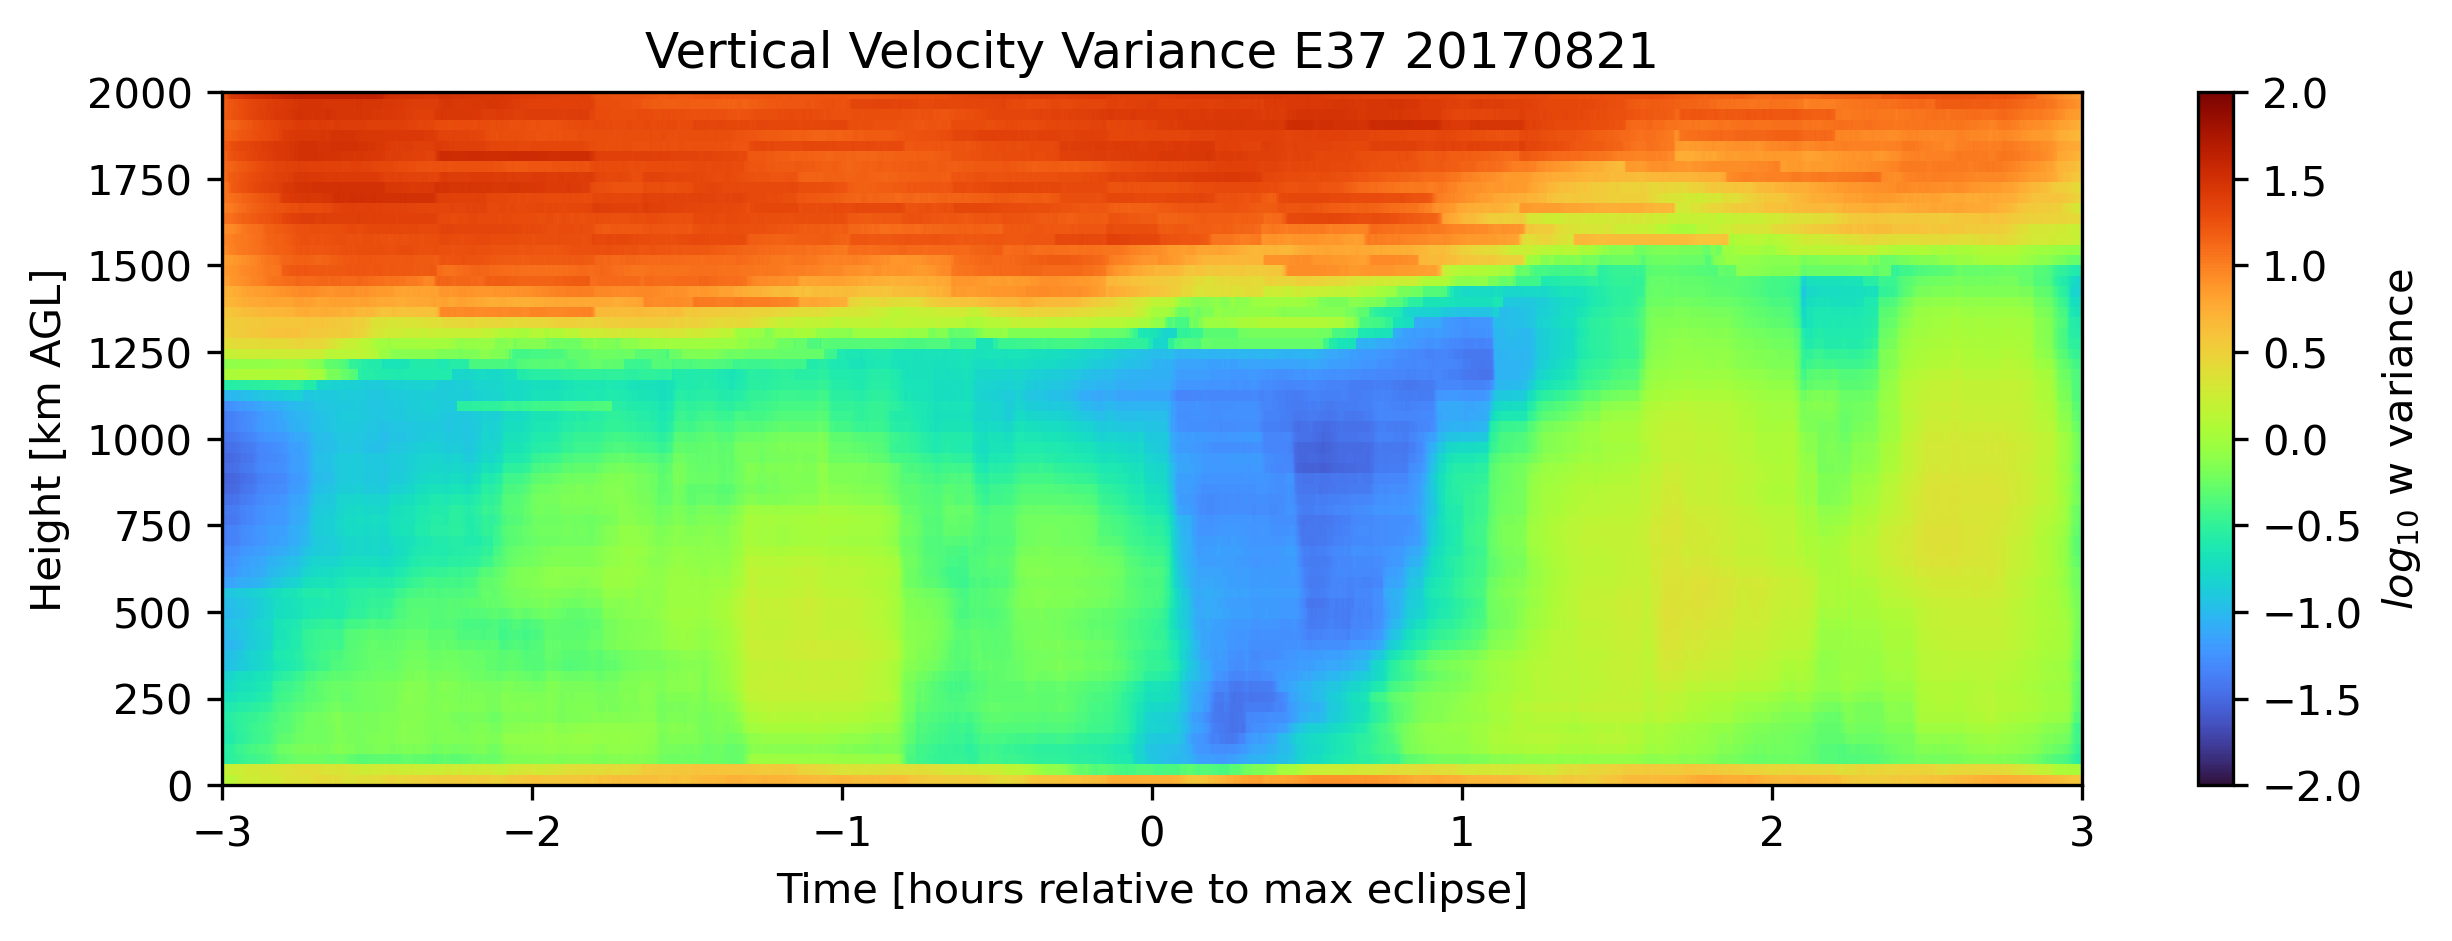

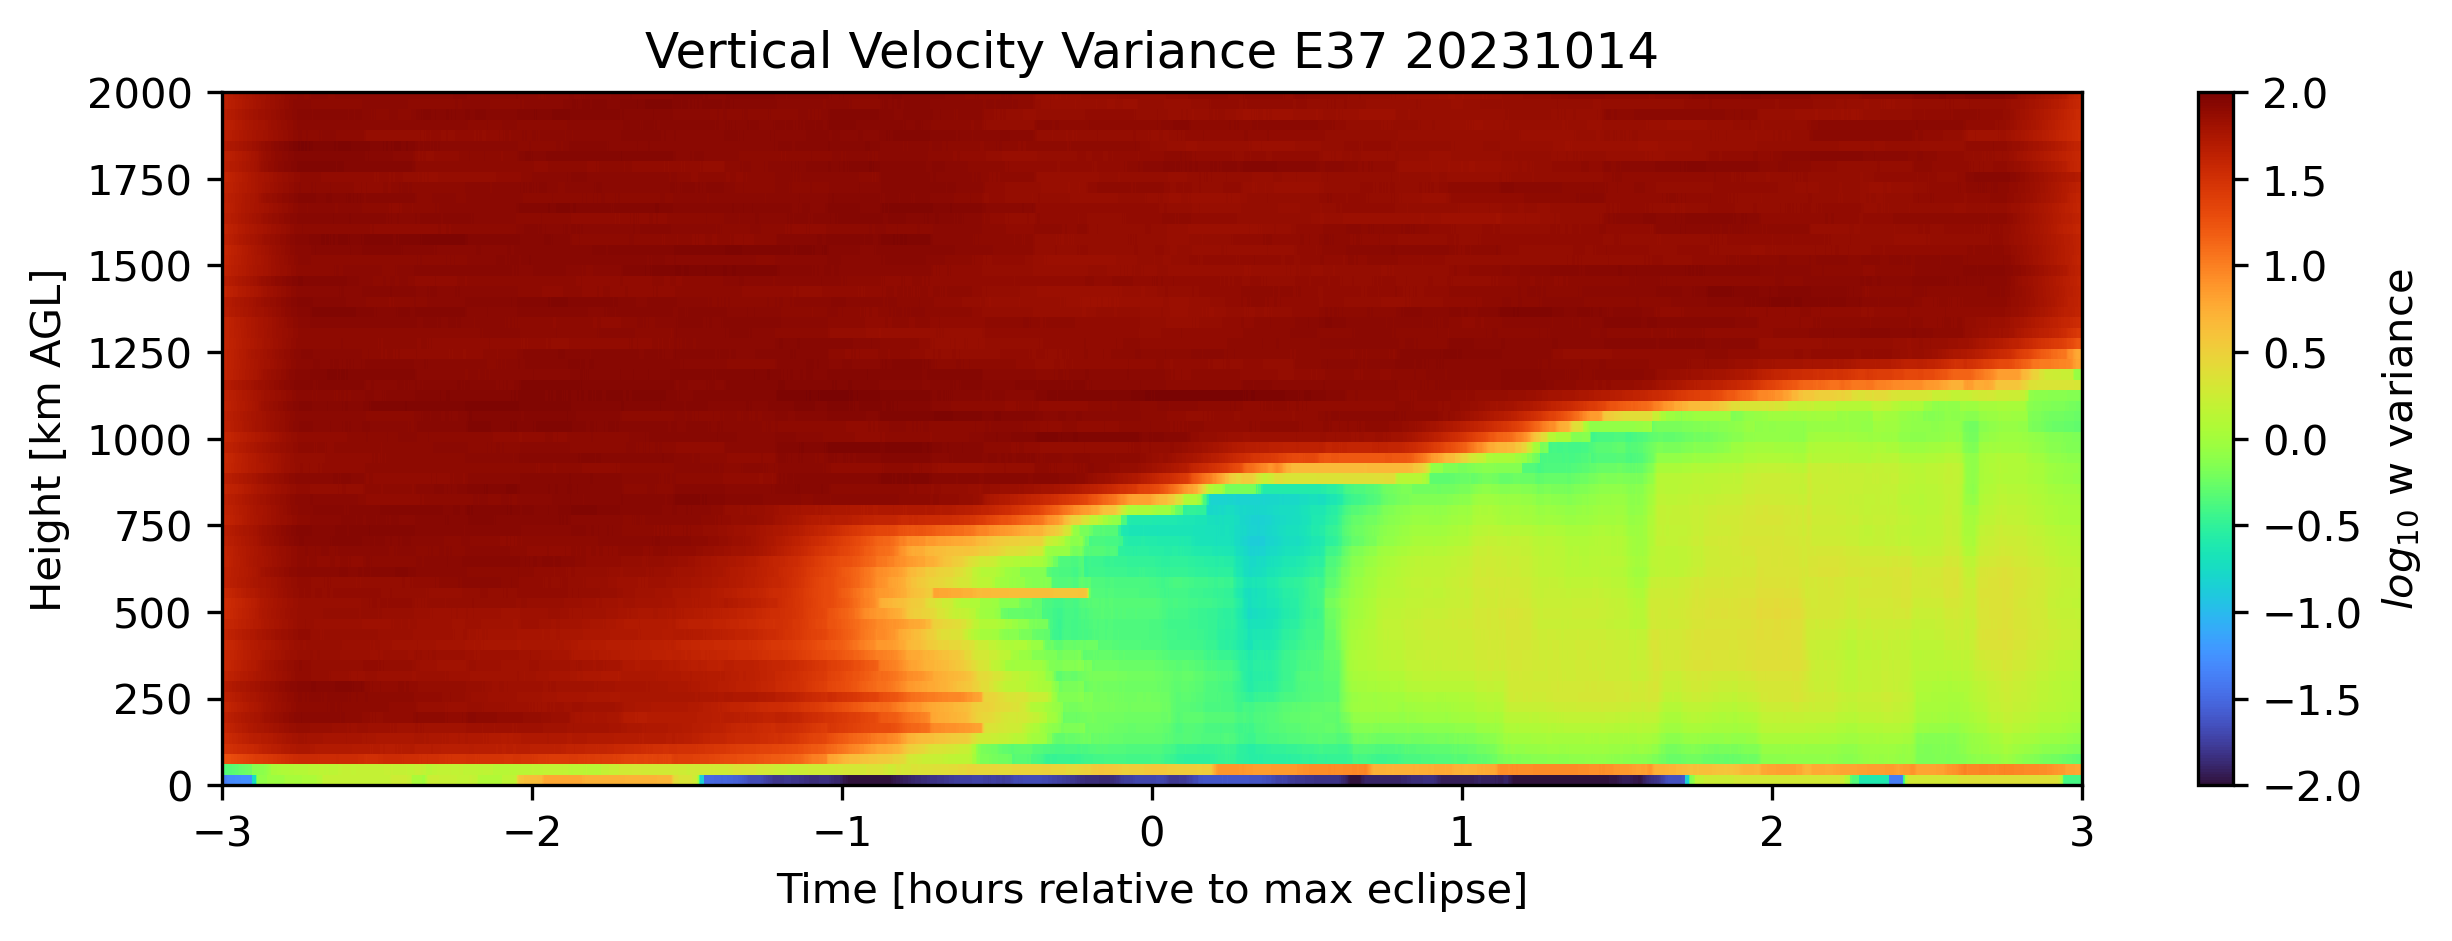

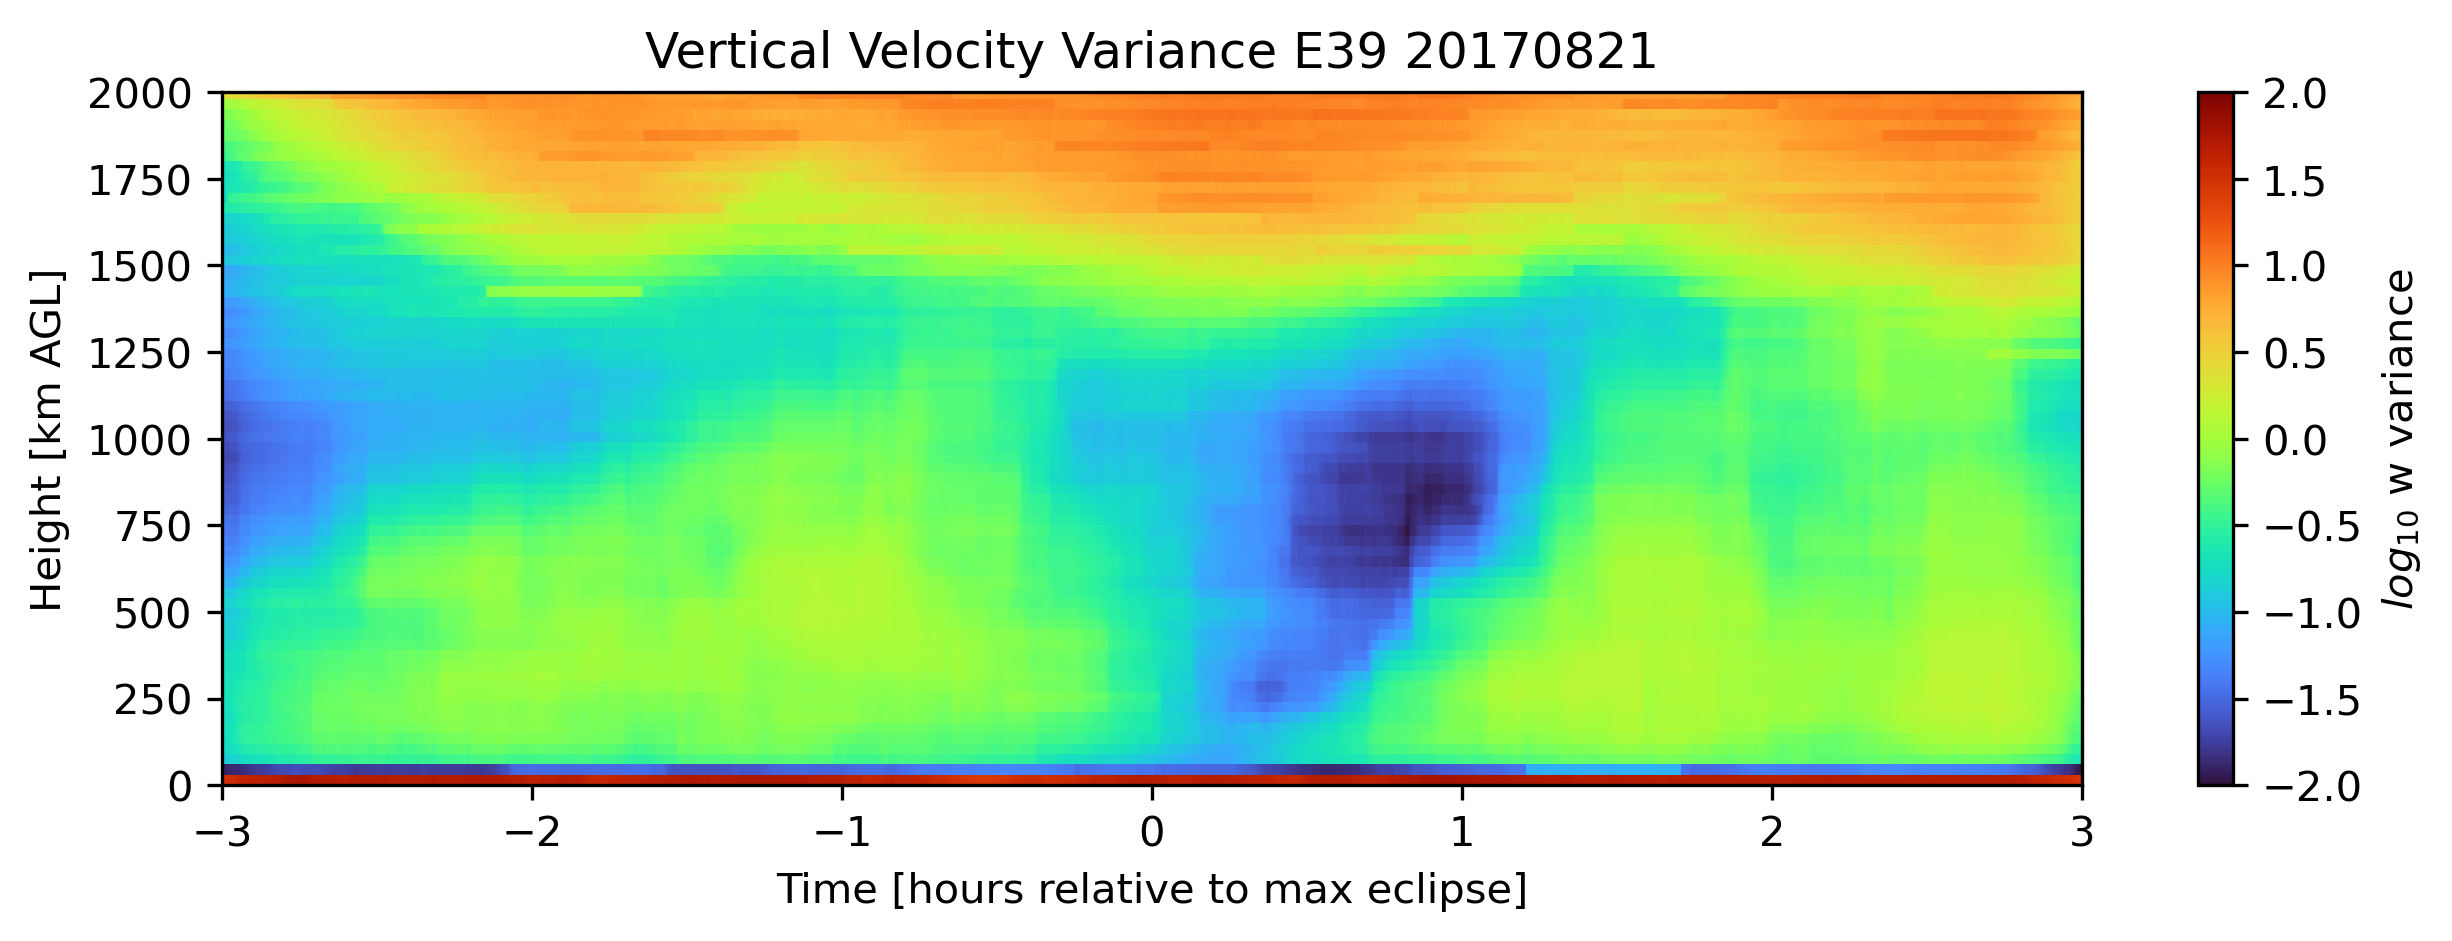

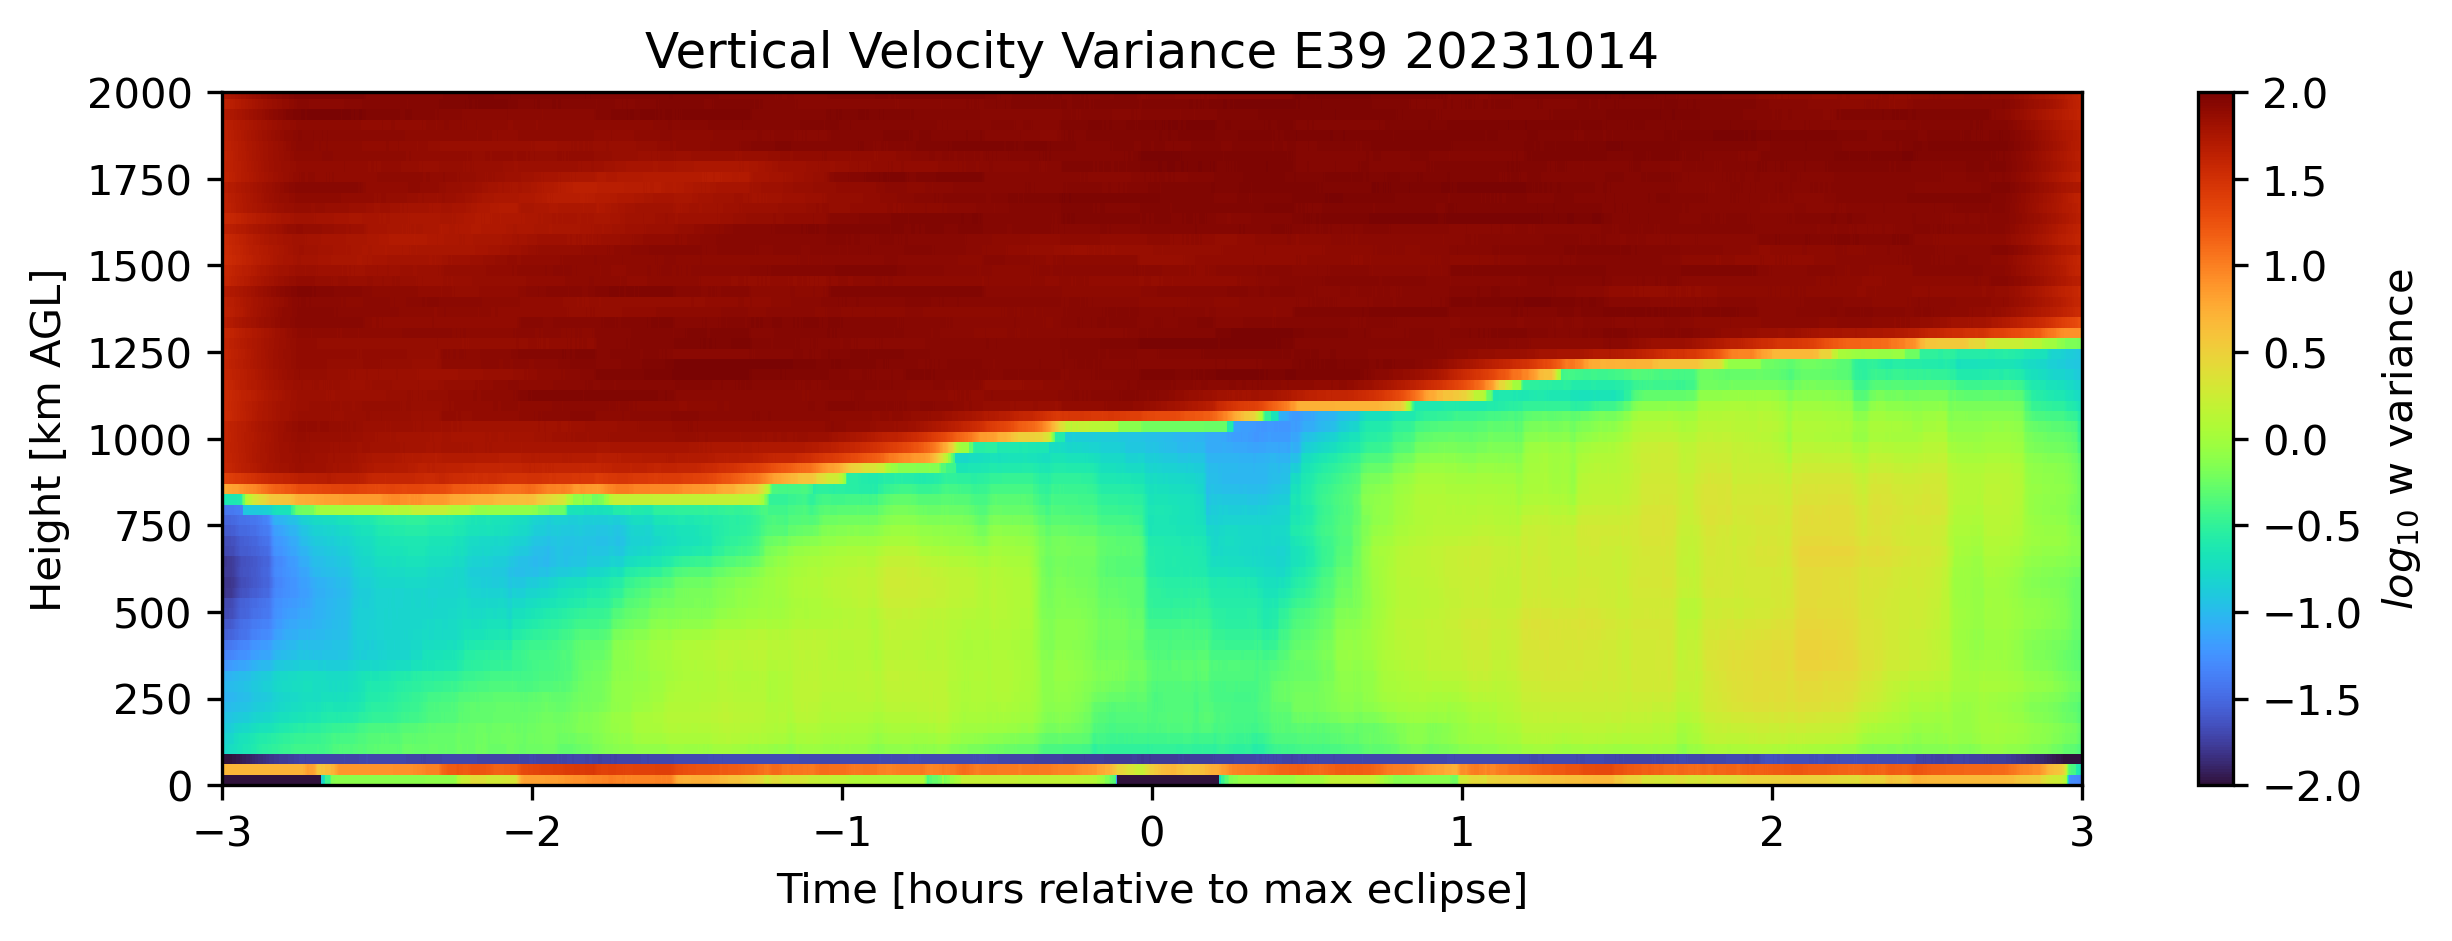

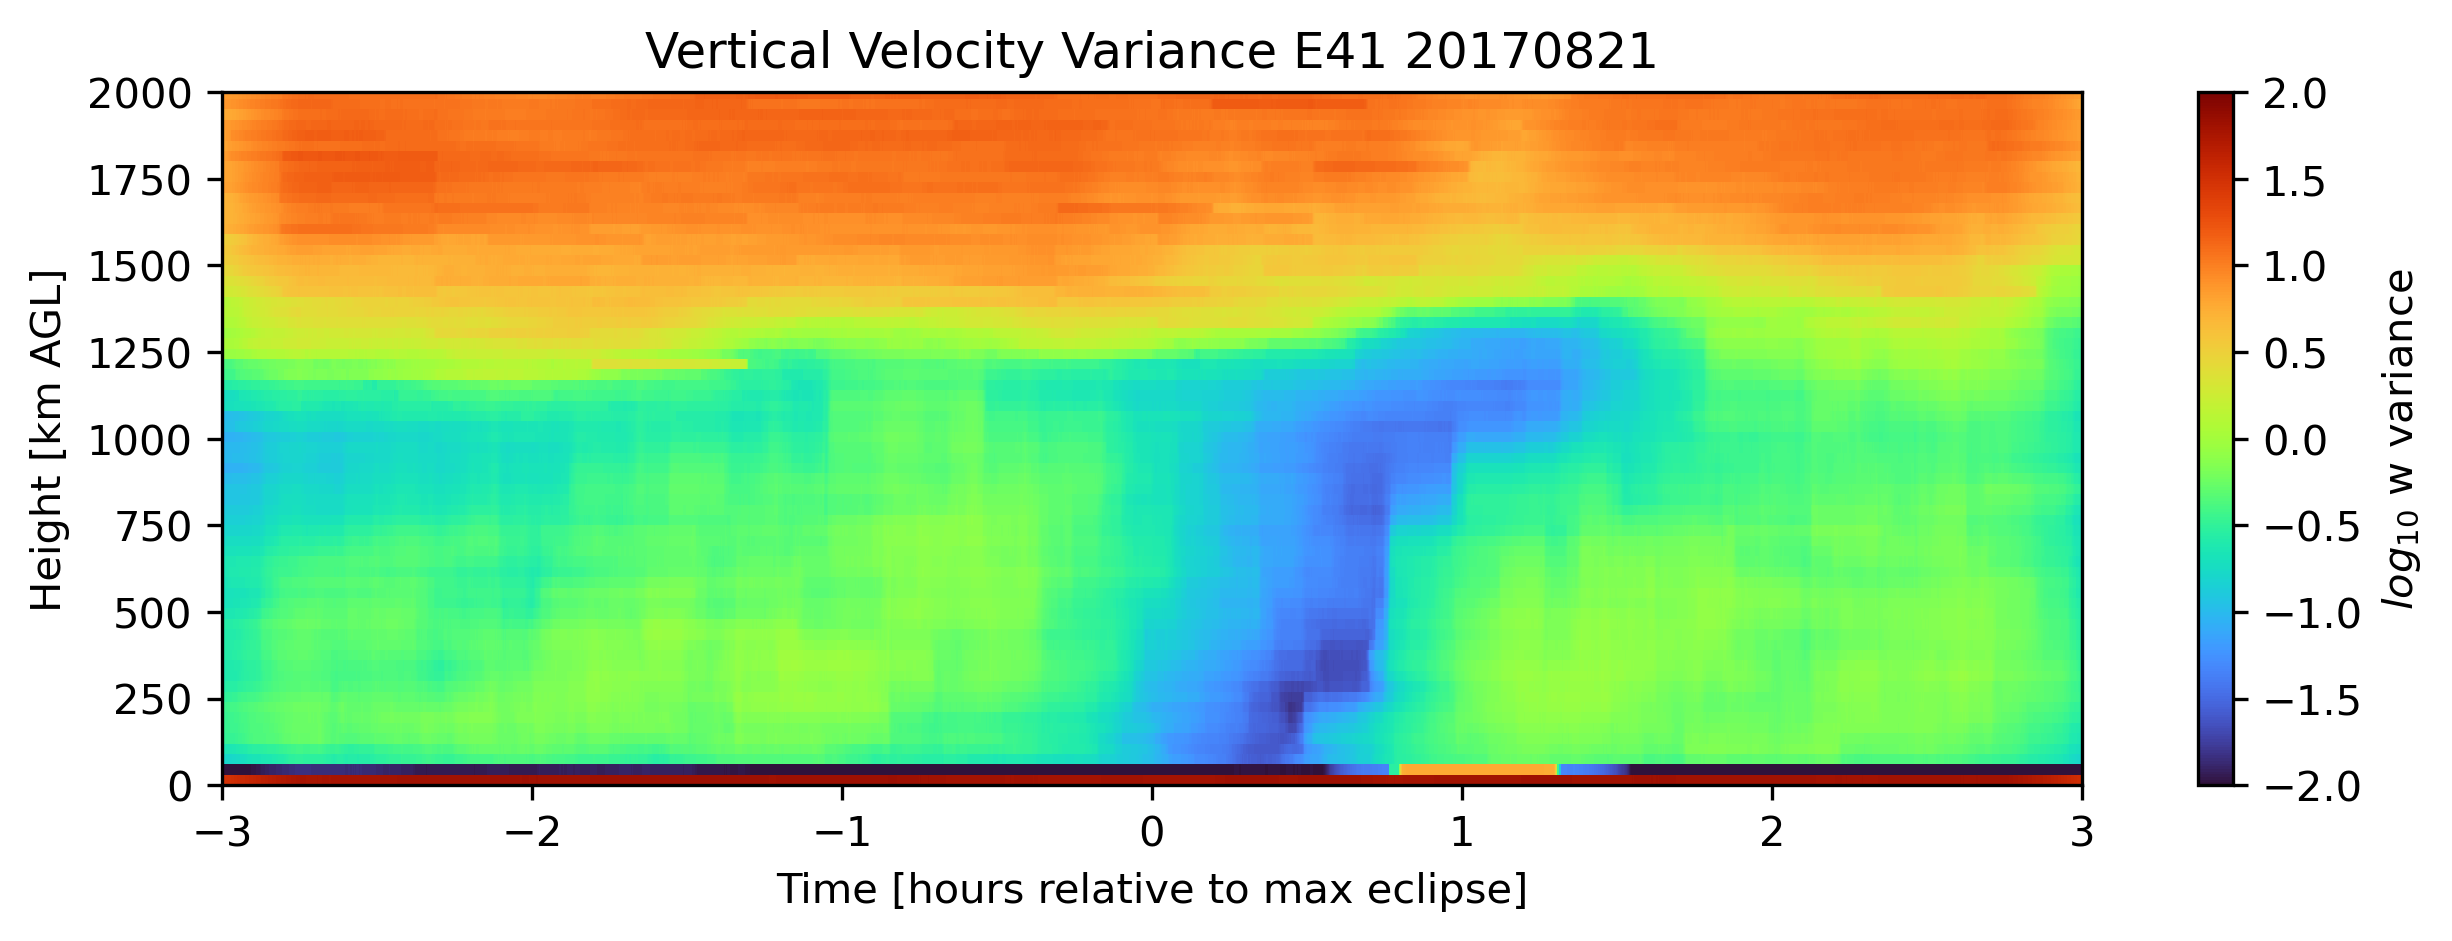

In [6]:
ctr = 0

for g in np.arange(len(eclipseSites)):


    for h in np.arange(len(eclipseDates)):
        
        

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
            
            dl.time = dl.time - eclipseTimes[h]

        except:
            
            ctr=ctr+1
            continue
        
        interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

        wNew = interpFunc(timeNew, heightNew)


        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)

        for i in range(totalStartIdx, totalEndIdx):
    
       
            meanW = np.mean(wNew[i-900:i+900,:],axis=0)
            wPrime[i,:] = wNew[i,:]-meanW

        for i in range(totalStartIdx, totalEndIdx):

            wVar[i,:,ctr] = np.var(wPrime[i-900:i+900,:],axis=0)


        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        cbar = plt.colorbar()
        cbar.set_label('$log_{10}$ w variance')
        plt.title('Vertical Velocity Variance ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        plt.xlabel('Time [hours relative to max eclipse]')
        plt.ylabel('Height [km AGL]')
        plt.show()

        saveDate[ctr] = eclipseDates[h]
        ctr = ctr+1


Let's make some collective figures now shoeing mean behavior across the various sites for a single event.

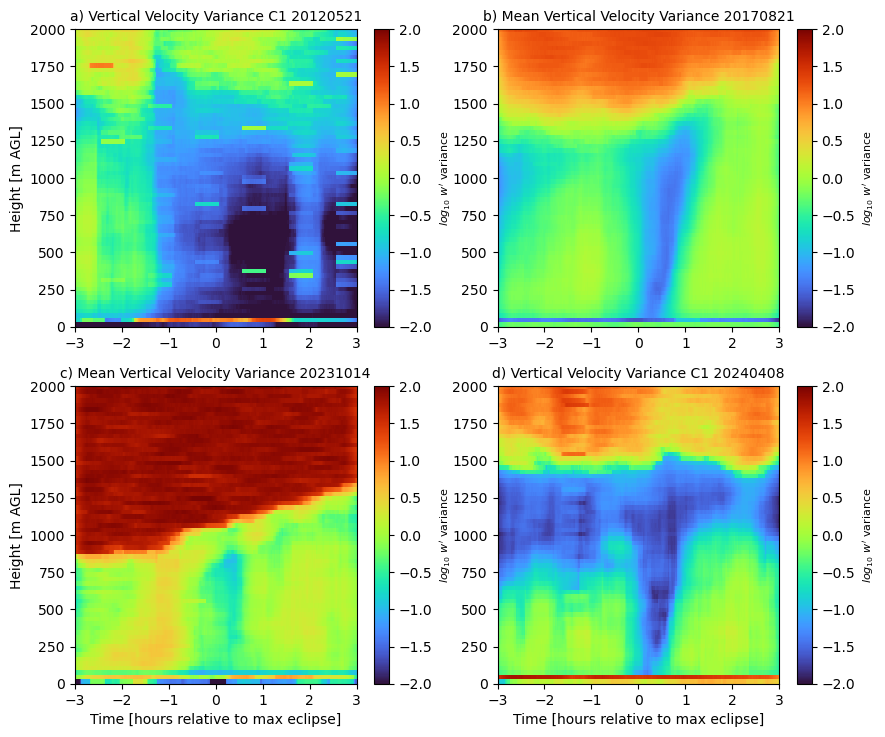

In [7]:
# idx = np.where(saveDate ==20170821)[0]

# meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

# plt.figure(figsize=(10, 3), dpi=300)
# plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
# cbar = plt.colorbar()
# cbar.set_label('$log_{10}$ $w\'$ variance')
# plt.title('Mean Vertical Velocity Variance 2017')
# plt.clim([-2, 2])
# plt.ylim([0,2000])
# plt.xlim([-3,3])
# plt.xlabel('Time [hours relative to max eclipse]')
# plt.ylabel('Height [m AGL]')
# plt.show()



# idx = np.where(saveDate ==20231014)[0]

# meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

# plt.figure(figsize=(10, 3), dpi=300)
# plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
# cbar = plt.colorbar()
# cbar.set_label('$log_{10}$ $w\'$ variance')
# plt.title('Mean Vertical Velocity Variance 2023')
# plt.clim([-2, 2])
# plt.ylim([0,2000])
# plt.xlim([-3,3])
# plt.xlabel('Time [hours relative to max eclipse]')
# plt.ylabel('Height [m AGL]')
# plt.show()


# idx = np.where(saveDate > 2000)[0]

# meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

# plt.figure(figsize=(10, 3), dpi=300)
# plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
# cbar = plt.colorbar()
# cbar.set_label('$log_{10}$ $w\'$ variance')
# plt.title('Mean Vertical Velocity Variance All Eclipses')
# plt.clim([-2, 2])
# plt.ylim([0,2000])
# plt.xlim([-3,3])
# plt.xlabel('Time [hours relative to max eclipse]')
# plt.ylabel('Height [m AGL]')
# plt.show()




fig, axs = plt.subplots(2,2, figsize=(10, 8.5))

idx = np.where(saveDate ==20120521)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,1)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')

plt.title('a) Vertical Velocity Variance C1 20120521',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.ylabel('Height [m AGL]')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)



idx = np.where(saveDate ==20170821)[0]
meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)
plt.subplot(2,2,2)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
plt.title('b) Mean Vertical Velocity Variance 20170821',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)


idx = np.where(saveDate ==20231014)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,3)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
plt.title('c) Mean Vertical Velocity Variance 20231014',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)


idx = np.where(saveDate ==20240408)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,4)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo',rasterized=True)

plt.title('d) Vertical Velocity Variance C1 20240408',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')

cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)


plt.savefig('four_panel_sgp_variances.png')
plt.show()

In [8]:
print(saveDate[0:10])

[20120521. 20170821. 20231014. 20240408.        0. 20170821.        0.
        0.        0. 20170821.]


### PBL-normalized height grid

Now, do what we've done before, but this time do it with the grid normalized to the pbl heights using Julia's code.

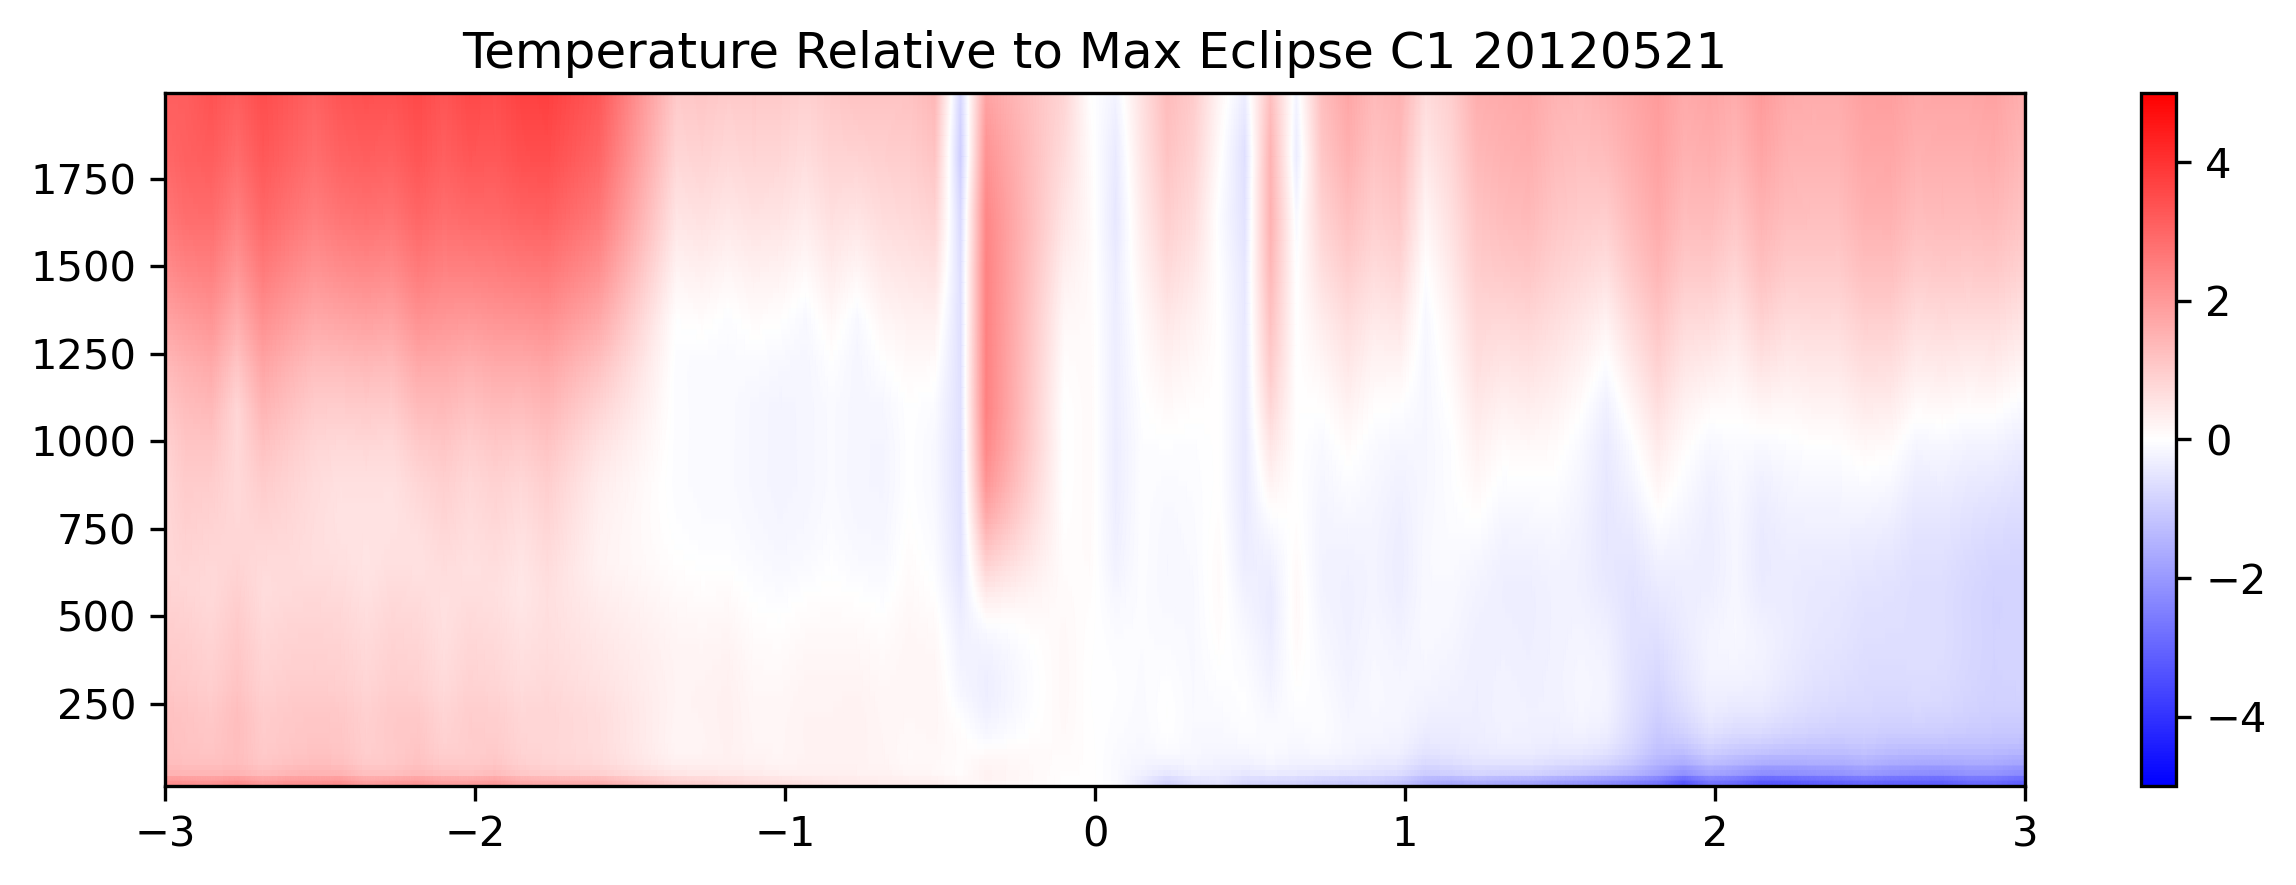

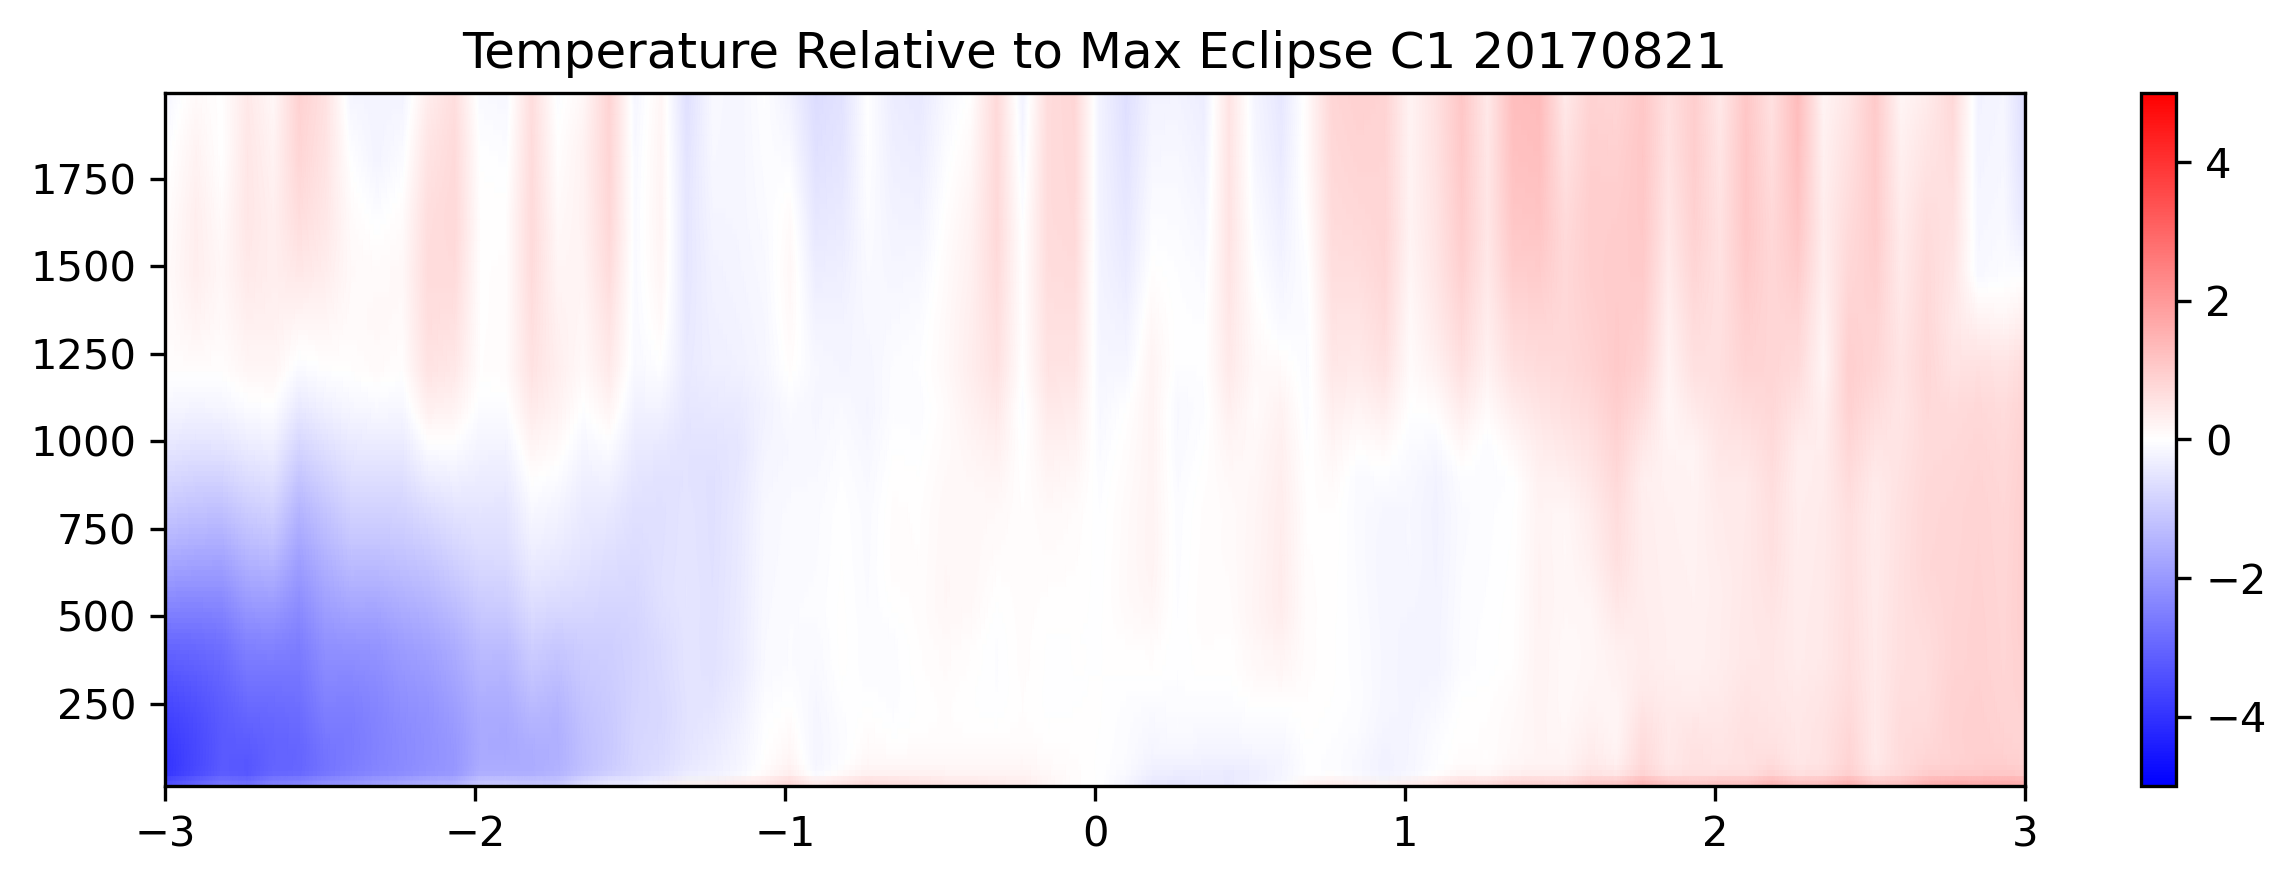

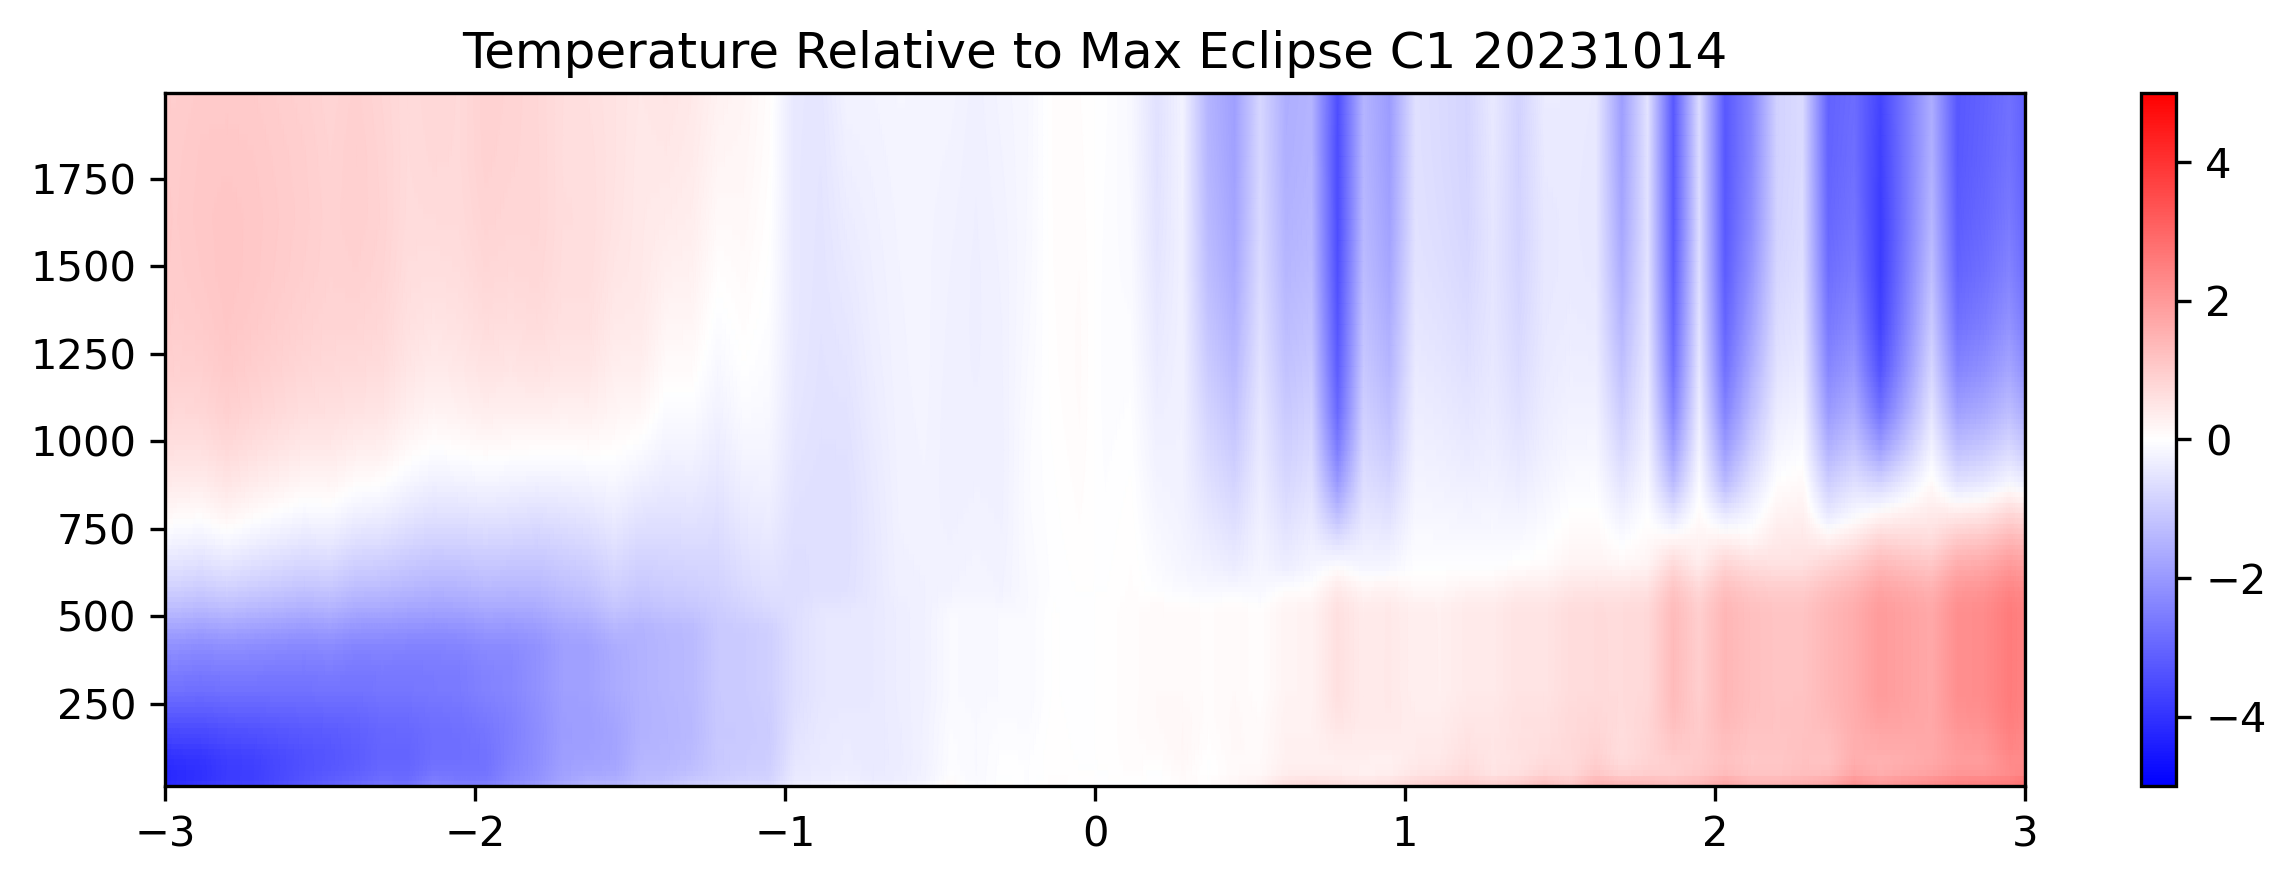

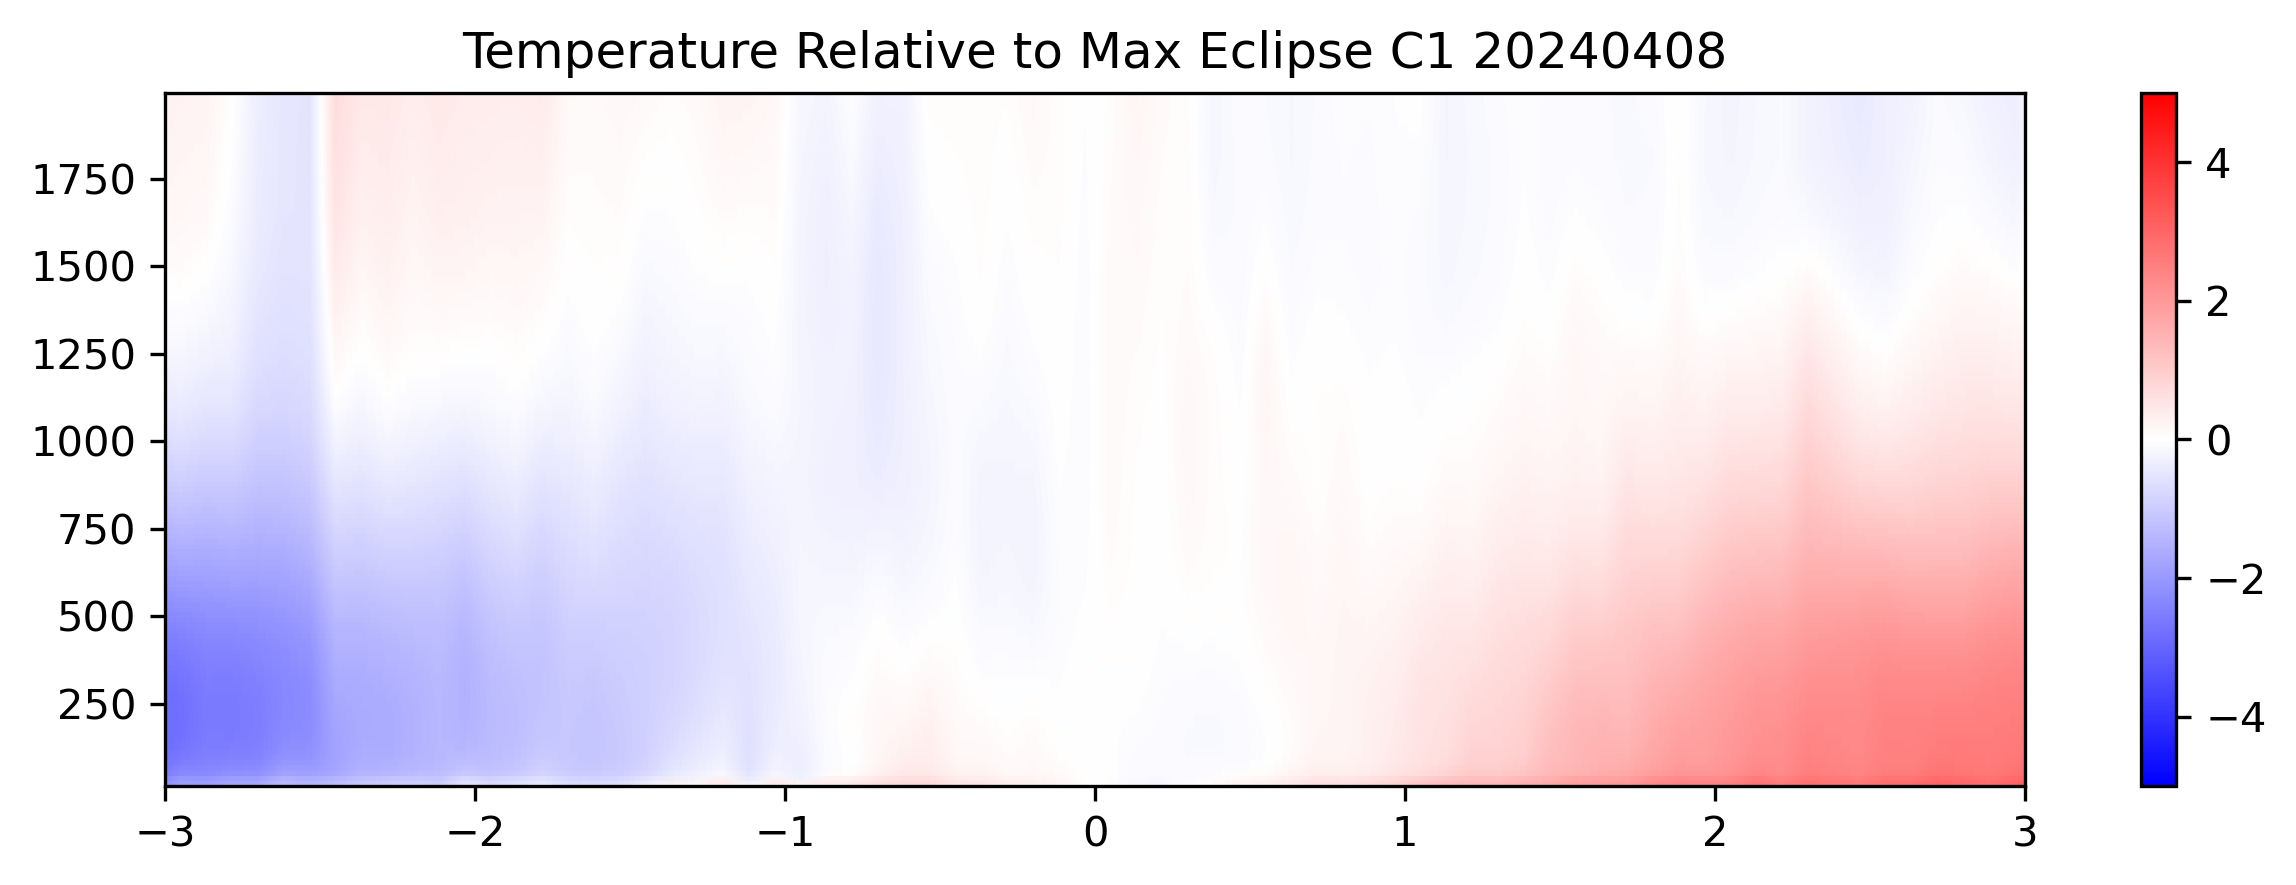

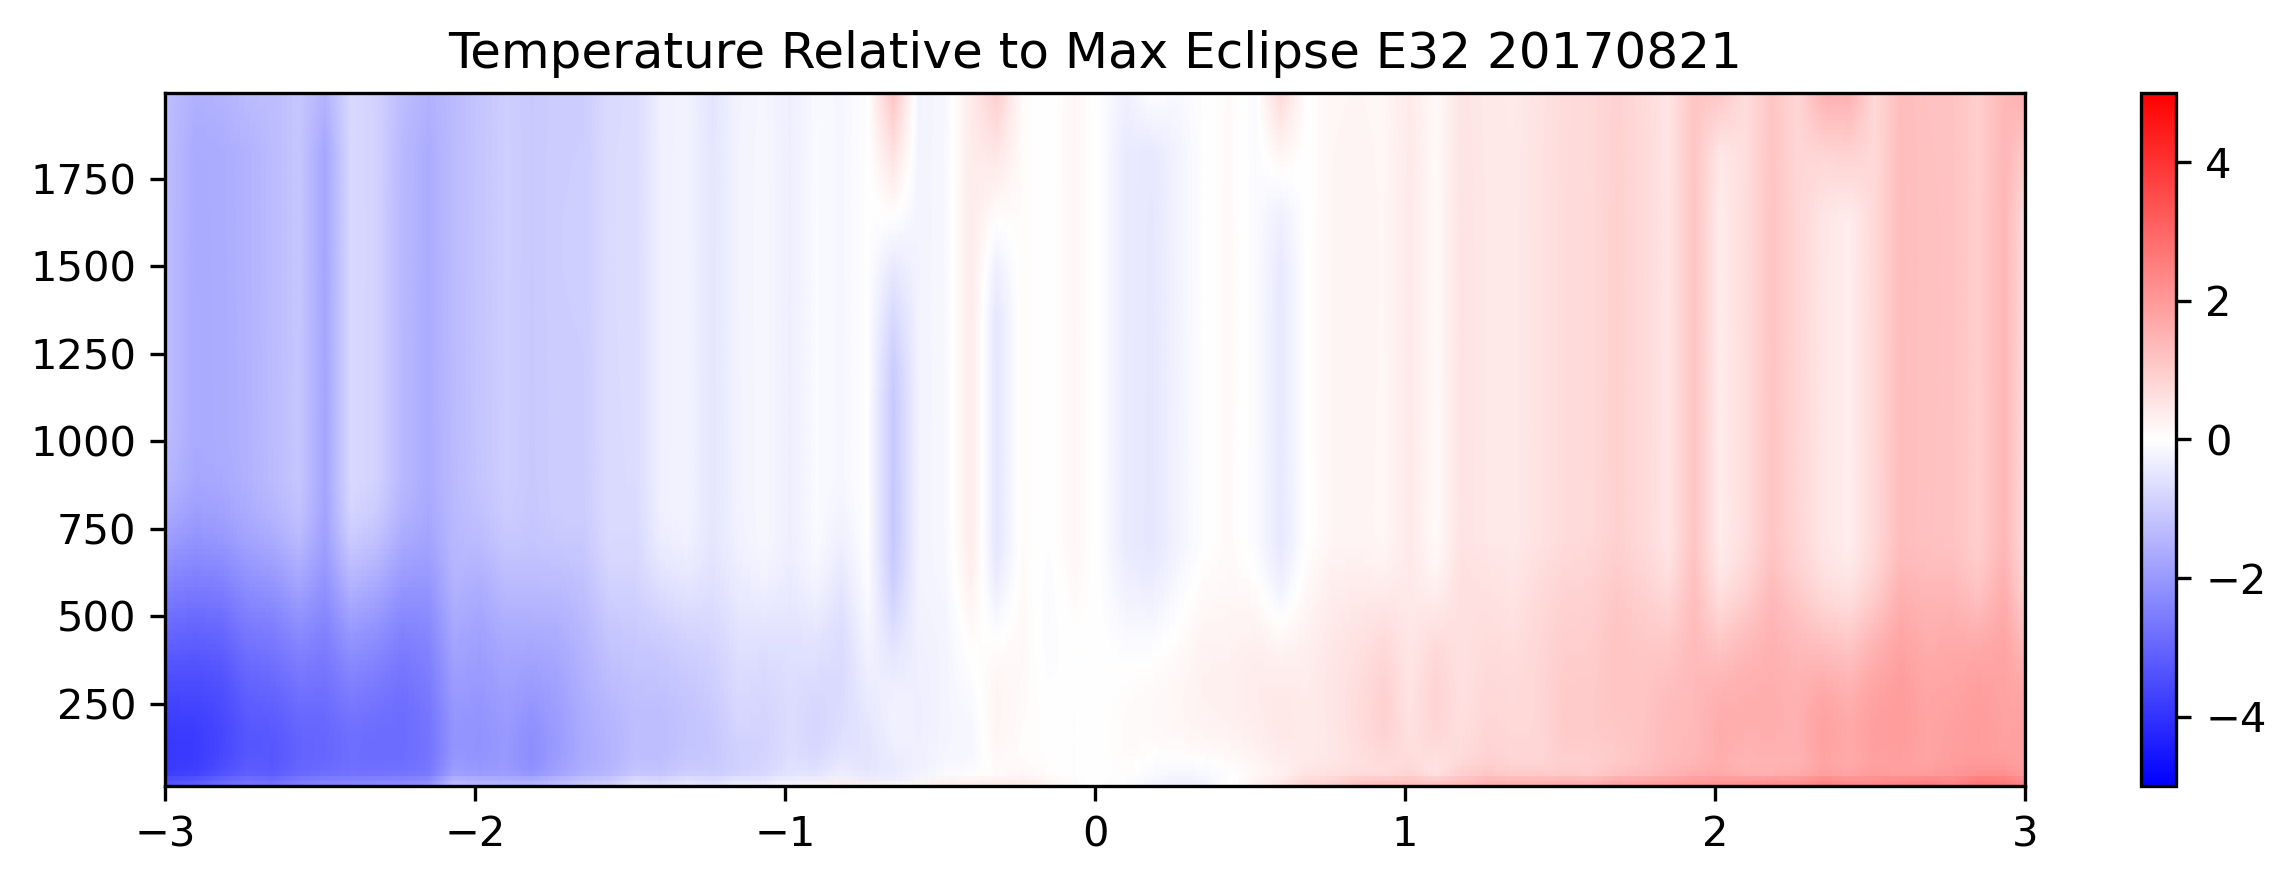

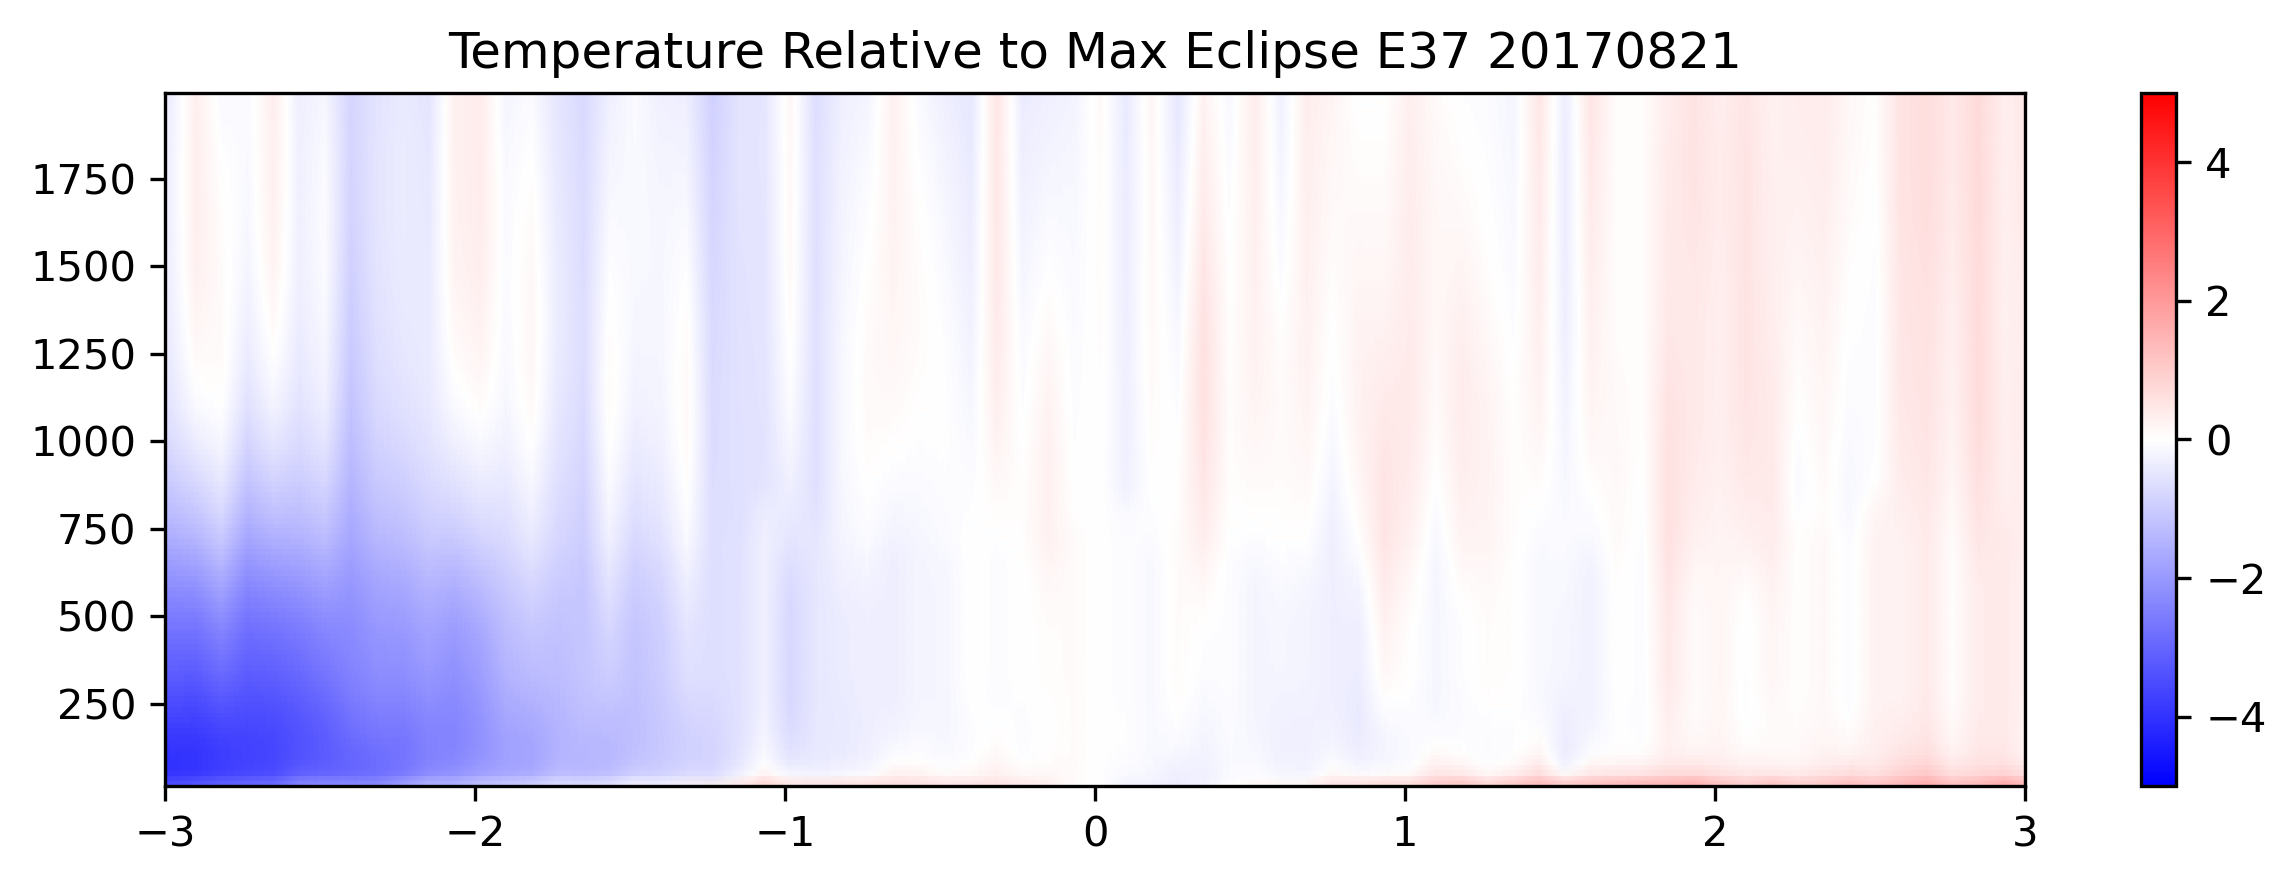

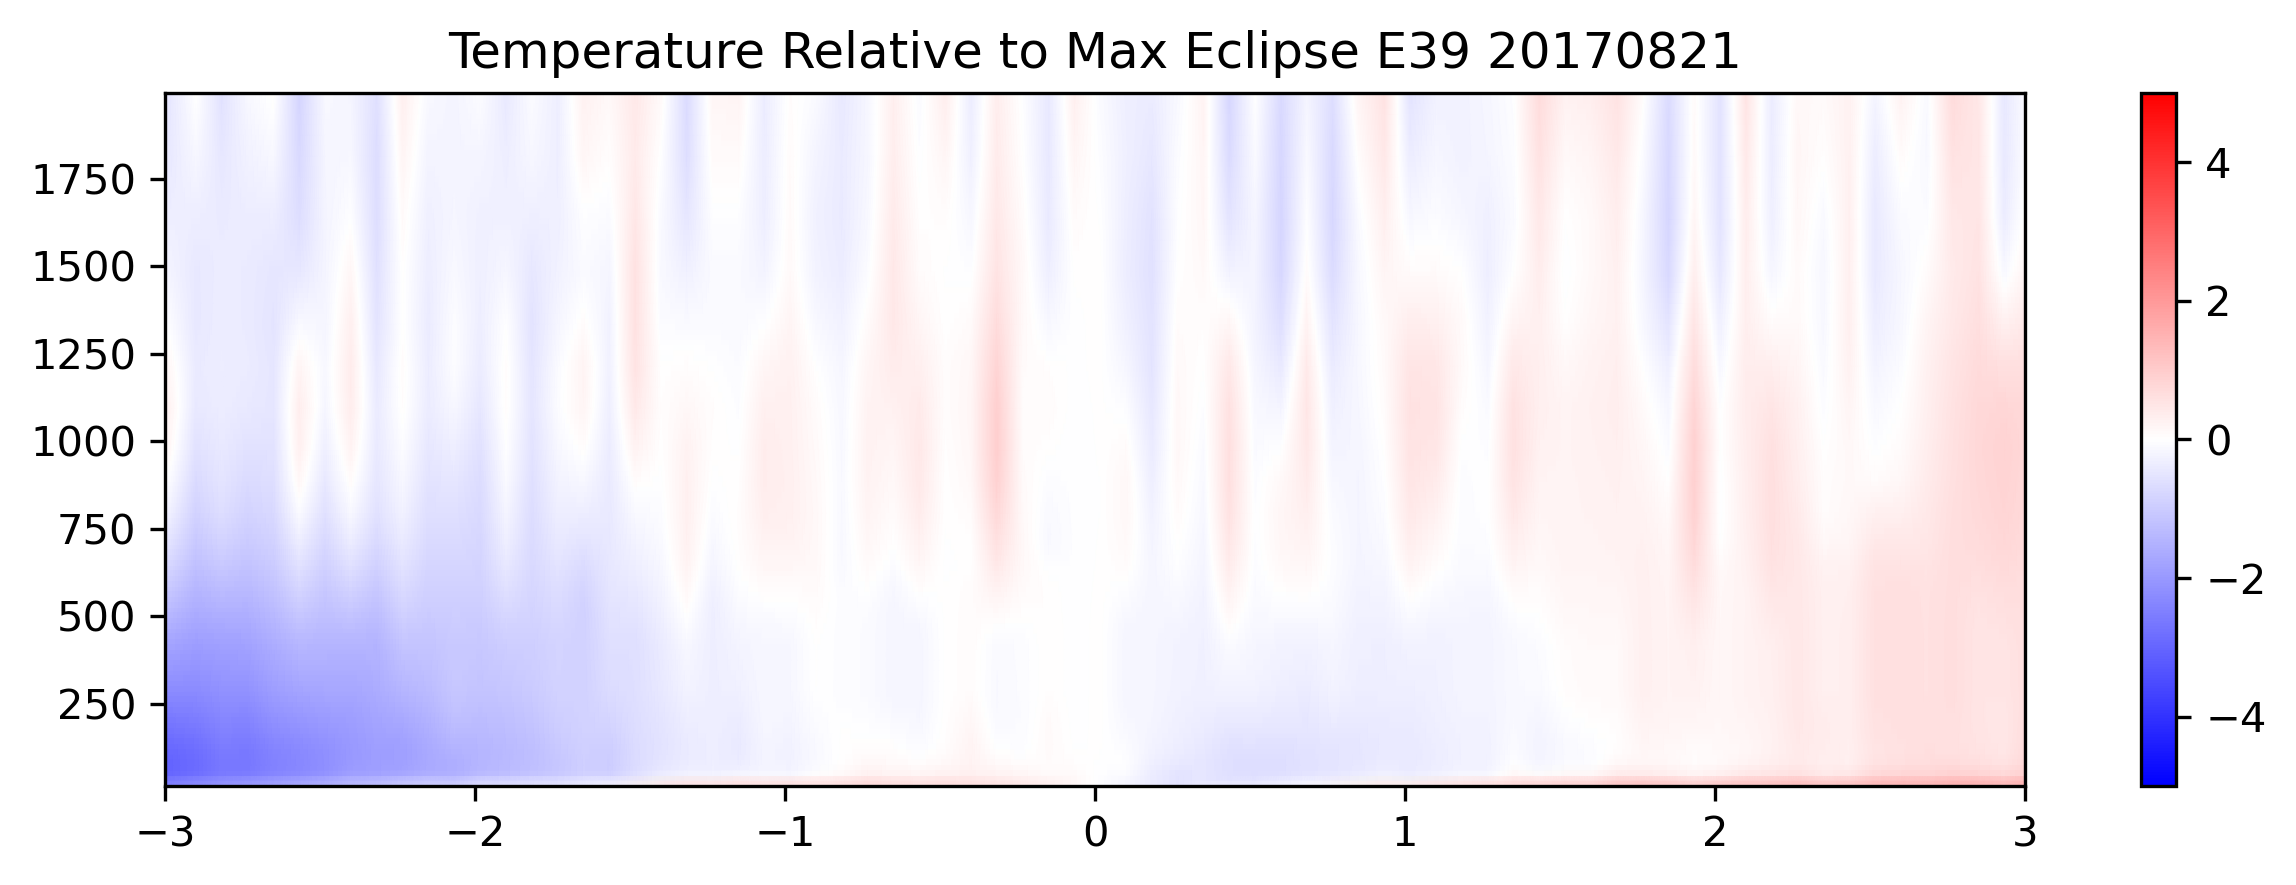

In [9]:
eclipseFacilities = sgpEclipseFacilities
eclipseSites = sgpEclipseSites
eclipseDates = sgpEclipseDates
eclipseTimes = sgpEclipseTimes
eclipseMags = sgpEclipseMags


deltaT = np.zeros((len(timeNew), len(heightNew), len(eclipseSites)*len(eclipseDates)))-9999
pblz = np.zeros((len(timeNew), len(eclipseSites)*len(eclipseDates)))-9999
pblzidx = np.zeros(len(eclipseSites)*len(eclipseDates))-9999

ctr = 0

for g in np.arange(len(eclipseSites)):

    for h in np.arange(len(eclipseDates)):

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
            aeri = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
                aeri0 = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
                
                aeri.time = np.concatenate((aeri0.time-24, aeri.time))
                aeri.temp= np.concatenate((aeri0.temp, aeri.temp))
                aeri.wv= np.concatenate((aeri0.wv, aeri.wv))
                aeri.theta= np.concatenate((aeri0.theta, aeri.theta))
                aeri.sigma_t= np.concatenate((aeri0.sigma_t, aeri.sigma_t))
                
            
            
            dl.time = dl.time - eclipseTimes[h]
            aeri.time = aeri.time - eclipseTimes[h]

            #pblh_cbl(time,height,theta_prof,sigma):
  
            pbli = pblh_cbl(aeri.time, aeri.height/1000, aeri.theta, aeri.sigma_t)
            
            interpPbl = interp.interp1d(aeri.time, pbli)
            pblz[:,ctr] = interpPbl(timeNew)*1000
            pblzidx[ctr]=h
               
        except Exception as e: 

            ctr = ctr+1
            continue
         
        interpFunc = interp.RectBivariateSpline(aeri.time, aeri.height[0:53], aeri.temp[:,0:53],kx=1, ky=1)
        tempNew = interpFunc(timeNew, heightNew)
        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)
        
        # plt.figure(figsize=(10, 3), dpi=300)
        # plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew),cmap = 'turbo', shading = 'gouraud')
        # cbar = plt.colorbar()
        # plt.clim(5,30) 
        # plt.xlim(-3,3)
        # plt.show()
        
 
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)

        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew-meanTprof),cmap = 'bwr', shading = 'gouraud')
        cbar = plt.colorbar()
        plt.clim(-5,5)
        plt.xlim(-3,3)
        plt.title('Temperature Relative to Max Eclipse ' + eclipseSites[g] + ' ' + str(eclipseDates[h]))
        plt.show()
        
        deltaT[:,:,ctr] = (tempNew-meanTprof)
        ctr = ctr+1
        
        
deltaT[np.where(deltaT==-9999)]=np.nan
pblz[np.where(pblz==-9999)]=np.nan

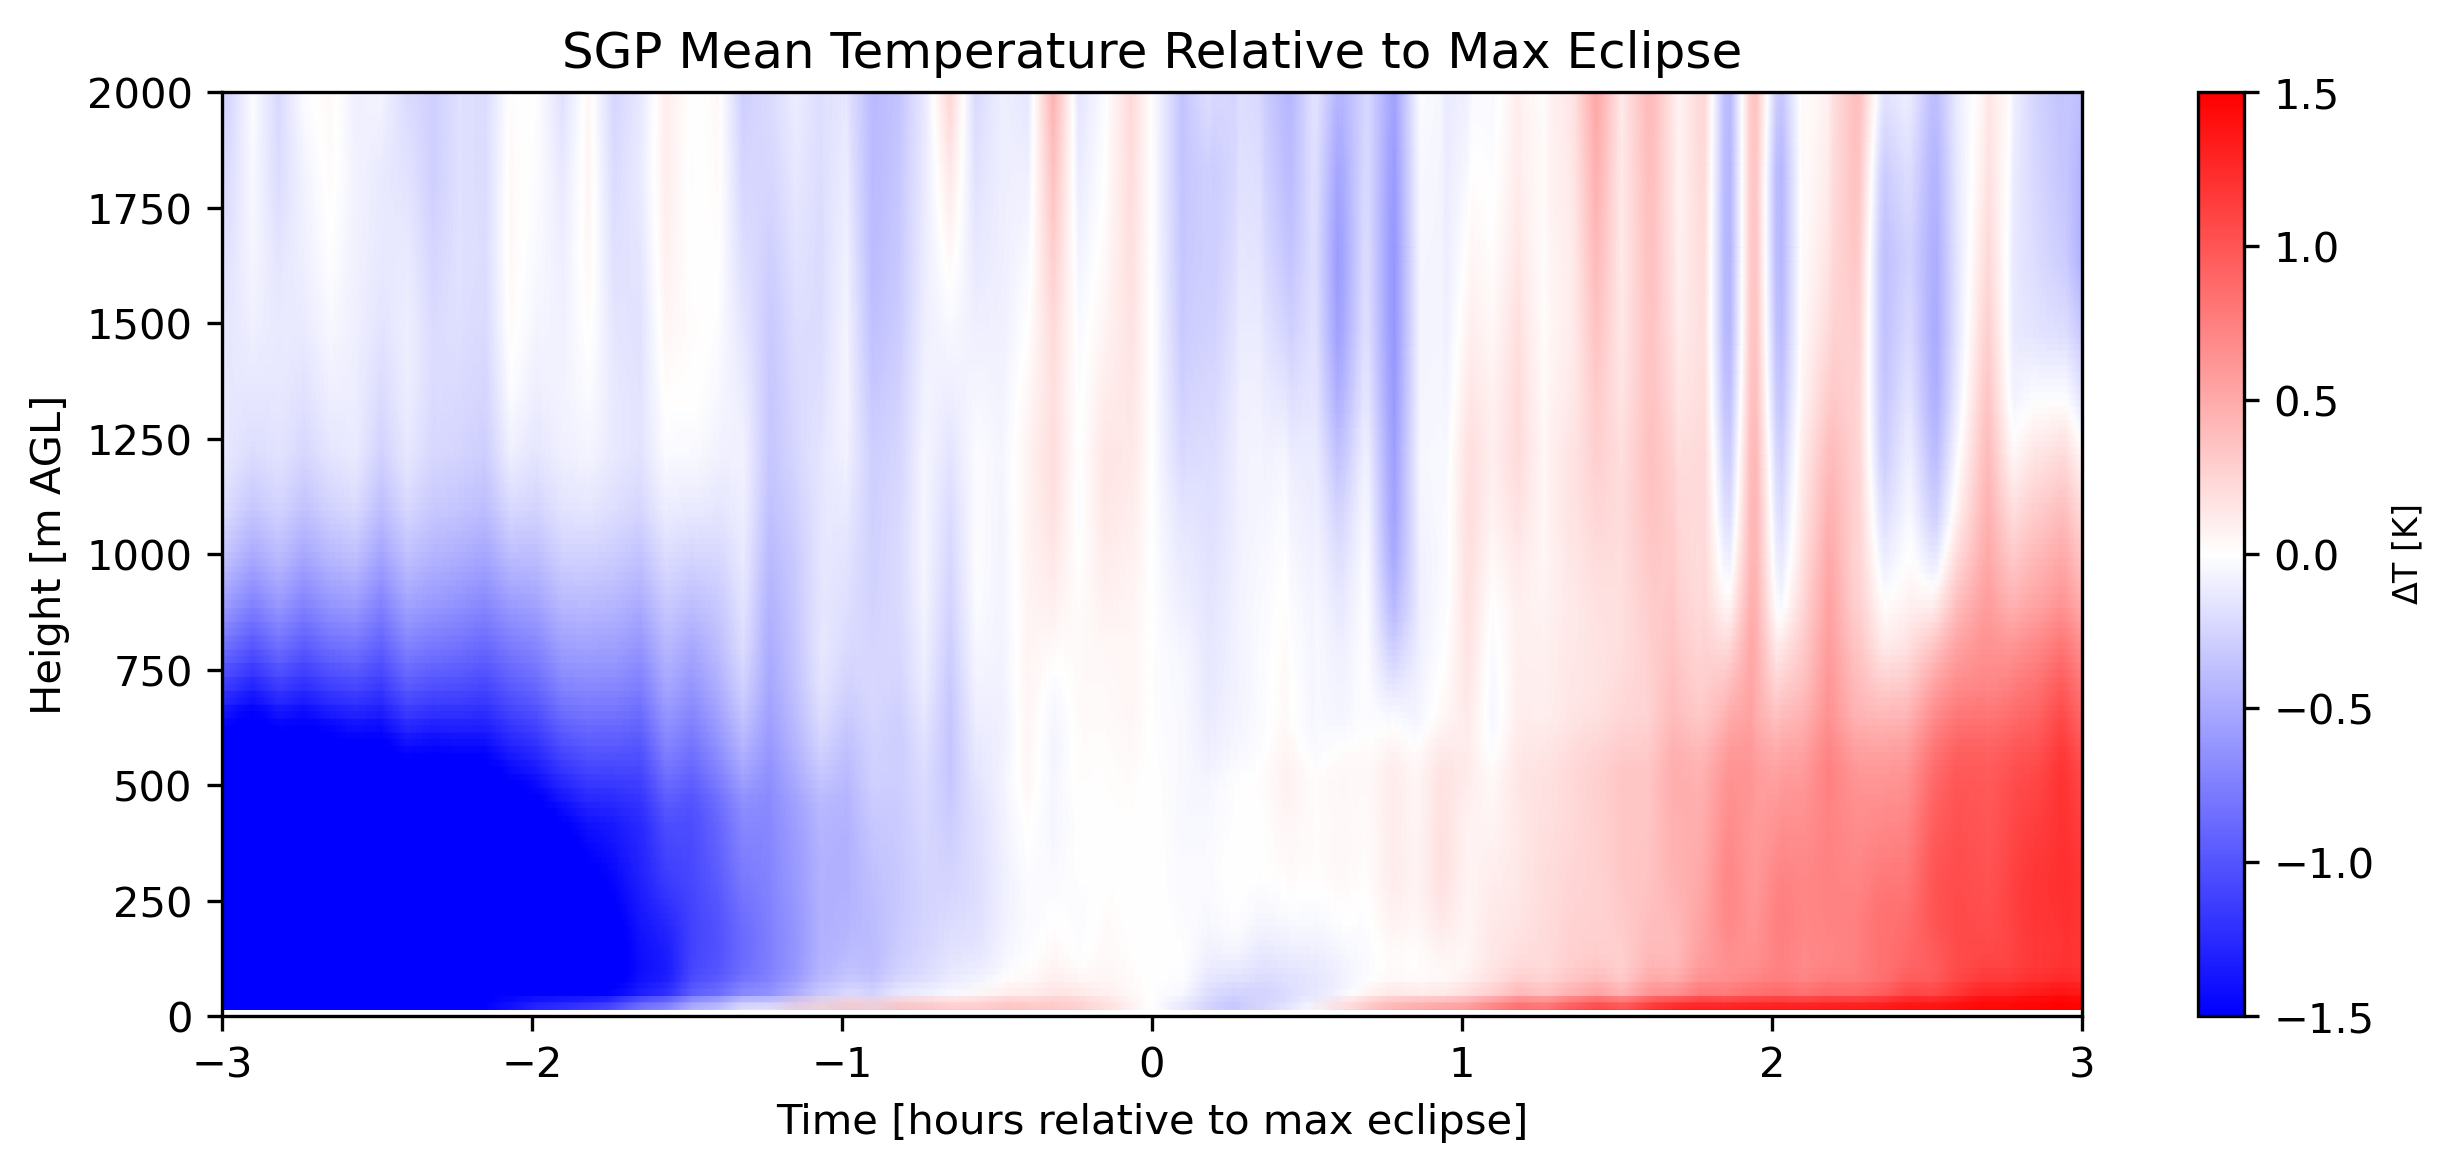

In [10]:
plt.figure(figsize=(10, 4), dpi=300)
ix2 = np.where((pblzidx == 1) | (pblzidx == 2))
plt.pcolormesh(timeNew, heightNew, np.transpose(np.nanmean(deltaT[:,:,ix2[0]],2)),cmap = 'bwr', shading = 'gouraud')
cbar = plt.colorbar()
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.title('SGP Mean Temperature Relative to Max Eclipse')
plt.ylim(0,2000.01)
cbar.set_label('$\Delta$T [K]',fontsize=8)

plt.savefig('delta_t_aeri_eclipse.png')
plt.show()





In [11]:
print(pblz)



[[1271.20697321  360.06330022   46.54758754 ...           nan
            nan           nan]
 [1271.57785524  360.2001809    46.54119748 ...           nan
            nan           nan]
 [1271.94873727  360.33706158   46.53480742 ...           nan
            nan           nan]
 ...
 [  10.62590927 1571.19962612 1092.73631864 ...           nan
            nan           nan]
 [  10.62334931 1573.06448424 1092.62024302 ...           nan
            nan           nan]
 [  10.62078935 1574.92934236 1092.5041674  ...           nan
            nan           nan]]


In [12]:
print(pblz)

[[1271.20697321  360.06330022   46.54758754 ...           nan
            nan           nan]
 [1271.57785524  360.2001809    46.54119748 ...           nan
            nan           nan]
 [1271.94873727  360.33706158   46.53480742 ...           nan
            nan           nan]
 ...
 [  10.62590927 1571.19962612 1092.73631864 ...           nan
            nan           nan]
 [  10.62334931 1573.06448424 1092.62024302 ...           nan
            nan           nan]
 [  10.62078935 1574.92934236 1092.5041674  ...           nan
            nan           nan]]


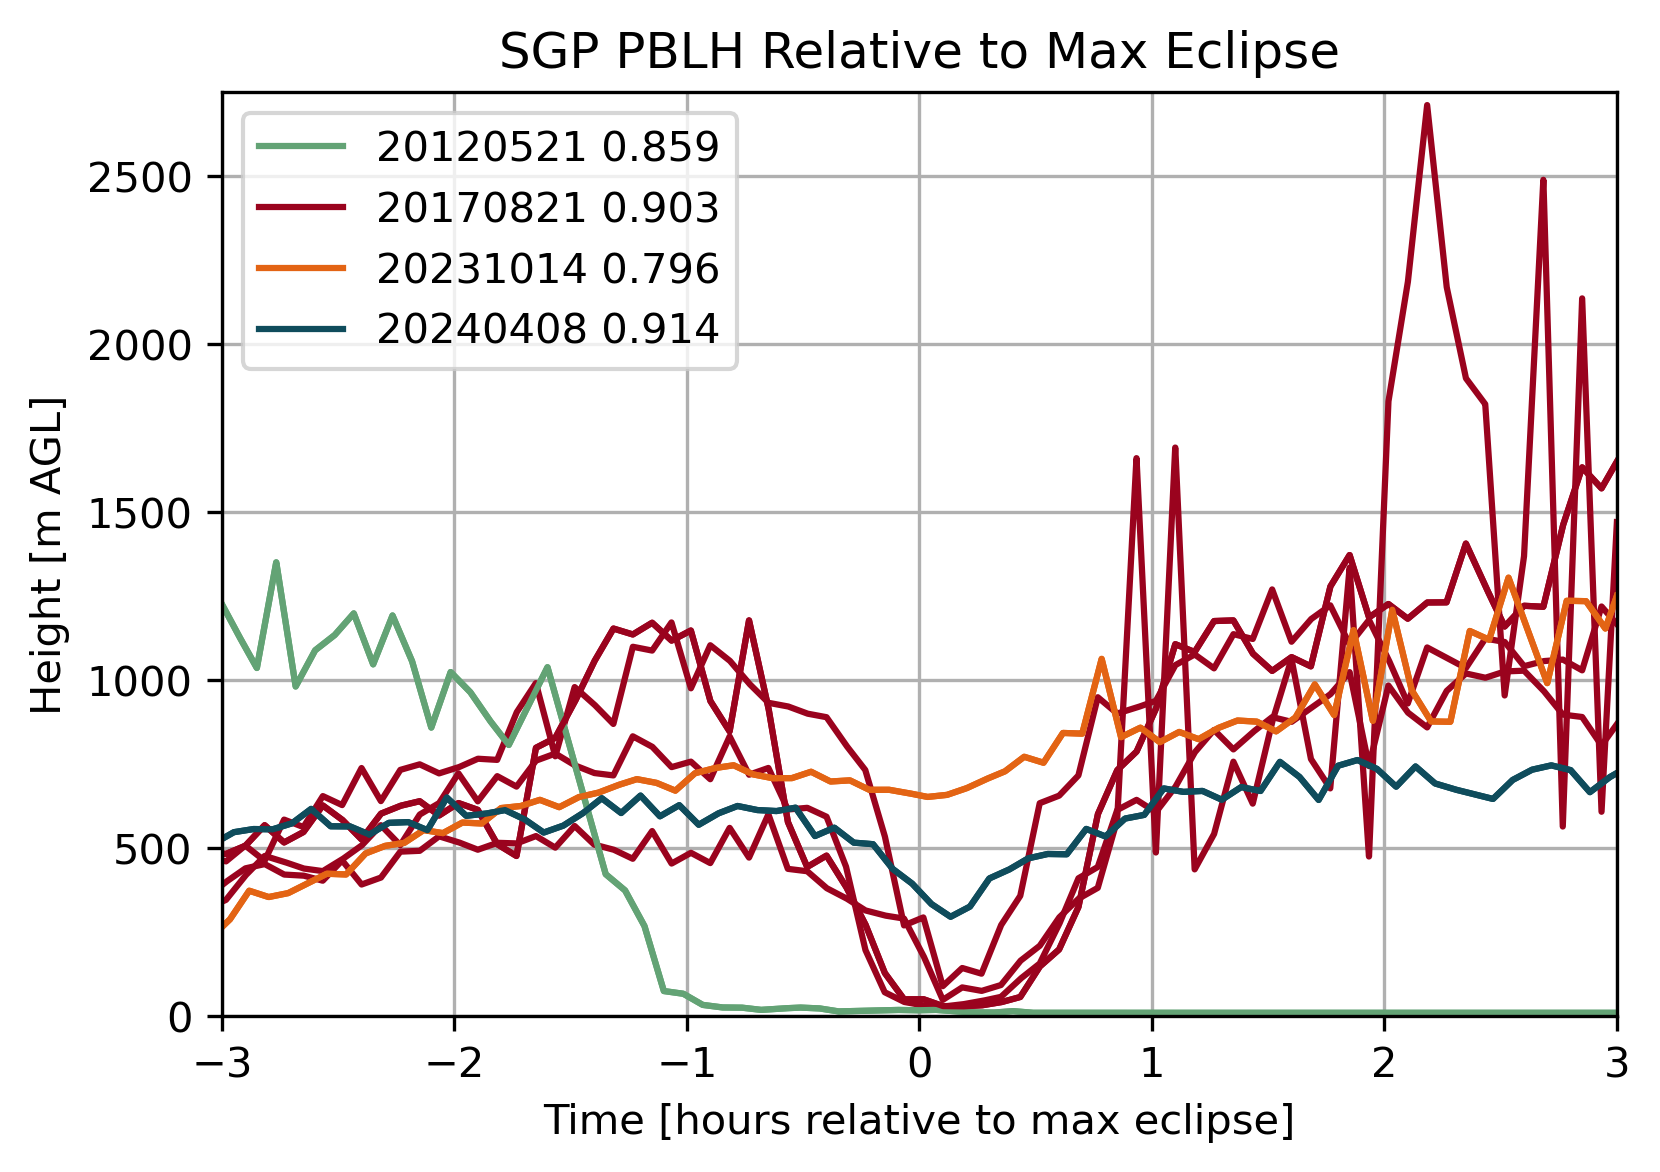

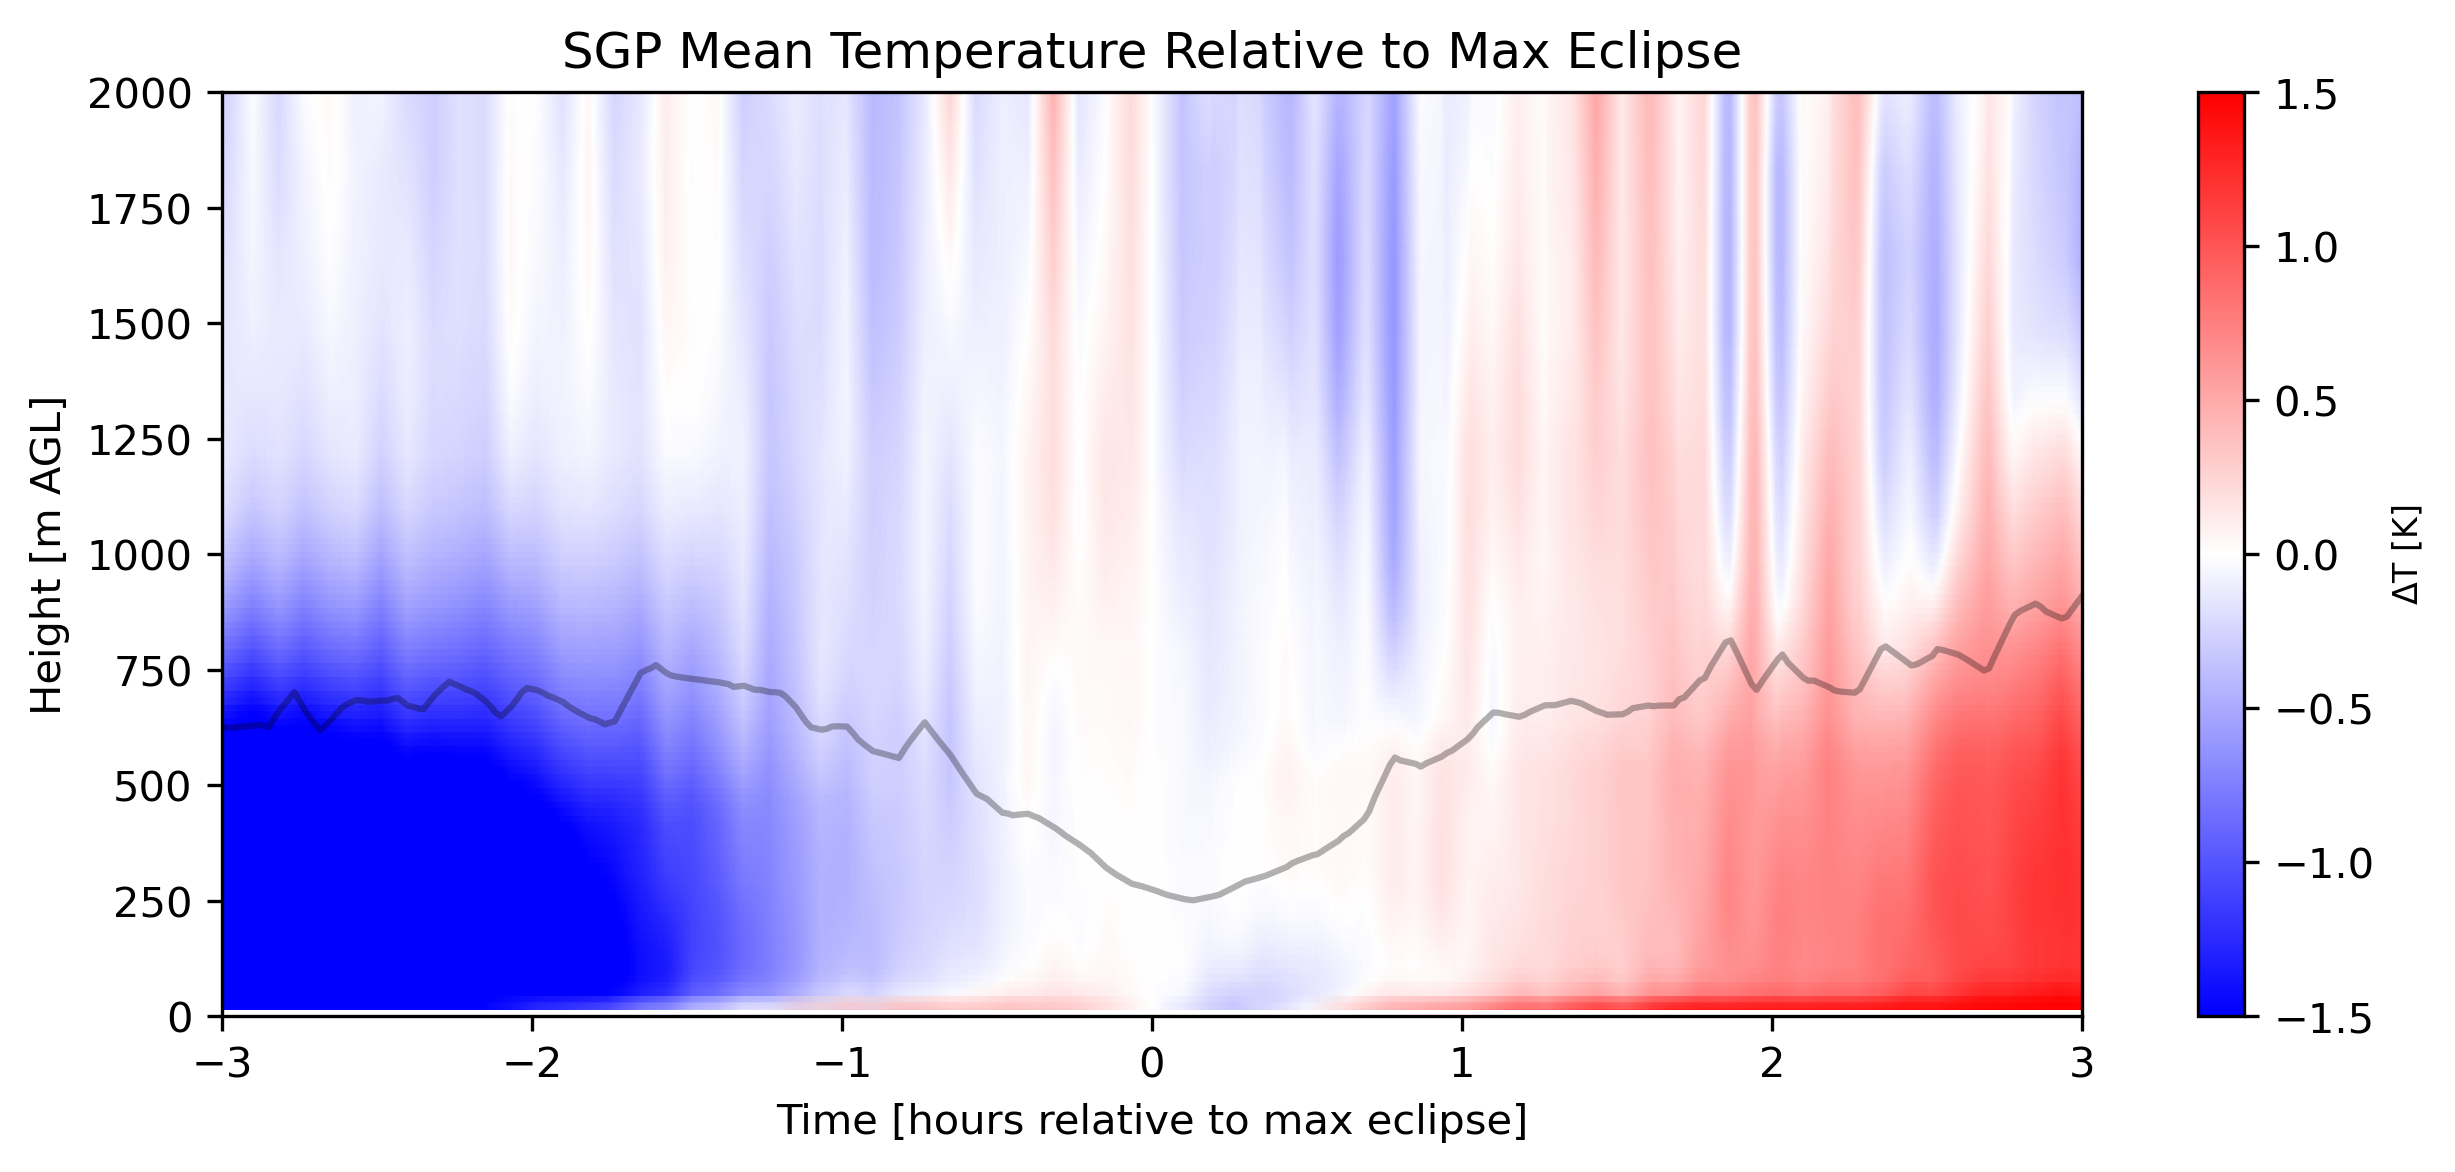

In [19]:
cols = np.array([[99, 163, 117],
        [154,3,30],
        [227,100,20],
        [15,76,92]])/255




plt.figure(figsize=(6, 4), dpi=300)

lab1=[]
z1=[]
h = []



for i in np.arange(0,len(eclipseDates)):



    ix = np.where(pblzidx == i)[0]
    ix2 = ix[0]
    
    lab1.append(str(eclipseDates[ix2]) + ' ' + str(eclipseMags[ix2]))
    
    plt.plot(timeNew, np.squeeze(pblz[:,ix]),color=cols[i,:],alpha=1.0)
    z1.append(np.squeeze(pblz[:,ix2]))

    

for i in np.arange(0,len(eclipseDates)):    
    plt.plot(timeNew, z1[i],label = lab1[i],color = cols[i,:])    
    
plt.legend()

plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')

plt.grid()
plt.xlim(-3,3)
plt.ylim(0,2750)
plt.title('SGP PBLH Relative to Max Eclipse')
plt.savefig('time_series_of_pblh_from_sgp.png')



  






plt.figure(figsize=(10, 4), dpi=300)
ix2 = np.where((pblzidx == 1) | (pblzidx == 2))
plt.pcolormesh(timeNew, heightNew, np.transpose(np.nanmean(deltaT[:,:,ix2[0]],2)),cmap = 'bwr', shading = 'gouraud')
plt.plot(timeNew, np.nanmean(z1,0),color='black',alpha=0.3) 
cbar = plt.colorbar()
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.title('SGP Mean Temperature Relative to Max Eclipse')
plt.ylim(0,2000.01)
cbar.set_label('$\Delta$T [K]',fontsize=8)

plt.savefig('delta_t_aeri_eclipse.png')
plt.show()

In [ ]:
# here, we plot that PBL height data over the top of the four panel plot from earlier.

fig, axs = plt.subplots(2,2, figsize=(10, 8.5))

idx = np.where(saveDate ==20120521)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,1)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')

plt.title('a) Vertical Velocity Variance C1 20120521',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.ylabel('Height [m AGL]')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)
plt.plot(timeNew, np.squeeze(pblz[:,0]),color='black',alpha=1.0)


idx = np.where(saveDate ==20170821)[0]
meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)
plt.subplot(2,2,2)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
plt.title('b) Mean Vertical Velocity Variance 20170821',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)
plt.plot(timeNew, np.nanmean(np.squeeze(pblz[:,[1,5,9,13]]),axis=1),color='black',alpha=1.0)

idx = np.where(saveDate ==20231014)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,3)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo')
plt.title('c) Mean Vertical Velocity Variance 20231014',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)
plt.plot(timeNew, np.squeeze(pblz[:,2]),color='black',alpha=1.0)

idx = np.where(saveDate ==20240408)[0]

meanWvar = np.mean(np.transpose(np.log10(wVar[:,:,idx])),axis=0)

plt.subplot(2,2,4)
plt.pcolormesh(timeNew, heightNew, meanWvar,cmap = 'turbo',rasterized=True)

plt.title('d) Vertical Velocity Variance C1 20240408',fontsize=10)
plt.clim([-2, 2])
plt.ylim([0,2000])
plt.xlim([-3,3])
plt.xlabel('Time [hours relative to max eclipse]')
plt.plot(timeNew, np.squeeze(pblz[:,3]),color='black',alpha=1.0)

cbar = plt.colorbar()
cbar.set_label('$log_{10}$ $w\'$ variance',fontsize=8)


plt.savefig('four_panel_sgp_variances.png')
plt.show()

In [ ]:
## SPARC plots

sparcFile = '/Users/timw/data/eclipse/tropoe/sparcaeriprofiles.c1.20240408.150239.nc'

aeri = readTROPoe(sparcFile)
aeri.time = aeri.time-19+9/60+0.5153  # Correct bad clock

aeri.temp[327,:]=np.nan


ix0 = findNearest(aeri.time, -5/60)
ix1 = findNearest(aeri.time, 0)
ix2 = findNearest(aeri.time, 5/60)

interpFunc = interp.RectBivariateSpline(aeri.time, aeri.height[0:53], aeri.temp[:,0:53],kx=1, ky=1)
tempNew = interpFunc(timeNew, heightNew)
totalStartIdx = findNearest(timeNew, -3)
totalEndIdx = findNearest(timeNew, 3)

meanTprof = np.mean(aeri.temp[ix0:ix2,:],0)


plt.figure(figsize=(10, 6),dpi=300)

plt.subplot(2,1,1)
plt.pcolormesh(aeri.time, aeri.height, np.transpose(aeri.temp-meanTprof),cmap = 'bwr', shading = 'gouraud')

cbar = plt.colorbar()
cbar.set_label('$\Delta$T [K]',fontsize=8)
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.ylabel('Height [m AGL]')
plt.title('a) SPARC Indiana Temperature Relative to Max Eclipse')
plt.ylim(0,2000.1)



sparcCbl=pblh_cbl(aeri.time,aeri.height/1000,aeri.theta,aeri.sigma_t)*1000
sparcCbl[327]=np.nan

plt.plot(aeri.time, sparcCbl,color='black',alpha=0.3)

# plt.show()


### Load up sparc DLID

sparcDLfile = '/Users/timw/data/eclipse/eclipse_doppler_lidar_stare_20240408.cdf'

ds = netCDF4.Dataset(sparcDLfile)

class dl:
    time = ds['times'][:]
    height = ds['height'][:]
    w = ds['w'][:]
    
dl.time = dl.time - 19+9/60 - 0.5153

dl.height=dl.height[0:100]
dl.w = dl.w[:,0:100]

dl.w[8825,:]=np.nan

order = np.argsort(dl.time)
dl.time=dl.time[order]
dl.w = dl.w[order,:]

order = np.argsort(dl.height)
dl.height = dl.height[order]
dl.w = dl.w[:,order]



plt.subplot(2,1,2)
plt.pcolormesh(dl.time, dl.height, np.transpose(dl.w),cmap = 'bwr', shading = 'gouraud',rasterized=True)
plt.plot(aeri.time, sparcCbl,color='black',alpha=0.3)

cbar = plt.colorbar()
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.ylabel('Height [m AGL]')
plt.title('b) SPARC Vertical Velocity')
plt.ylim(0,2000.1)

cbar.set_label('w [m s$^{-1}$]',fontsize=8)

plt.xlabel('Time [hours relative to max eclipse]')



plt.tight_layout(pad=1.5)
plt.savefig('sparc_data.png')

plt.show()


# interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

# wNew = interpFunc(timeNew, heightNew)


# totalStartIdx = findNearest(timeNew, -3)
# totalEndIdx = findNearest(timeNew, 3)


# wPrime = np.zeros((len(timeNew), len(heightNew)))
# wVar = np.zeros((len(timeNew), len(heightNew)))


# for i in range(totalStartIdx, totalEndIdx):


#     meanW = np.mean(wNew[i-900:i+900,:],axis=0)
#     wPrime[i,:] = wNew[i,:]-meanW

# for i in range(totalStartIdx, totalEndIdx):

# wVar[i,:] = np.var(wPrime[i-900:i+900,:],axis=0)    

# plt.figure(figsize=(10, 6), dpi=300)
# plt.subplot(2,1,1)
# #plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
# plt.pcolormesh(timeNew, heightNew, np.transpose(wPrime),cmap = 'turbo',shading = 'gouraud')
# cbar = plt.colorbar()
# cbar.set_label('$log_{10}$ w variance')
# plt.title('Vertical Velocity Variance Indiana 20240408')
# plt.clim([-2, 2])
# plt.ylim([0,2000])
# plt.xlim([-3,3])
# plt.xlabel('Time [hours relative to max eclipse]')
# plt.ylabel('Height [km AGL]')



# plt.subplot(2,1,2)
# plt.pcolormesh(timeNew, heightNew, np.transpose(wVar),cmap = 'turbo',shading = 'gouraud')
# cbar = plt.colorbar()
# cbar.set_label('$log_{10}$ w variance')
# plt.title('Vertical Velocity Variance Indiana 20240408')
# plt.clim([-2, 2])
# plt.ylim([0,2000])
# plt.xlim([-3,3])
# plt.xlabel('Time [hours relative to max eclipse]')
# plt.ylabel('Height [km AGL]')





In [ ]:
## Quebec

qcFile = '/Users/timw/data/eclipse/assistprofilescyqb.c1.20240408.160004.nc'



aeri = readTROPoe(qcFile)
aeri.time = aeri.time - 19.5


ix0 = findNearest(aeri.time, -5/60)
ix1 = findNearest(aeri.time, 0)
ix2 = findNearest(aeri.time, 5/60)

meanTprof = np.mean(aeri.temp[ix0:ix2,:],0)

plt.figure(figsize=(10, 4), dpi=300)
plt.pcolormesh(aeri.time, aeri.height, np.transpose(aeri.temp-meanTprof),cmap = 'bwr', shading = 'gouraud')
cbar = plt.colorbar()
cbar.set_label('$\Delta$T [K]',fontsize=8)
plt.ylim(0,2000.1)
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.ylabel('Height [m AGL]')
plt.title('Québec Temperature Relative to Max Eclipse ')

plt.xlabel('Time [hours relative to max eclipse]')


cbl=pblh_cbl(aeri.time,aeri.height/1000,aeri.theta,aeri.sigma_t)*1000
plt.plot(aeri.time, cbl,color='black',alpha=0.3)


plt.savefig('qc_assist.png')
plt.show()

In [ ]:
## Nantucket


nanFile = '/Users/timw/data/eclipse/tropoe/nanttropoeASSIST17.ctrl.c1.20240408.000005.nc'



aeri = readTROPoe(nanFile)
aeri.time = aeri.time - 19.5


ix0 = findNearest(aeri.time, -5/60)
ix1 = findNearest(aeri.time, 0)
ix2 = findNearest(aeri.time, 5/60)

meanTprof = np.mean(aeri.temp[ix0:ix2,:],0)

plt.figure(figsize=(10, 4), dpi=300)
plt.pcolormesh(aeri.time, aeri.height, np.transpose(aeri.temp-meanTprof),cmap = 'bwr', shading = 'gouraud')
cbar = plt.colorbar()
cbar.set_label('$\Delta$T [K]',fontsize=8)
plt.ylim(0,2000.1)
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.ylabel('Height [m AGL]')
plt.title('Nantucket Temperature Relative to Max Eclipse ')

plt.xlabel('Time [hours relative to max eclipse]')


cbl=pblh_cbl(aeri.time,aeri.height/1000,aeri.theta,aeri.sigma_t)*1000
plt.plot(aeri.time, cbl,color='black',alpha=0.3)


plt.savefig('nan_assist.png')
plt.show()

## Arctic site

In [ ]:
eclipseFacilities = nsaEclipseFacilities
eclipseSites = nsaEclipseSites
eclipseDates = nsaEclipseDates
eclipseTimes = nsaEclipseTimes
eclipseMags = nsaEclipseMags

ctr = 0
imgctr = 1

plt.figure(figsize=(12, 4), dpi=300)

for g in np.arange(len(eclipseSites)):


    for h in np.arange(len(eclipseDates)):
        
        

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
            
            dl.time = dl.time - eclipseTimes[h]

        except:
            
            ctr=ctr+1
            continue
        
        interpFunc = interp.RectBivariateSpline(dl.time, dl.height, dl.w,kx=1, ky=1)

        wNew = interpFunc(timeNew, heightNew)


        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)

        for i in range(totalStartIdx, totalEndIdx):
    
       
            meanW = np.mean(wNew[i-900:i+900,:],axis=0)
            wPrime[i,:] = wNew[i,:]-meanW

        for i in range(totalStartIdx, totalEndIdx):

            wVar[i,:,ctr] = np.var(wPrime[i-900:i+900,:],axis=0)


        plt.subplot(1,3,imgctr)
        plt.pcolormesh(timeNew, heightNew, np.transpose(np.log10(wVar[:,:,ctr])),cmap = 'turbo')
        
        if imgctr==3:
            cbar = plt.colorbar()
            cbar.set_label('$log_{10}$ $w^,$ variance')
            
        plt.title('NSA $w^,$ var ' + str(eclipseDates[h]))
        plt.clim([-2, 2])
        plt.ylim([0,2000])
        plt.xlim([-3,3])
        plt.xlabel('Time [hours relative to max eclipse]')
        
        if imgctr==1:
            plt.ylabel('Height [km AGL]')
            
        


        saveDate[ctr] = eclipseDates[h]
        ctr = ctr+1
        imgctr = imgctr+1
        
        


plt.savefig('nsavar.png')
plt.show()

In [ ]:
deltaT = np.zeros((len(timeNew), len(heightNew), len(eclipseSites)*len(eclipseDates)))-9999
pblz = np.zeros((len(timeNew), len(eclipseSites)*len(eclipseDates)))-9999
pblzidx = np.zeros(len(eclipseSites)*len(eclipseDates))-9999

ctr = 0

for g in np.arange(len(eclipseSites)):

    for h in np.arange(len(eclipseDates)):

        try:
            
            dl = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
            aeri = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

            if eclipseTimes[h]<3:

                dl0 = collectDL(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])

                dl.unixTime = np.concatenate((dl0.unixTime, dl.unixTime))
                dl.time = np.concatenate((dl0.time-24, dl.time))
                dl.w = np.concatenate((dl0.w, dl.w))
                dl.intensity = np.concatenate((dl0.intensity, dl.intensity))
                dl.back = np.concatenate((dl0.back, dl.back))
            
                aeri0 = collectTROPoe(eclipseFacilities[g], eclipseSites[g], eclipseDates[h])
                
                aeri.time = np.concatenate((aeri0.time-24, aeri.time))
                aeri.temp= np.concatenate((aeri0.temp, aeri.temp))
                aeri.wv= np.concatenate((aeri0.wv, aeri.wv))
                aeri.theta= np.concatenate((aeri0.theta, aeri.theta))
                aeri.sigma_t= np.concatenate((aeri0.sigma_t, aeri.sigma_t))
                
            
            
            dl.time = dl.time - eclipseTimes[h]
            aeri.time = aeri.time - eclipseTimes[h]

            #pblh_cbl(time,height,theta_prof,sigma):
  
            pbli = pblh_cbl(aeri.time, aeri.height/1000, aeri.theta, aeri.sigma_t)
            
            interpPbl = interp.interp1d(aeri.time, pbli)
            pblz[:,ctr] = interpPbl(timeNew)*1000
            pblzidx[ctr]=h
               
        except Exception as e: 

            ctr = ctr+1
            continue
         
        interpFunc = interp.RectBivariateSpline(aeri.time, aeri.height[0:53], aeri.temp[:,0:53],kx=1, ky=1)
        tempNew = interpFunc(timeNew, heightNew)
        totalStartIdx = findNearest(timeNew, -3)
        totalEndIdx = findNearest(timeNew, 3)
        
        # plt.figure(figsize=(10, 3), dpi=300)
        # plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew),cmap = 'turbo', shading = 'gouraud')
        # cbar = plt.colorbar()
        # plt.clim(5,30) 
        # plt.xlim(-3,3)
        # plt.show()
        
 
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)
        meanTprof = np.mean(tempNew[14400-150:14400+150+1,:],0)

        plt.figure(figsize=(10, 3), dpi=300)
        plt.pcolormesh(timeNew, heightNew, np.transpose(tempNew-meanTprof),cmap = 'bwr', shading = 'gouraud')
        cbar = plt.colorbar()
        plt.clim(-5,5)
        plt.xlim(-3,3)
        plt.show()
        
        deltaT[:,:,ctr] = (tempNew-meanTprof)
        ctr = ctr+1
        
        
deltaT[np.where(deltaT==-9999)]=np.nan
pblz[np.where(pblz==-9999)]=np.nan



plt.figure(figsize=(10, 4), dpi=300)
ix2 = np.where((pblzidx == 1) | (pblzidx == 2))
plt.pcolormesh(timeNew, heightNew, np.transpose(np.nanmean(deltaT[:,:,ix2[0]],2)),cmap = 'bwr', shading = 'gouraud')
cbar = plt.colorbar()
plt.clim(-1.5,1.5)
plt.xlim(-3,3)
plt.xlabel('Time [hours relative to max eclipse]')
plt.ylabel('Height [m AGL]')
plt.title('SGP Mean Temperature Relative to Max Eclipse')
plt.ylim(0,2000.01)
cbar.set_label('$\Delta$T [K]',fontsize=8)

plt.savefig('delta_t_aeri_eclipse_nsa.png')
plt.show()


In [ ]:
np.nanmean(np.squeeze(pblz[:,[1,5,9,13]]),axis=1)

In [ ]:
np.shape(pblz)